In [1]:
# Basic imports
import os
import numpy as np
from copy import deepcopy
import time
import glob
from functools import partial
from pprint import pprint
import astropy
from astropy.wcs import WCS
from astropy.io import fits
from astropy import stats
from astropy.nddata import Cutout2D
import pandas as pd
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes import WCSAxes
import matplotlib.cm as cm
import pyregion

from pyregion.mpl_helper import properties_func_default
from photutils.detection import DAOStarFinder, find_peaks
from photutils.aperture import CircularAperture
from matplotlib.colors import SymLogNorm, LogNorm, Normalize, TwoSlopeNorm
from astropy.wcs.utils import pixel_to_skycoord
from matplotlib import colors
from pathlib import Path
from cut2d import *

/tmp/ipykernel_21647/2641998216.py:14: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import h5py
from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf

from starred.psf.psf import PSF, load_PSF_model
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction


# if running on CPU, might as well use double precision:
from jax.lib import xla_bridge
if not (yourdevice := xla_bridge.get_backend().platform ) == 'gpu':
    from jax.config import config
    config.update("jax_enable_x64", True) #we require double digit precision
print(f"You are running on {yourdevice}.")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


You are running on cpu.


/tmp/ipykernel_21647/3572072923.py:21: DeprecationWarning: Accessing jax.config via the jax.config submodule is deprecated.
  from jax.config import config


In [3]:
%load_ext autoreload
%autoreload 2

# F160W

In [4]:
where_is_data = "HST_IMAGES_0214_2105"
Data_F160W,path_file=data_for_starred('WG0214-2105_F160W_drz_sci.fits',remove_star=[3,5],save=False,shift=[+0.00005, -0.00009],star_num_pix=41,make_plots=False)

Statistical properties data raw 
 mean=0.21156104804072326
 median=0.2108461558818817
 std=0.010854605675334464
Using reference exposure time of 2196.932374 s
Stats wht (mean, std, max): 739.4049297993357 245.45070672311198 1463.039794921875
Re-normalized the WHT map.
Median afterwards: 1171.4146763912013
02h14m16.67s -21d04m59.04s
02h14m14.57s -21d04m37.92s
02h14m15.86s -21d04m55.07s
02h14m16.51s -21d04m23.76s
02h14m21.40s -21d05m40.76s
Mean sigma2_sky = 6.604516016905712e-05
Mean sigma2_target = 5.26240820361472e-05
Mean sigma2_sky = 6.552249837113776e-05
Mean sigma2_target = 4.968397031497812e-05
Mean sigma2_sky = 7.98251237234183e-05
Mean sigma2_target = 3.890424840676042e-05
Mean sigma2_sky = 3.466323232651689e-05
Mean sigma2_target = 2.0771974859337554e-05
Mean sigma2_sky = 4.182421996660111e-05
Mean sigma2_target = 3.001163286304209e-05


In [5]:
#remove_star 3 (gives chi2~70 otherwise)
# Parameters
subsampling_factor = 4 #this can be increased fo a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 100
n_iter = 1500 
#TENGO QUE INCREMENTAR EL NUMERO DE ITERACIONES
#TENGO QUE MODIFICAR LOS LAMBDA EN CASO DE NECESIDAD 
lambda_scales = 3.0
lambda_hf = 3.0 #increse this 
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.


convolution_method = 'scipy'#'fft'#'scipy'

# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F160 = Data_F160W["data_cutout_norm"]
norm_F160W=Data_F160W["norm"]
sigma_2_norm_F160 = Data_F160W['sigma2_norm']
# number of stars
N = len(data_norm_F160)
# data dimensions
image_size = np.shape(data_norm_F160)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F160))

(5, 41, 41)


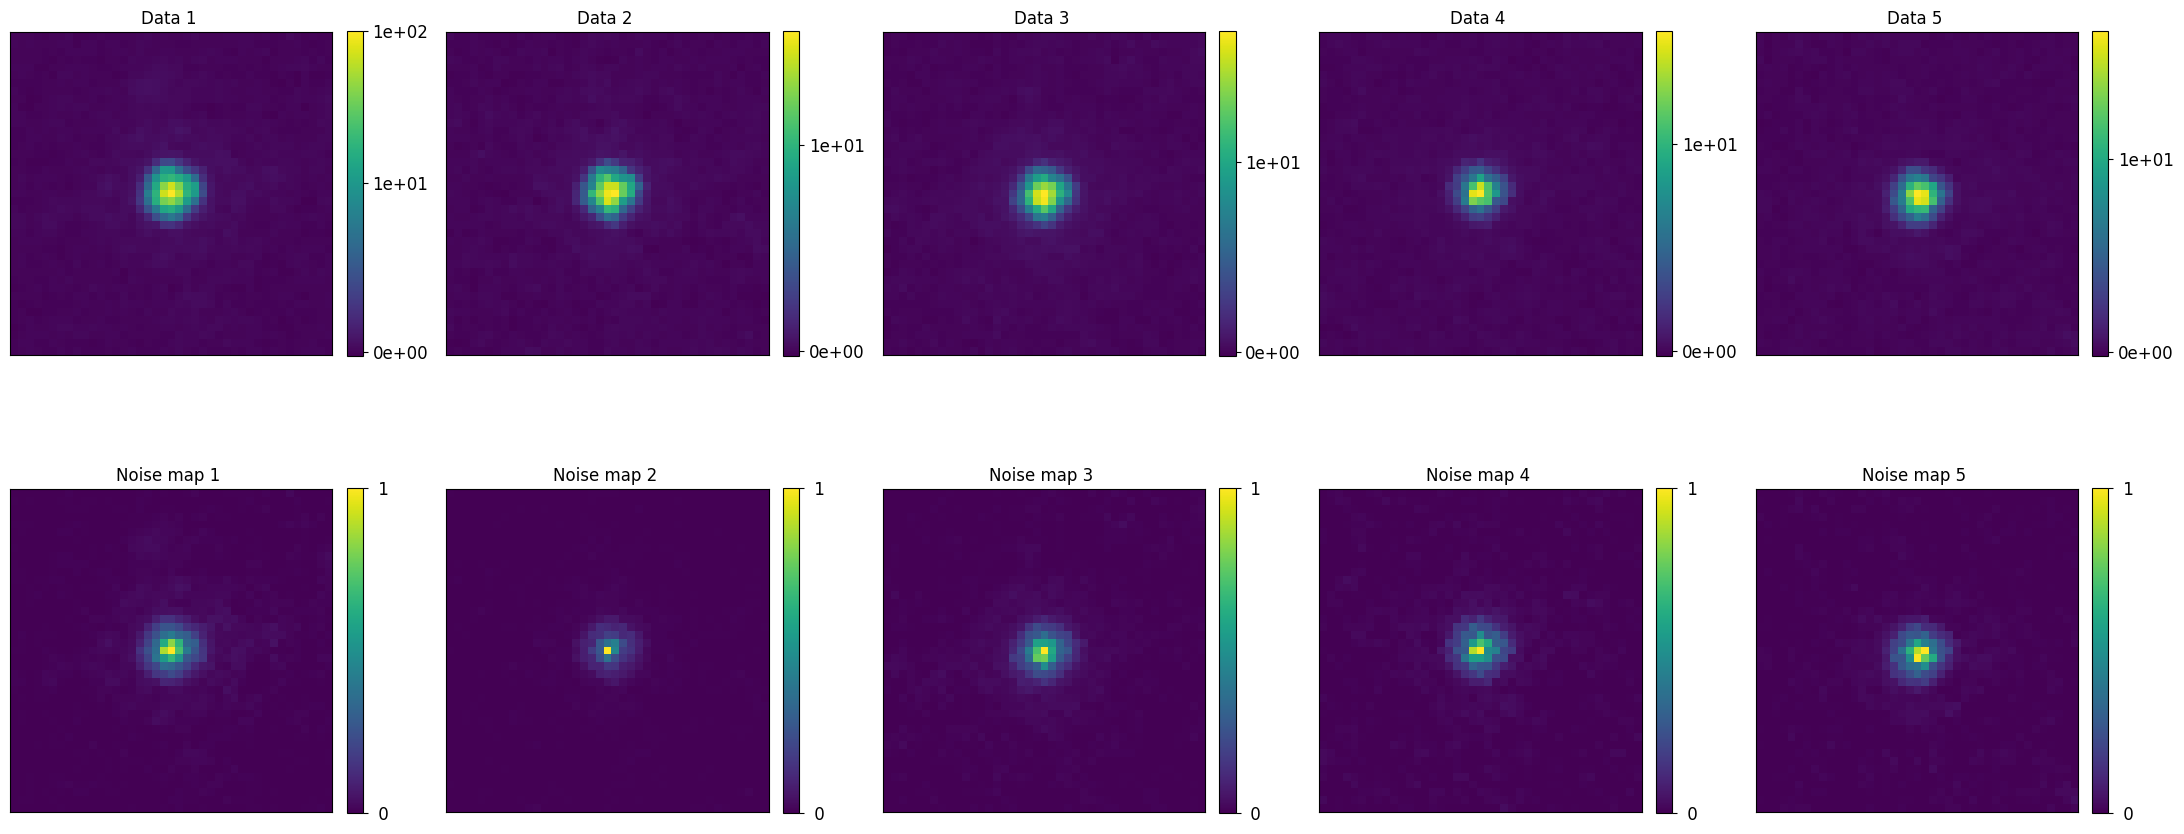

In [6]:
fig = pltf.display_data(data_norm_F160, sigma_2 = sigma_2_norm_F160)

#### Method 1.

Initial Guess : {'kwargs_moffat': {'fwhm': 3.97711804, 'beta': 2.0, 'C': 23.546178040705037}, 'kwargs_gaussian': {'a': Array([36.01322537, 21.62883815, 26.36310022, 13.85148222, 19.87424425],      dtype=float64), 'x0': array([0., 0., 0., 0., 0.]), 'y0': array([0., 0., 0., 0., 0.])}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
Moffat fit : {'kwargs_moffat': {'fwhm': Array([3.62370446], dtype=float64), 'beta': Array([17.23732648], dtype=float64), 'C': Array([23.54617804], dtype=float64)}, 'kwargs_gaussian': {'a': Array([53.68719273, 32.14790443, 38.24656954, 19.49327017, 29.95356402],      dtype=float64), 'x0': Array([-0.01685779,  0.44441863, -0.05198274, -0.00370277,  0.21866658],      dtype=float64), 'y0': Array([ 0.13984951,  0.20736624, -0.13595197,  0.21297939, -0.39803648],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}


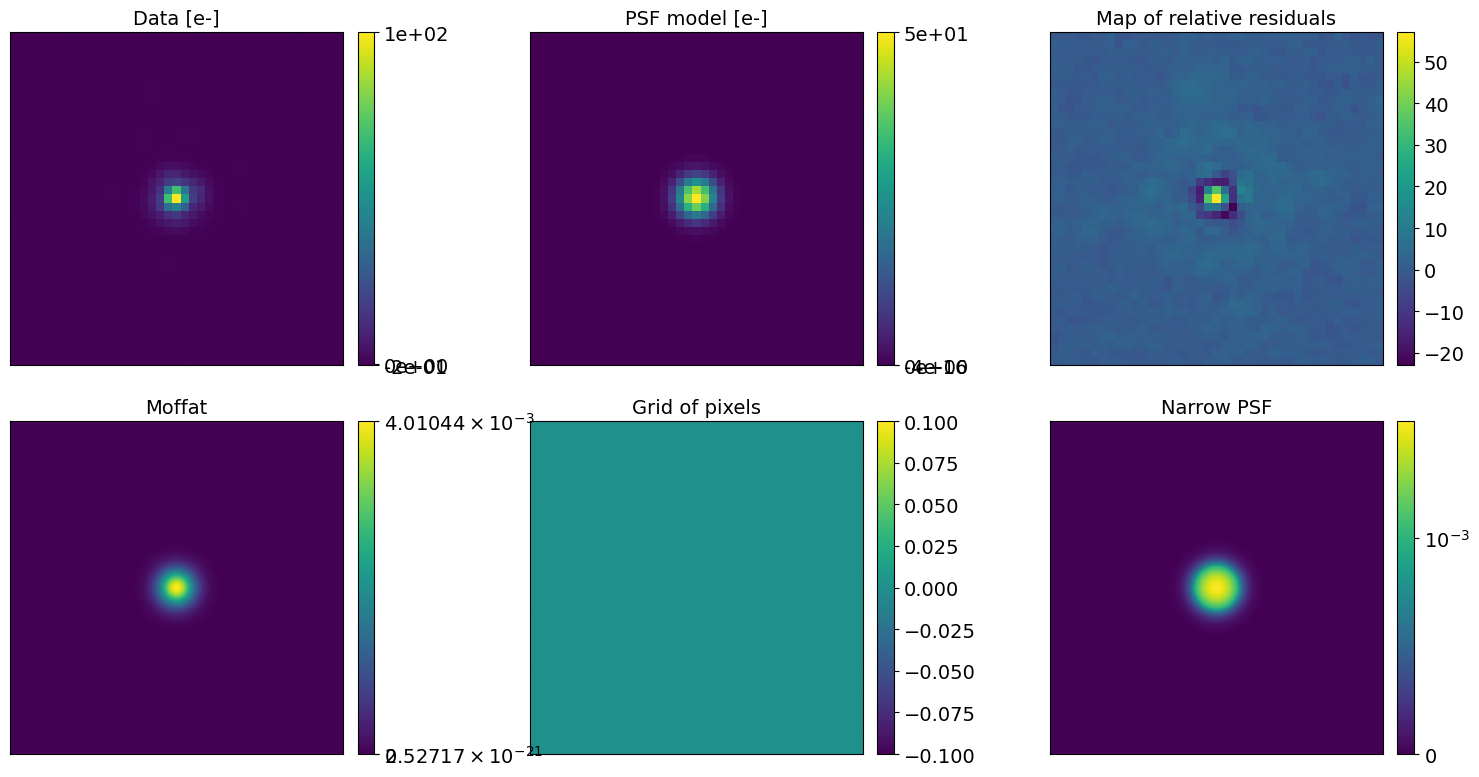

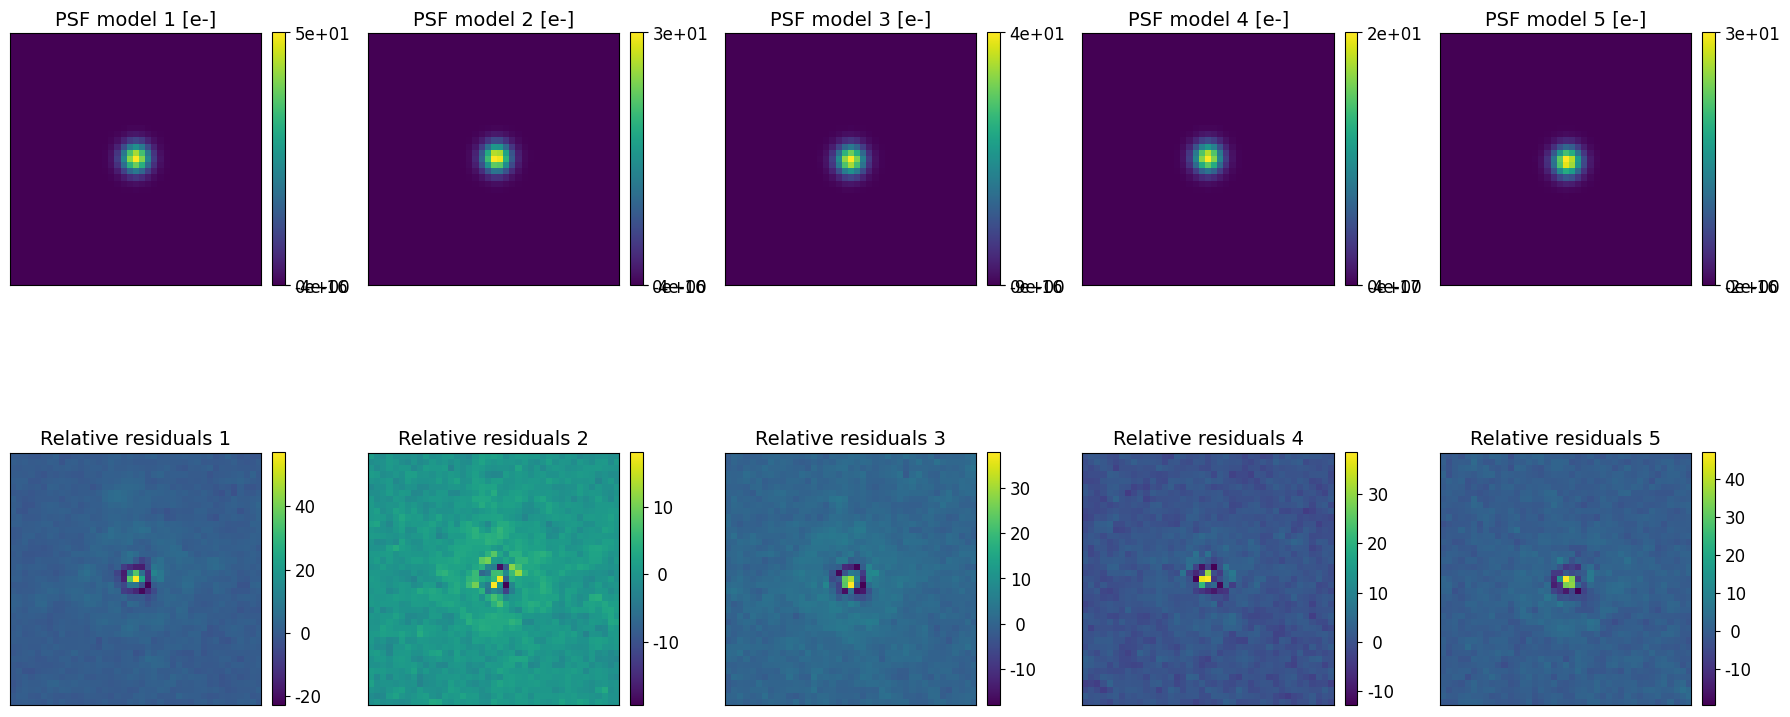

In [7]:
# Build the PSF model class
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F160, fixed_background=True,guess_fwhm_pixels=3.97711804)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F160, model, parameters, sigma_2_norm_F160, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':1000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial,masks=None, units='e-')

Mean noise level in each starlet scale: 
Scale 0 : 4.751775013128608
Scale 1 : 3.7237962514258074
Scale 2 : 2.144239322275593
Scale 3 : 1.101197157561161
Scale 4 : 0.5446056099323365
Scale 5 : 0.26055028223743604
Scale 6 : 0.11804601875165663
Scale 7 : 0.059538157509896404


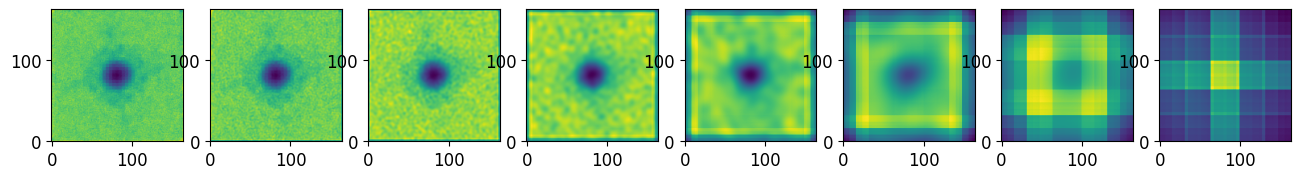

In [8]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F160), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [9]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F160, model, parameters, sigma_2_norm_F160, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 3000, 'min_iterations': None,
                'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

optax.adabelief: 100%|██████████| 3000/3000 [00:23<00:00, 126.41it/s]


{'kwargs_moffat': {'fwhm': Array([2.18755789], dtype=float64), 'beta': Array([14.63700221], dtype=float64), 'C': Array([23.54617804], dtype=float64)}, 'kwargs_gaussian': {'a': Array([170.91954261, 105.25910999, 120.45429208,  66.13256645,
        98.4770179 ], dtype=float64), 'x0': Array([ 0.00214441,  0.3708471 , -0.06584276, -0.14475938,  0.30202891],      dtype=float64), 'y0': Array([ 0.11885027,  0.09033732, -0.25917562,  0.11558871, -0.44350771],      dtype=float64)}, 'kwargs_background': {'background': Array([-0.00716331, -0.00633906, -0.00552922, ..., -0.00373627,
        0.00029704,  0.00029246], dtype=float64)}}


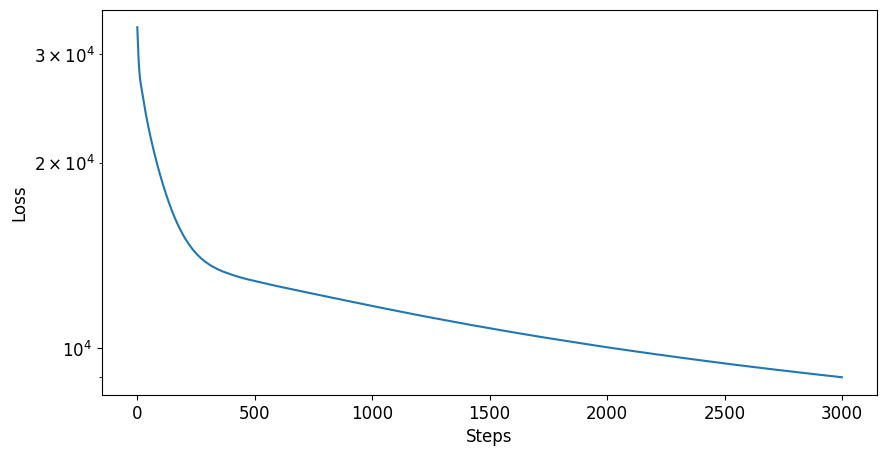

In [10]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

Overall Reduced Chi2 : 1.3260820274527387


/tmp/ipykernel_21647/353186559.py:6: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


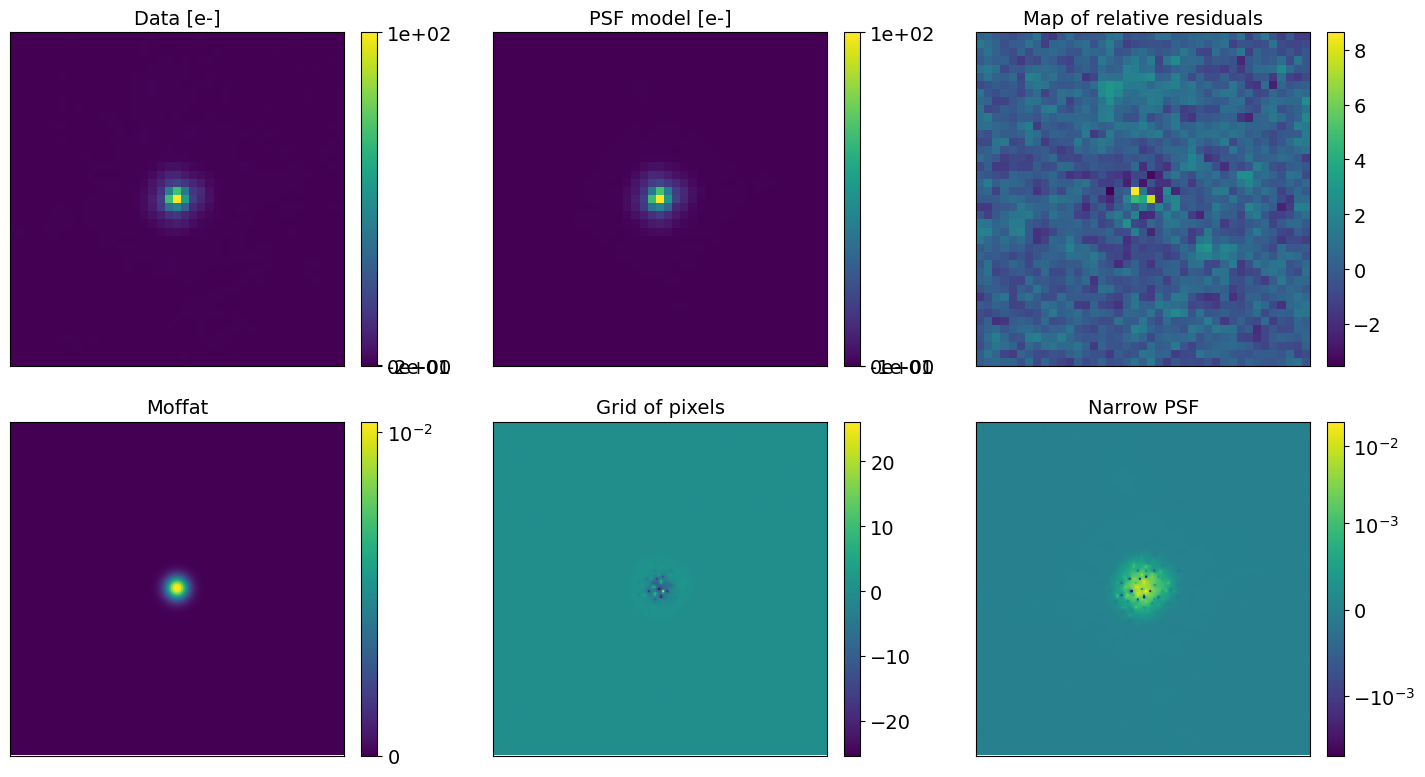

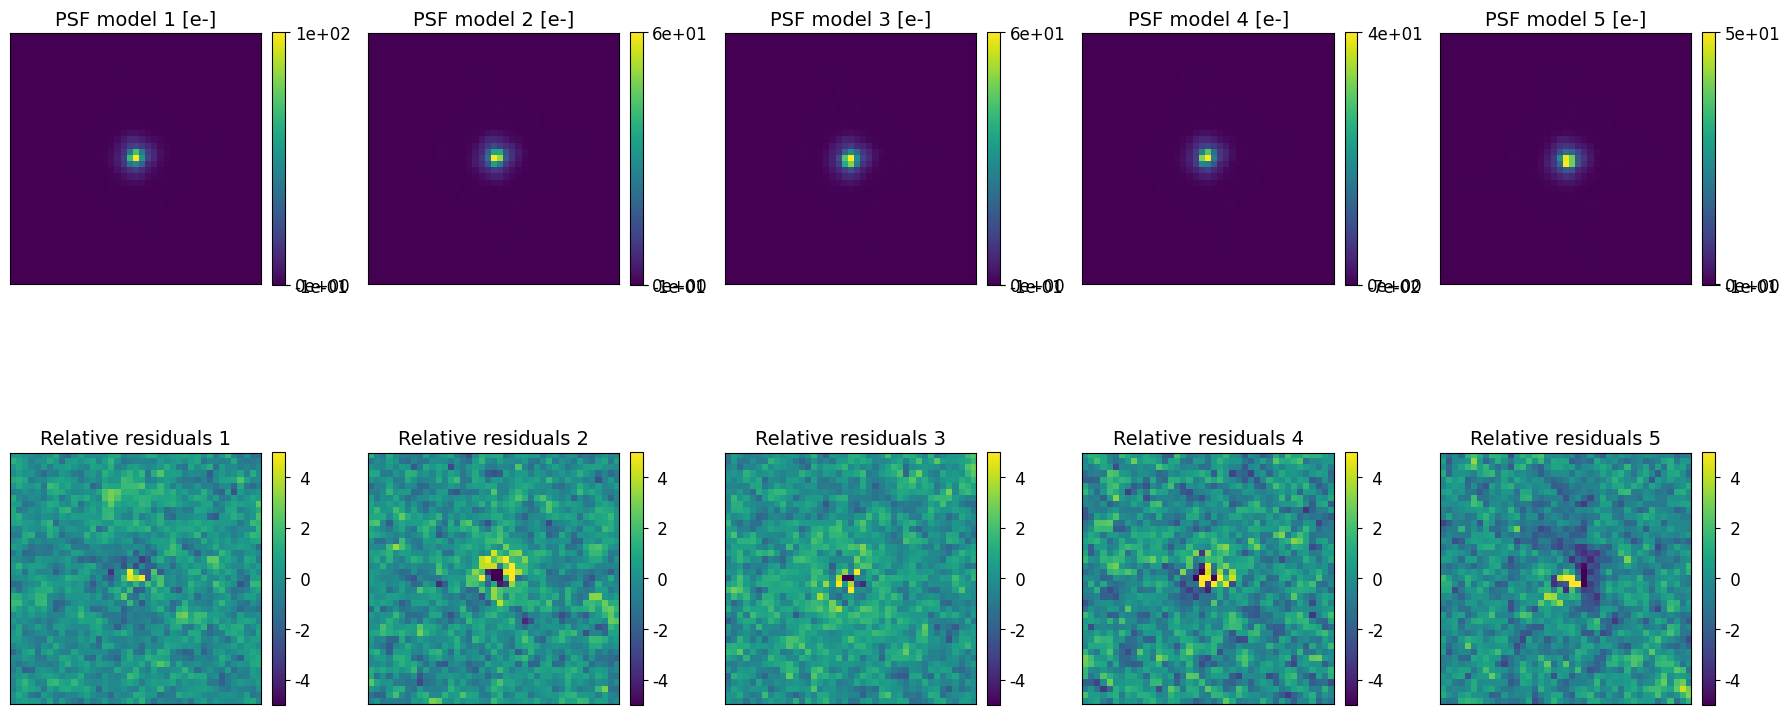

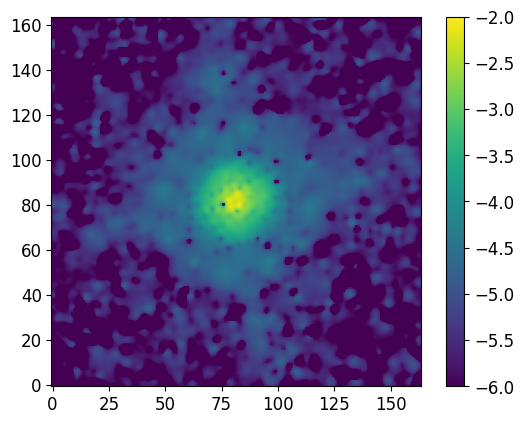

In [11]:
fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
full_psf = model.get_full_psf(**kwargs_final)
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

/tmp/ipykernel_21647/118187892.py:10: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)


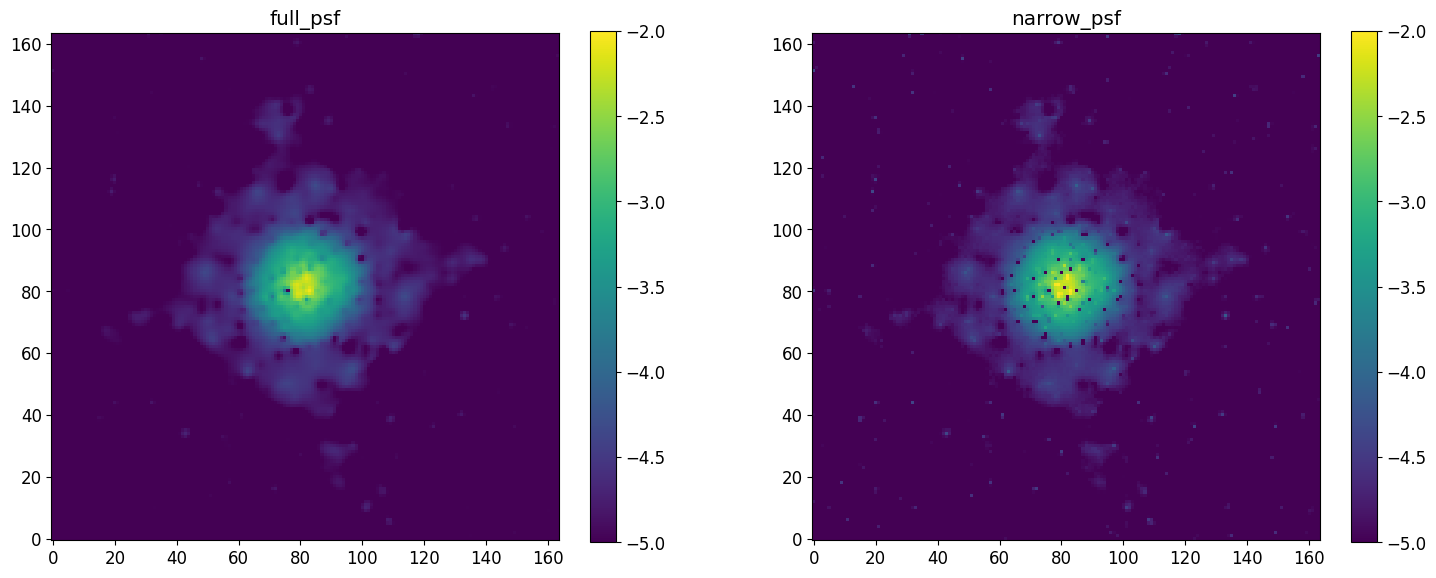

In [12]:
full_psf = model.get_full_psf(**kwargs_final)
s = model.get_narrow_psf(**kwargs_final, norm=True)
PSF_F160W = {"full_psf":full_psf,"narrow_psf":s,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2}
#in my version this dosent work
#print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F160W.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

#### Method 2.

### Step 1, fixing : ['background'] ###


/home/f_avila/miniconda3/envs/starred-env/lib/python3.12/site-packages/starred/optim/optimization.py:78: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


Success of the step 1 fit in 26 iterations (3.5080626010894775 s)
Step 1/2 took  4 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([2.11778383], dtype=float64), 'beta': Array([1.8952398], dtype=float64), 'C': Array([41.05715184], dtype=float64)}, 'kwargs_gaussian': {'a': Array([111.21036586,  66.99063009,  78.84218939,  41.92755177,
        63.21642478], dtype=float64), 'x0': Array([-0.04637608,  0.36027784, -0.12660494, -0.13515688,  0.28464023],      dtype=float64), 'y0': Array([ 0.16772815,  0.17294933, -0.22172165,  0.18168237, -0.37241157],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
LogL :  13614.130749737204
Overall Reduced Chi2 :  3.239531409812541
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 1000/1000 [00:11<00:00, 86.77it/s]


Step 2/2 took 12 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([2.11778383], dtype=float64), 'beta': Array([1.8952398], dtype=float64), 'C': Array([41.05715184], dtype=float64)}, 'kwargs_gaussian': {'a': Array([115.28427907,  70.59282508,  80.78270552,  44.02572354,
        65.7601119 ], dtype=float64), 'x0': Array([-0.03070884,  0.37292277, -0.09805651, -0.15818524,  0.29866966],      dtype=float64), 'y0': Array([ 0.17483528,  0.15708025, -0.21731094,  0.16990859, -0.38713385],      dtype=float64)}, 'kwargs_background': {'background': Array([-0.00215771, -0.00397147, -0.00321879, ..., -0.00307553,
        0.00013898,  0.00027251], dtype=float64)}}
LogL :  8427.784121793937
Overall Reduced Chi2 :  1.5712866680630213
Moffat fit :


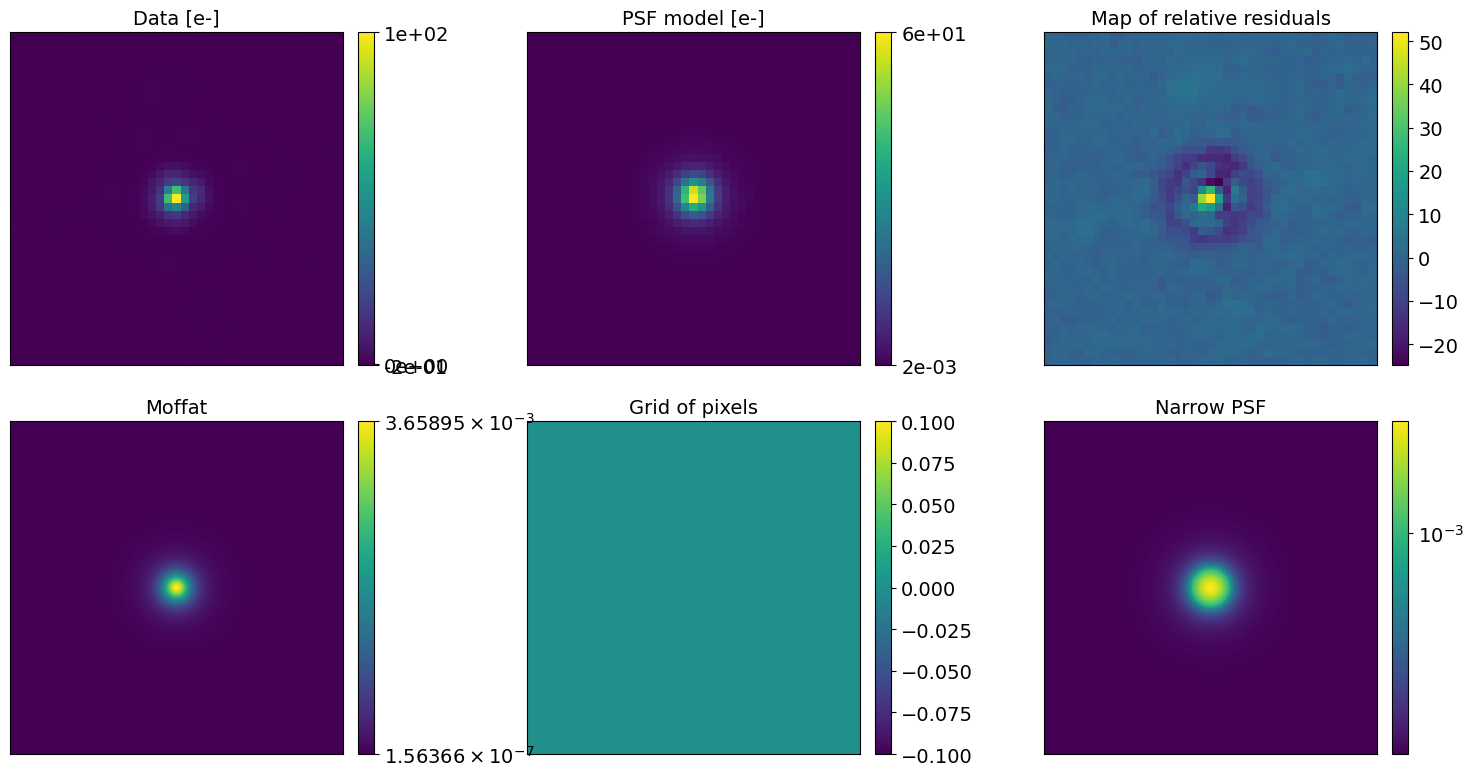

Moffat+ Background fit :


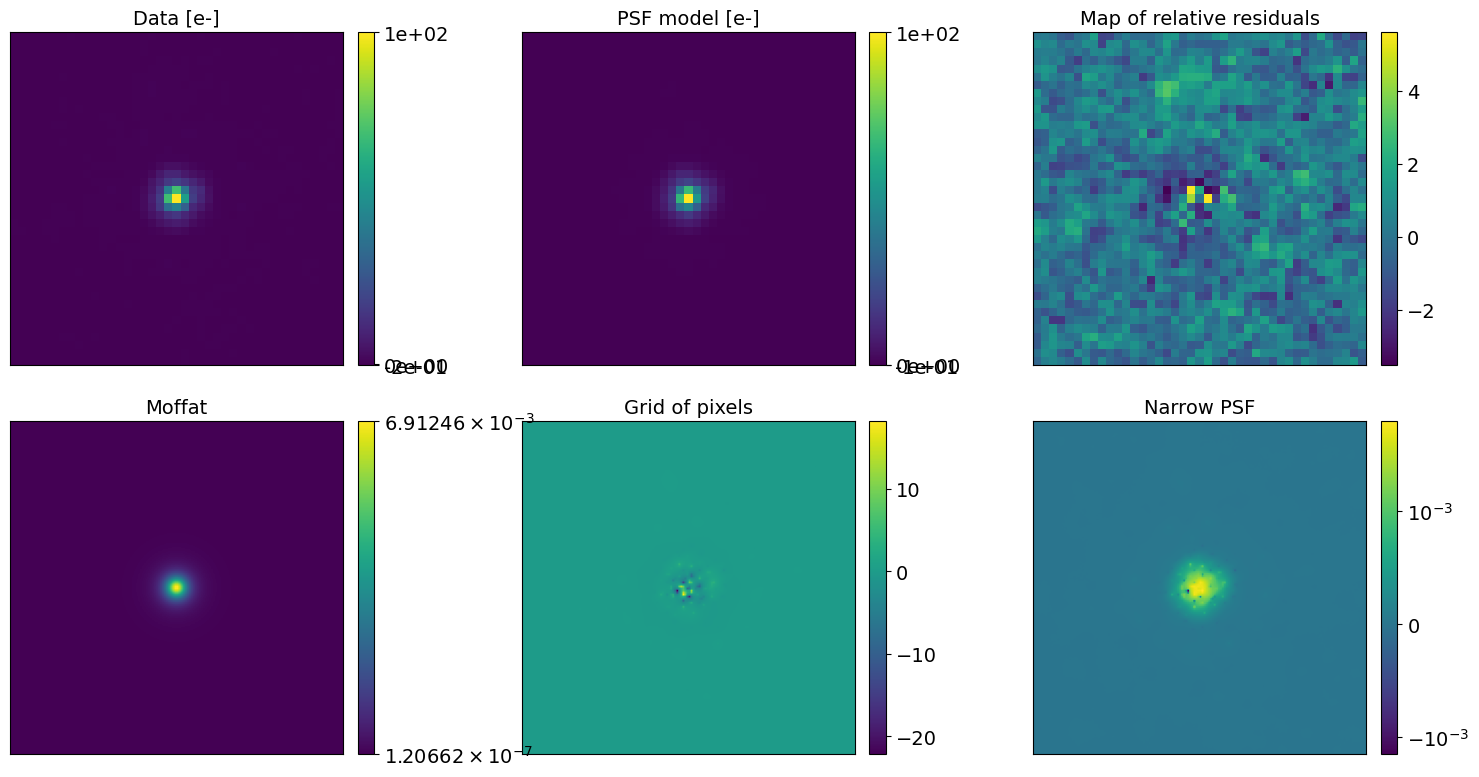

Multiple stars PSF model :


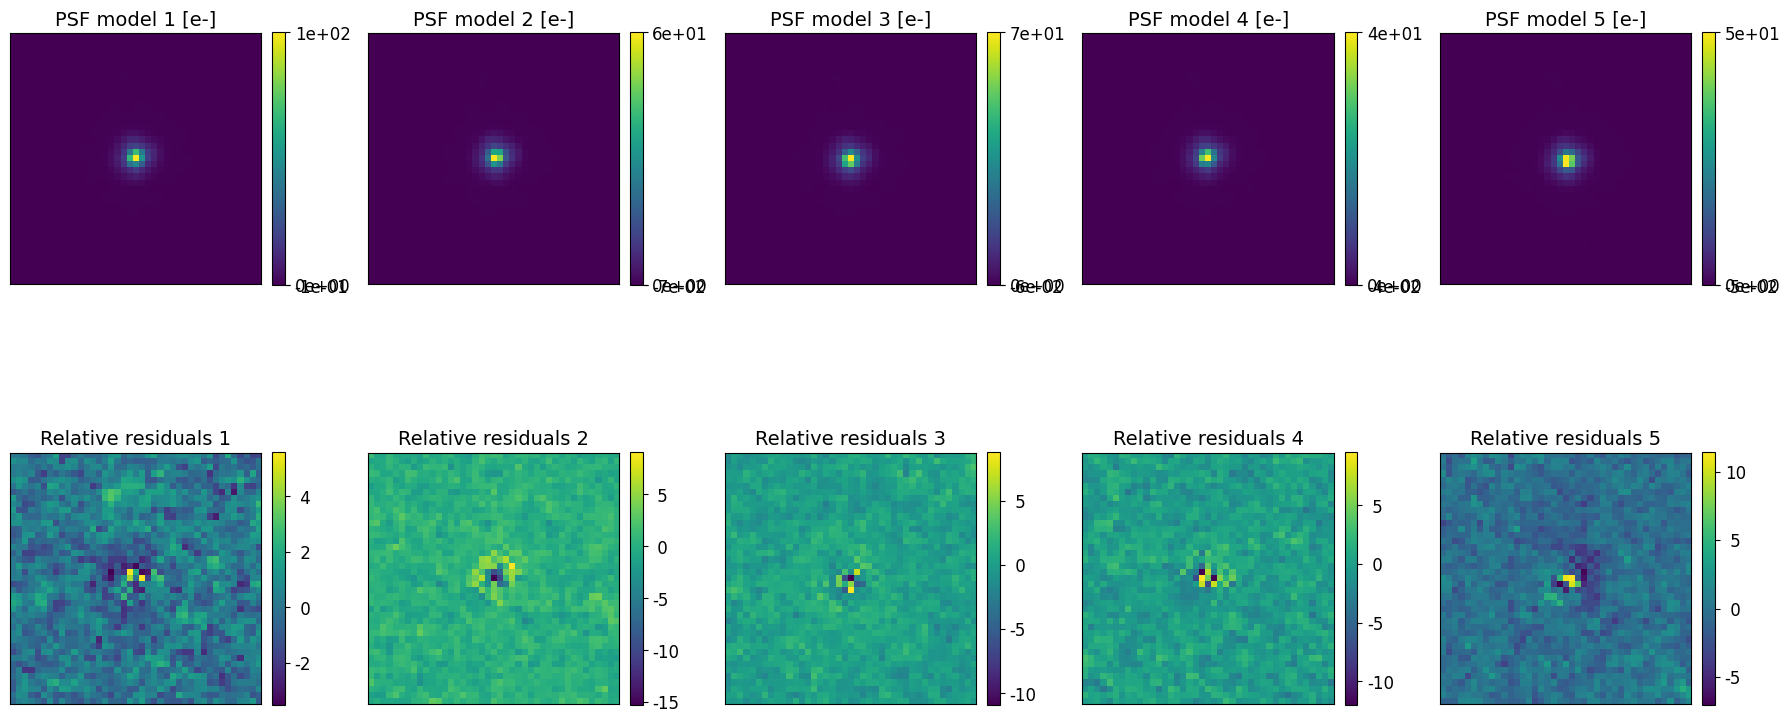

Loss history :


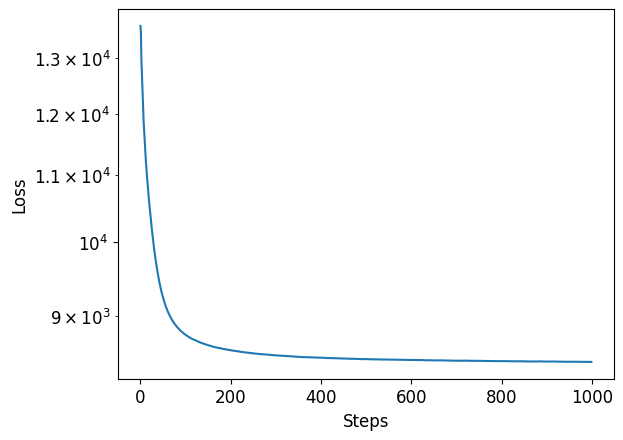

/tmp/ipykernel_21647/737751556.py:56: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


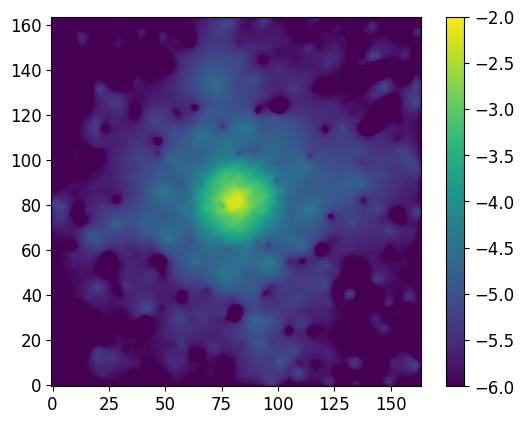

In [13]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F160, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 1000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F160, model,
        parameters, sigma_2_norm_F160, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F160, sigma_2_norm_F160, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

/tmp/ipykernel_21647/118187892.py:10: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)


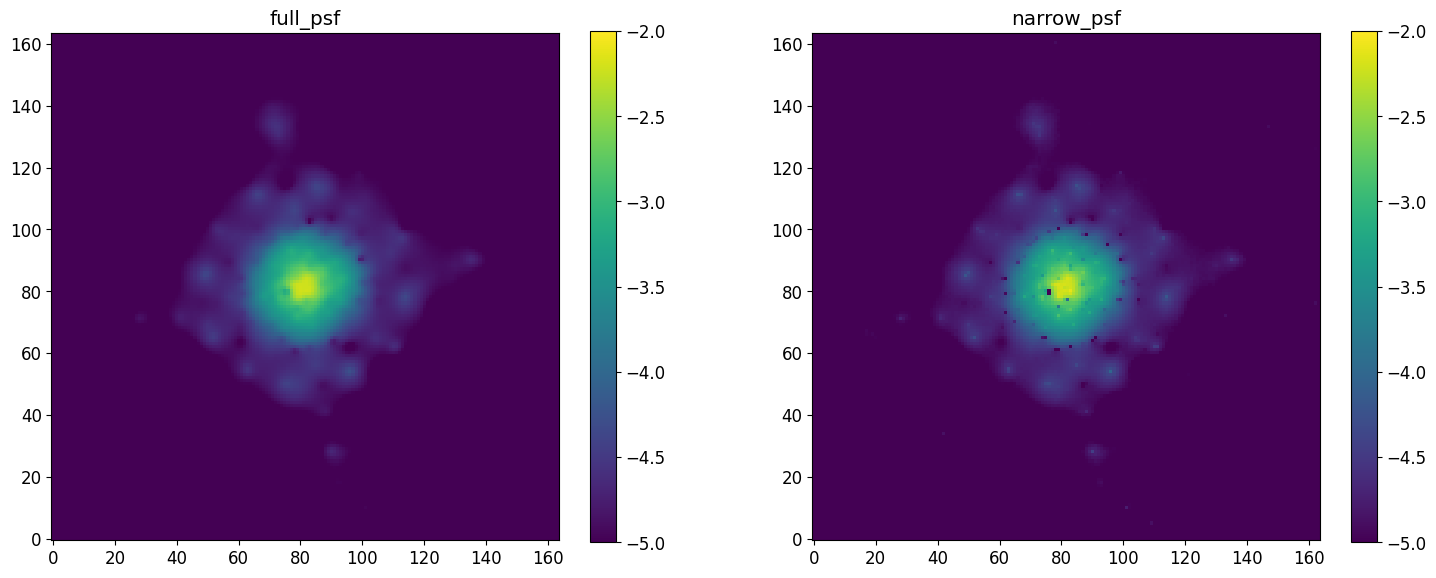

In [14]:
full_psf = model.get_full_psf(**kwargs_final)
s = model.get_narrow_psf(**kwargs_final, norm=True)
PSF_F160W = {"full_psf":full_psf,"narrow_psf":s,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2}
#in my version this dosent work
#print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F160W.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different componenet of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [15]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F160W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
#save_dict_as_h5py(result_psf_F160W,os.path.join(os.path.dirname(path_file),"result_psf_F160W"))

Overall Reduced Chi2 :  1.5712866680630213


In [16]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F160W 
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F160W / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F160W"].values())[:3]) for i in np.asarray(photometry)]


Astrometry : [[-0.03070884  0.17483528]
 [ 0.37292277  0.15708025]
 [-0.09805651 -0.21731094]
 [-0.15818524  0.16990859]
 [ 0.29866966 -0.38713385]]
Photometry : [106.35440705  65.10762476  74.52336235  40.6160219   60.64683738]
Photometry high resolution : [106.35440705  65.10762476  74.52336235  40.6160219   60.64683738]


[20.870783934462224,
 21.403593031448665,
 21.256941558025005,
 21.915929199540926,
 21.48065226563942]

In [17]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_file), 'model_starred_save_F160.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F160W, data=data_norm_F160, sigma_2=sigma_2_norm_F160, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [18]:

# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()

#### Moffats

In [164]:
"functions taked from starred credits for authors"
def fwhm2sigma(fwhm):
    """
    Converts the FWHM (Full Width at Half Maximum) to the Gaussian sigma.

    :param fwhm: the full width at half maximum value
    :type fwhm: float
    :return: Gaussian standard deviation, `i.e.`, sqrt(var)

    """
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return sigma
def moffat_function(x, y, amp, fwhm, beta, center_x, center_y):
    """
    :param x: 1D array of x positions
    :param y: 1D array of y positions
    :param amp: the amplitude coefficient
    :type amp: float
    :param fwhm: the full width at half maximum value
    :type fwhm: float
    :param beta: the Moffat beta parameter
    :type beta: float
    :param center_x: x position of the center
    :type center_x: float
    :param center_y: y position of the center
    :type center_y: float

    :return: 2D Moffat
    
    """
    r0 = fwhm / (2. * np.sqrt(2. ** (1. / beta) - 1.))
    delta_x = np.subtract(x, center_x)
    delta_y = np.subtract(y, center_y)
    rr_gg = (delta_x / r0) ** 2 + (delta_y / r0) ** 2
    return amp * (1 + rr_gg) ** (-beta)

def moffat_elliptical_function(x, y, amp, fwhm_x, fwhm_y, phi, beta, center_x, center_y):
    """
    :param x: 1D array of x positions
    :param y: 1D array of y positions
    :param amp: the amplitude coefficient
    :type amp: float
    :param fwhm_x: the full width at half maximum value in the x direction
    :type fwhm_x: float
    :param fwhm_y: the full width at half maximum value in the y direction
    :type fwhm_y: float
    :param phi: orientation angle
    :type phi: float
    :param beta: the Moffat beta parameter
    :type beta: float
    :param center_x: x position of the center
    :type center_x: float
    :param center_y: y position of the center
    :type center_y: float

    :return: 2D Elliptical Moffat

    """
    r0_x = fwhm_x / (2. * np.sqrt(2. ** (1. / beta) - 1.))
    r0_y = fwhm_y / (2. * np.sqrt(2. ** (1. / beta) - 1.))
    delta_x = np.subtract(x, center_x)
    delta_y = np.subtract(y, center_y)
    A = (np.cos(phi) / r0_x)**2  + (np.sin(phi) / r0_y)**2
    B = (np.sin(phi) / r0_x)**2  + (np.cos(phi) / r0_y)**2
    C = 2*np.sin(phi)*np.cos(phi)*(1./ r0_x**2 - 1/r0_y**2)
    rr_gg = A*(delta_x ** 2) + B * (delta_y ** 2) + C * delta_x * delta_y
    return amp * (1 + rr_gg) ** (-beta)
def gaussian_function(x, y, amp, sigma_x, sigma_y, center_x, center_y):
    """
    :param x: 1D array of x positions
    :param y: 1D array of y positions
    :param amp: the amplitude coefficient
    :type amp: float
    :param sigma_x: x-spread of the Gaussian blob
    :type sigma_x: float
    :param sigma_y: y-spread of the Gaussian blob
    :type sigma_y: float
    :param center_x: x position of the center
    :type center_x: float
    :param center_y: y position of the center
    :type center_y: float

    :return: 2D Gaussian

    """
    c = 1 / np.sqrt((2 * np.pi * sigma_x * sigma_y))
    delta_x = np.subtract(x, center_x)
    delta_y = np.subtract(y, center_y)
    exponent = -((delta_x / sigma_x) ** 2 + (delta_y / sigma_y) ** 2) / 2.
    g = c * np.exp(exponent)
    g /= g.sum()
    return amp * g
def gaussian_function_batched(x, y, amp, sigma_x, sigma_y, center_x, center_y):
    """
    adjusted gaussian_function to accept and process batches for center_x and center_y.
    amp, sigma_x, sigma_y can also be vectors.
    but won't be needed in starred, as we scale the PSF at the moffat step.

    x and y: 2d arrays of coordinates made by make_grid and reshaped.

    """
    c = 1 / np.sqrt((2 * np.pi * sigma_x * sigma_y))
    # adding slice dimension to x and y, adding data dimension to center_x and center_y
    delta_x = x[None, :] - center_x[:, None]
    delta_y = y[None, :] - center_y[:, None]
    exponent = -((delta_x / sigma_x) ** 2 + (delta_y / sigma_y) ** 2) / 2.
    g = c * np.exp(exponent)
    g /= g.sum(axis=(1,))[:, None]  # normalize over x and y dimensions
    return amp[:, None] * g

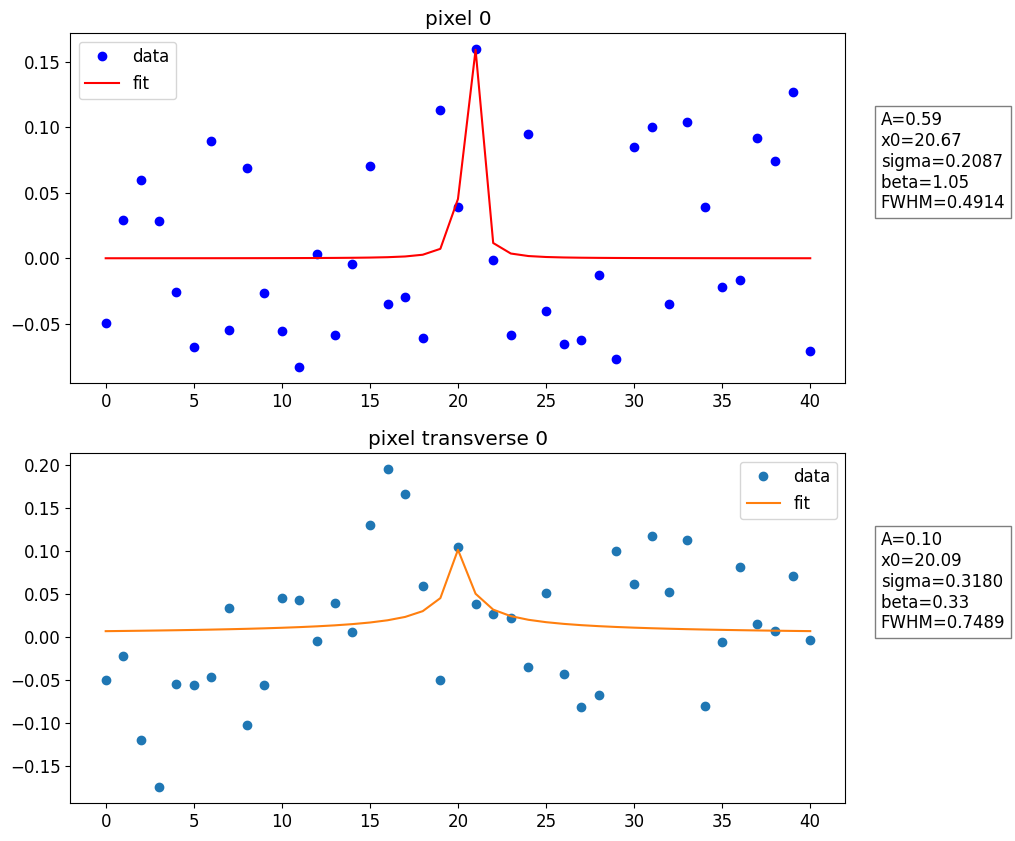

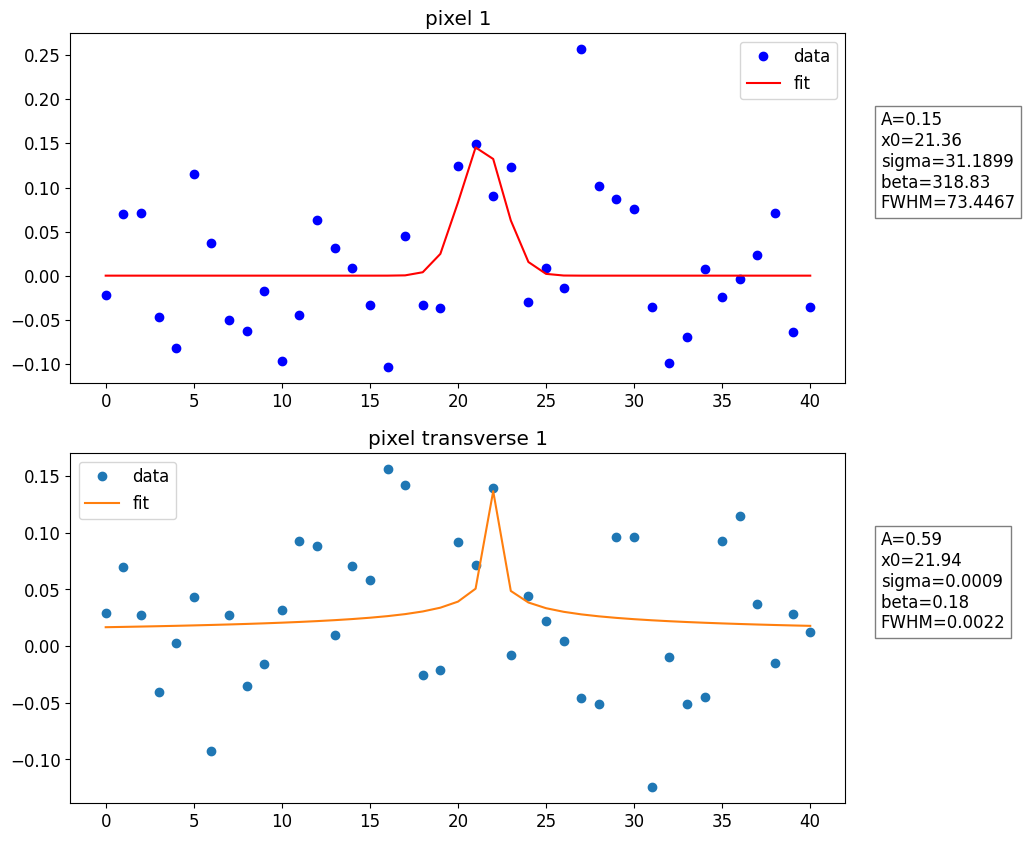

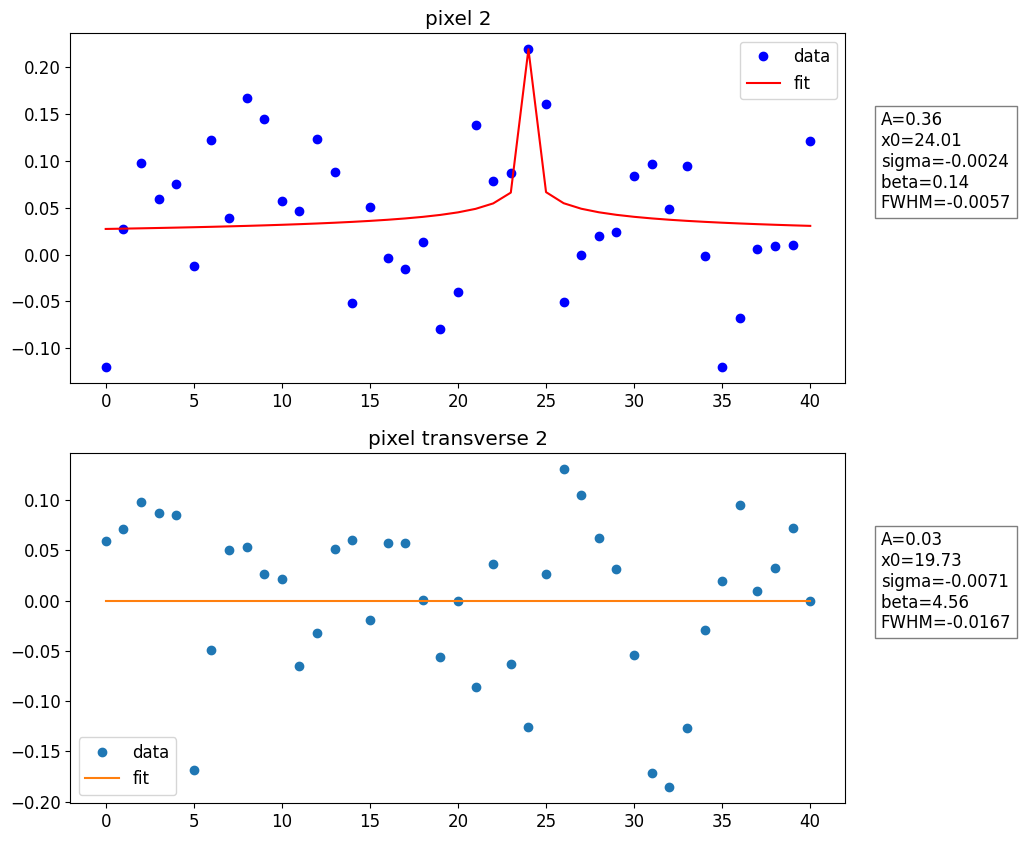

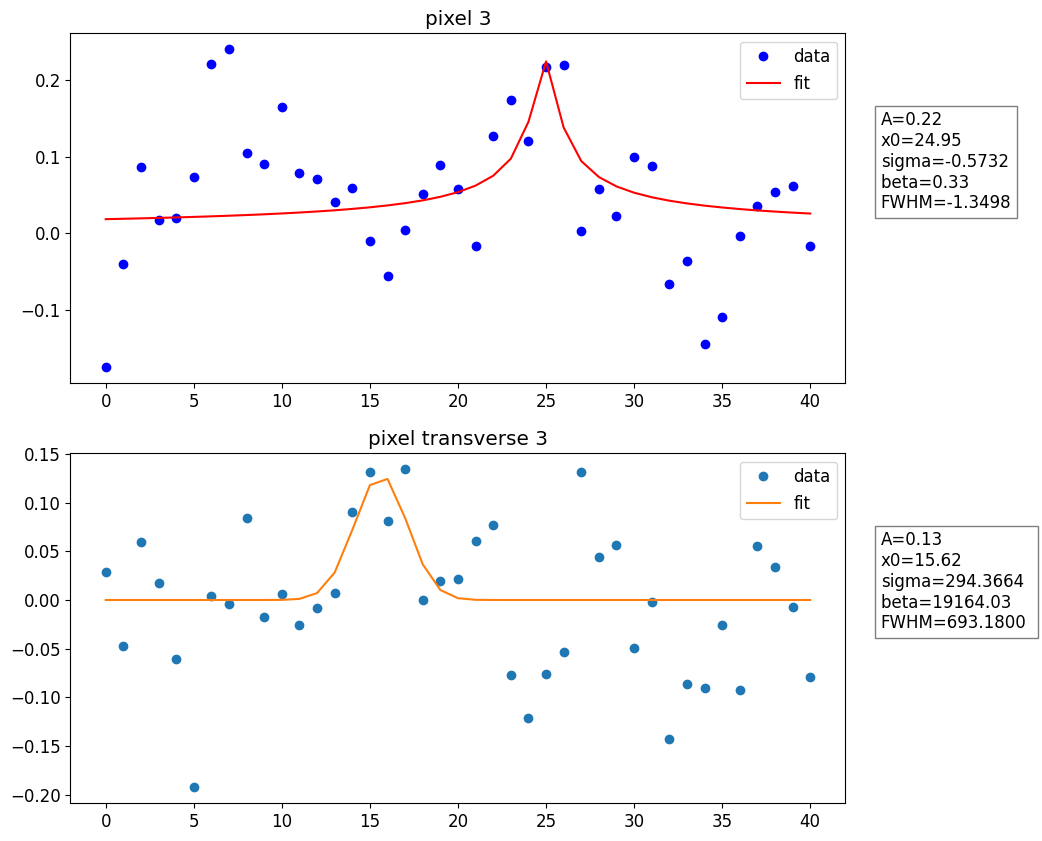

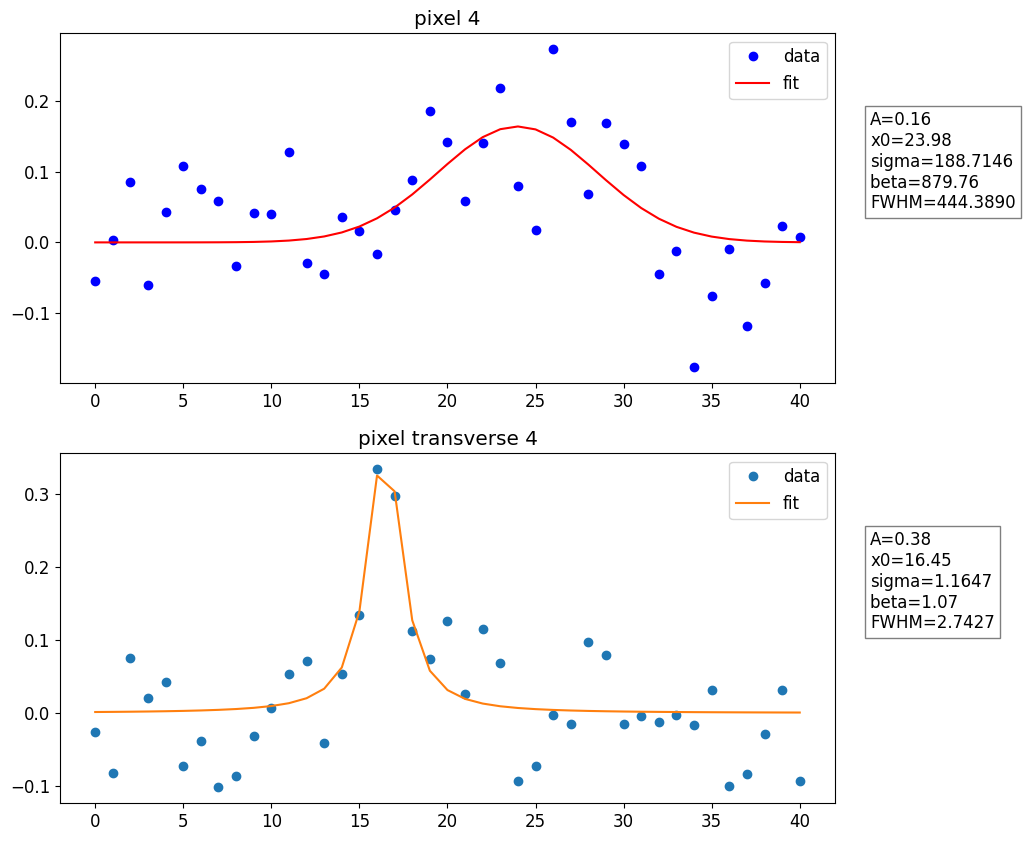

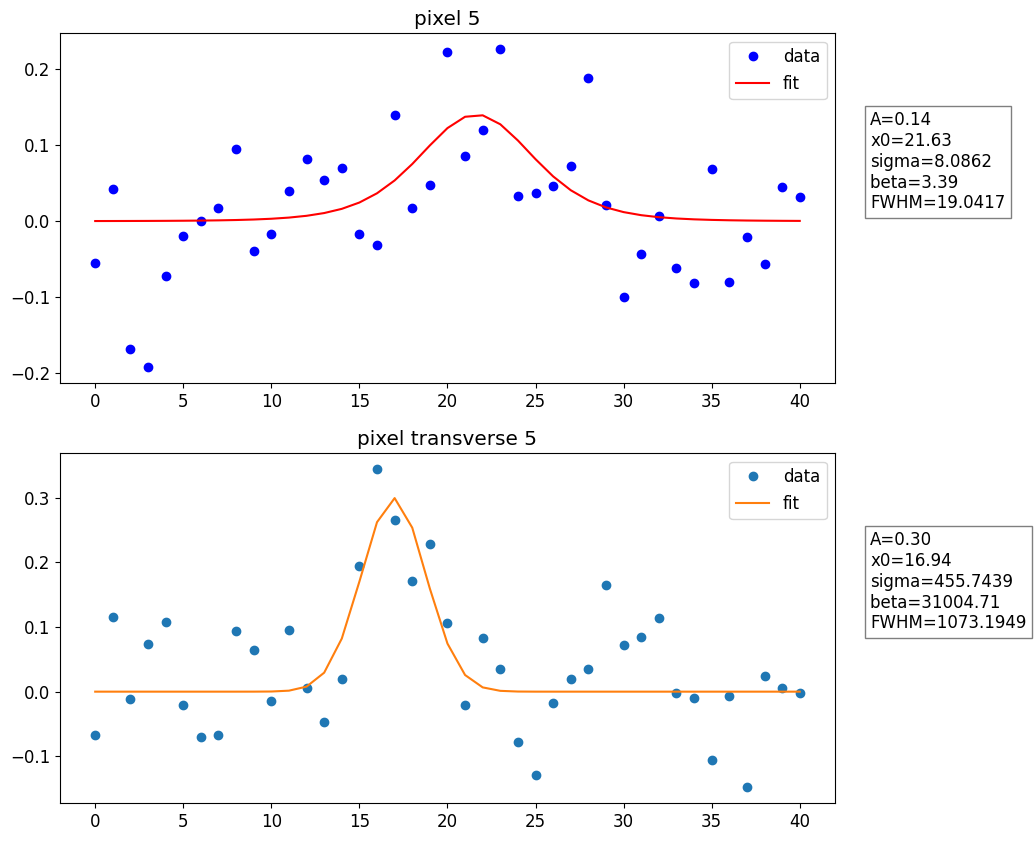

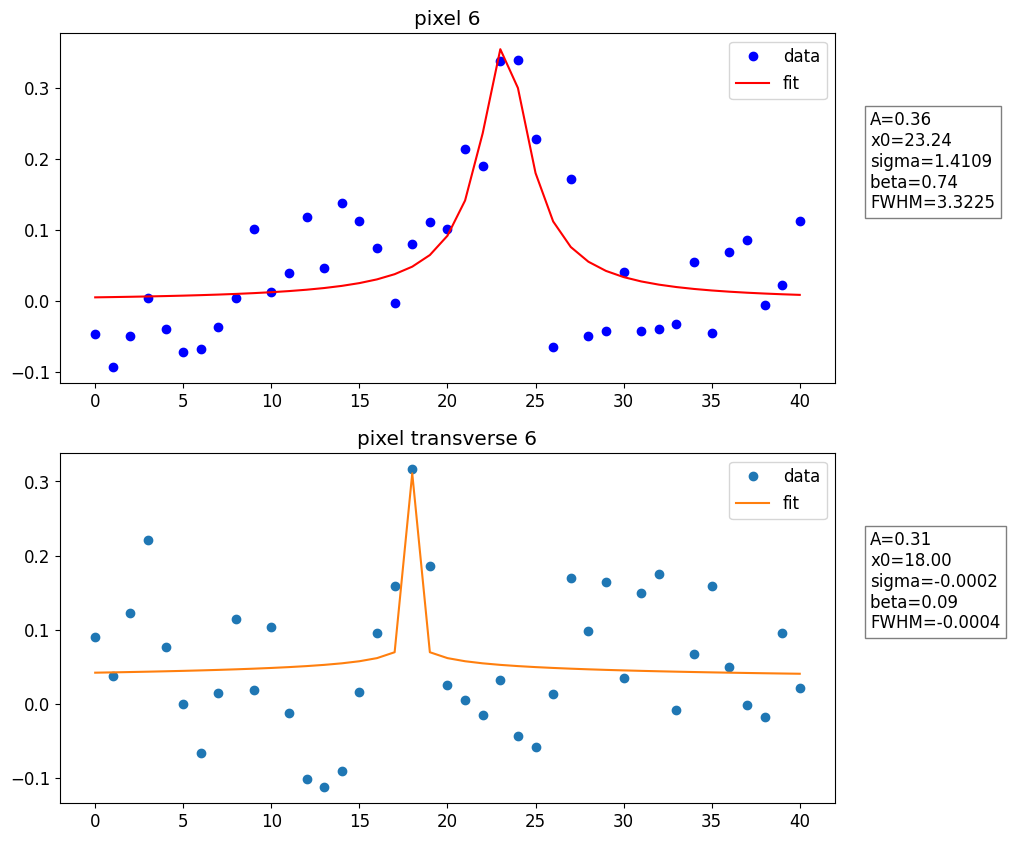

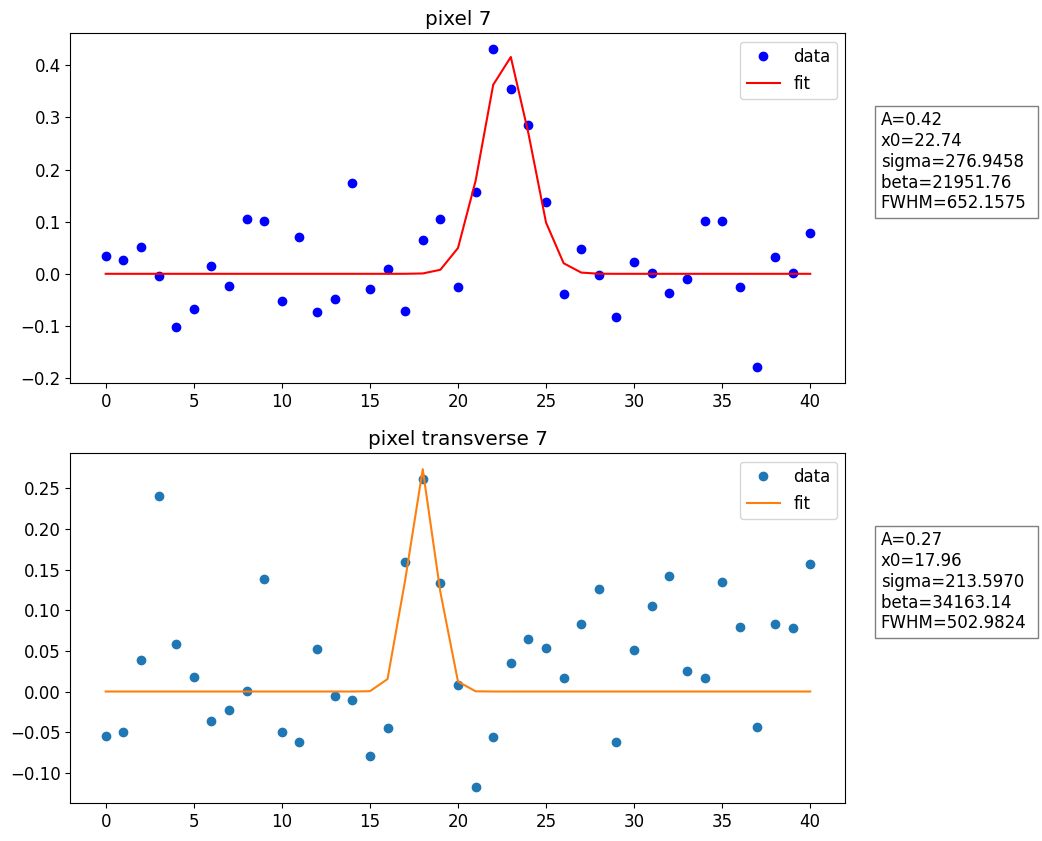

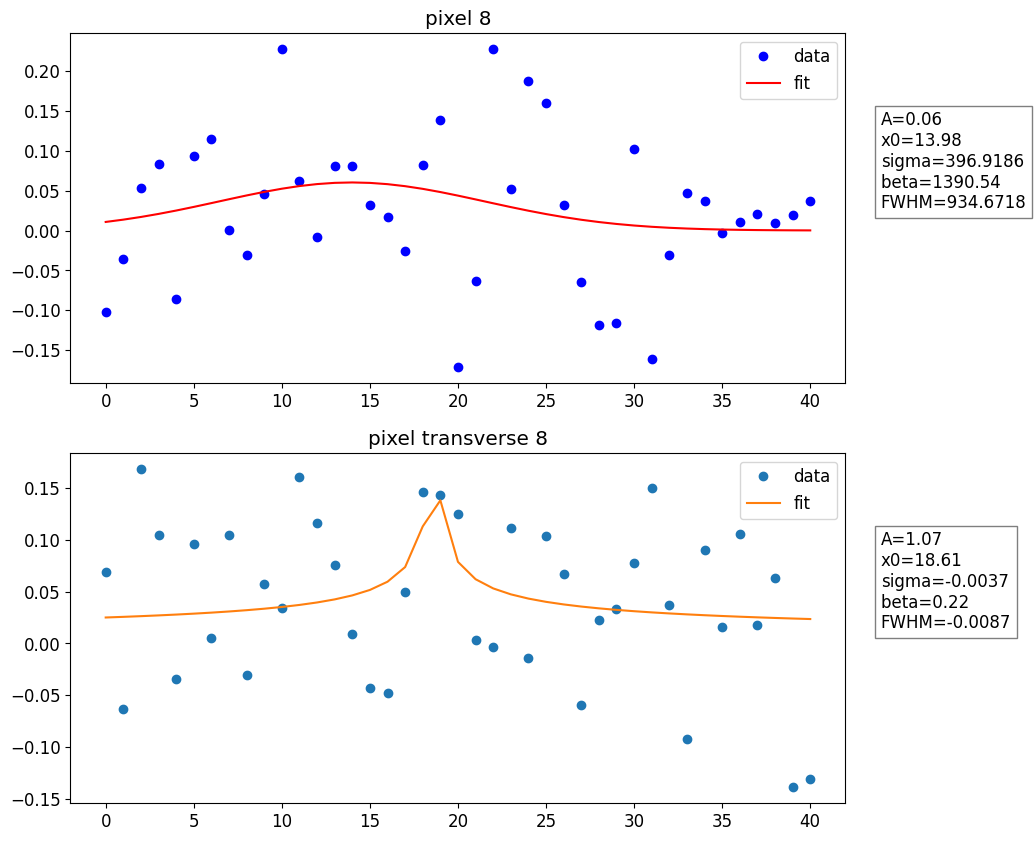

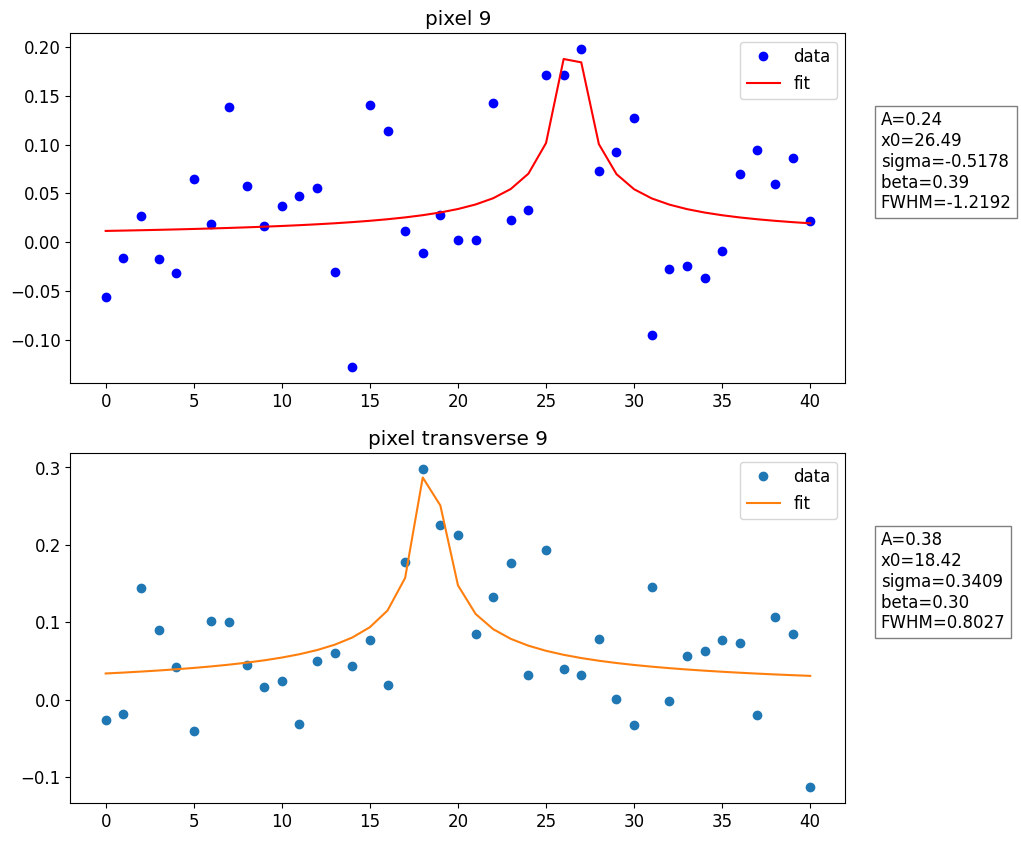

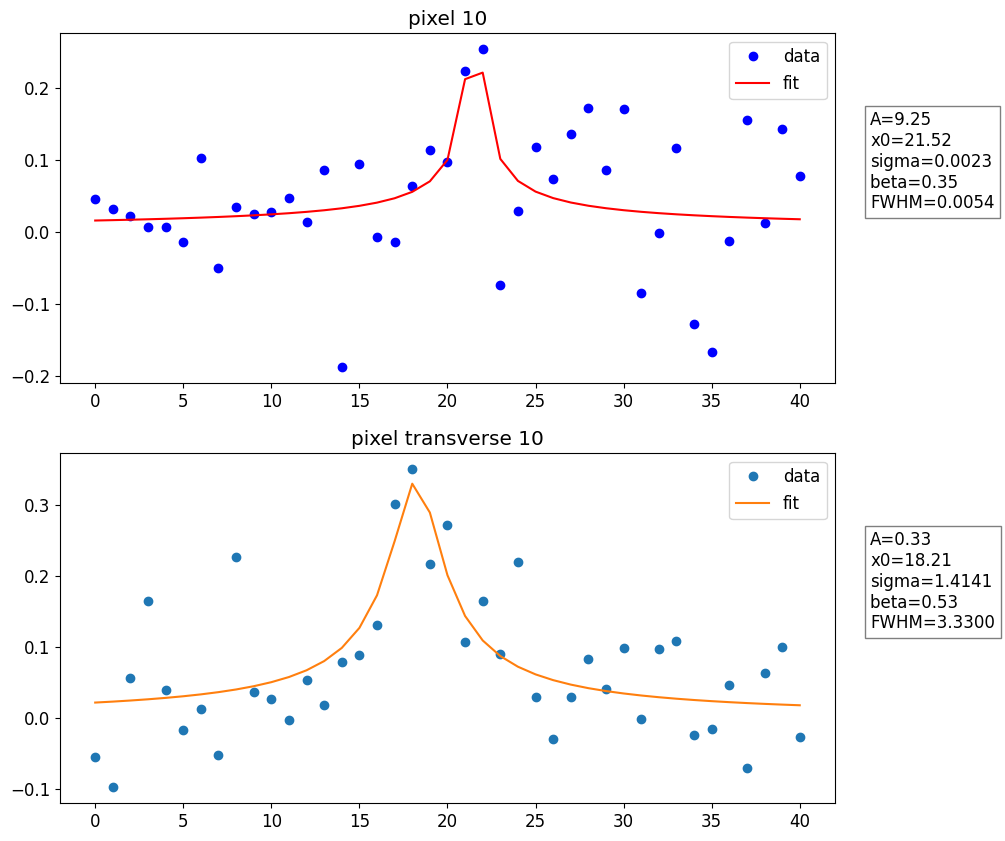

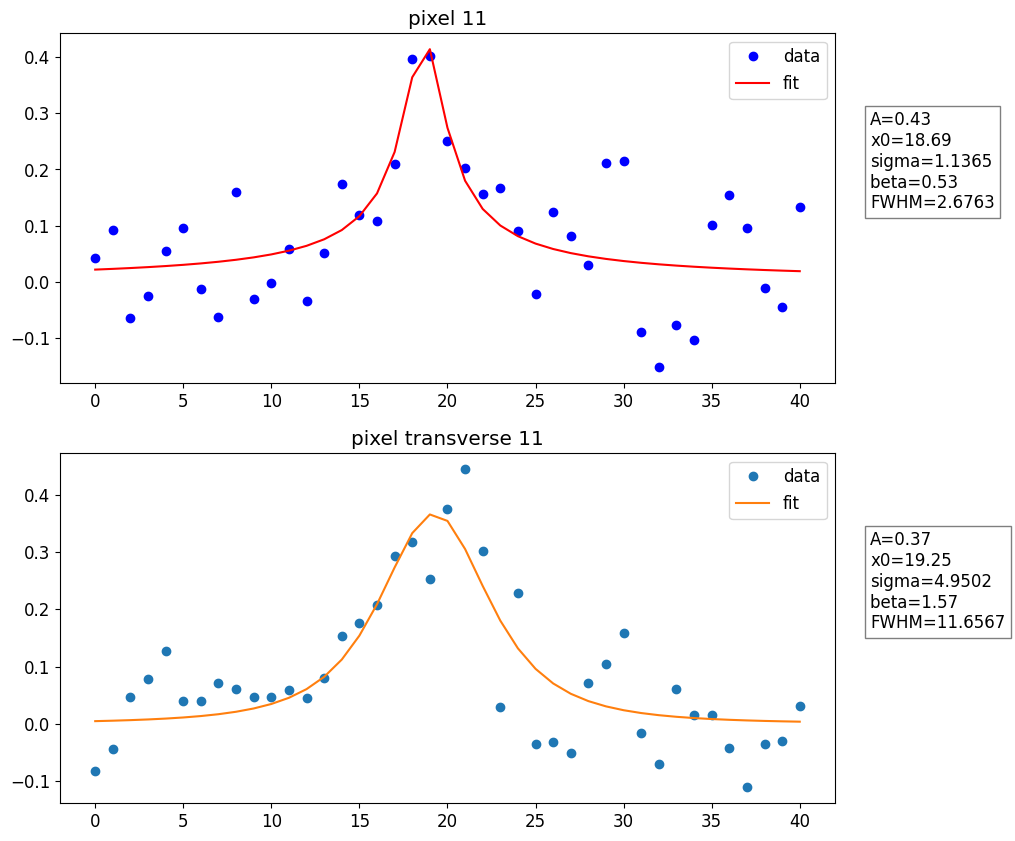

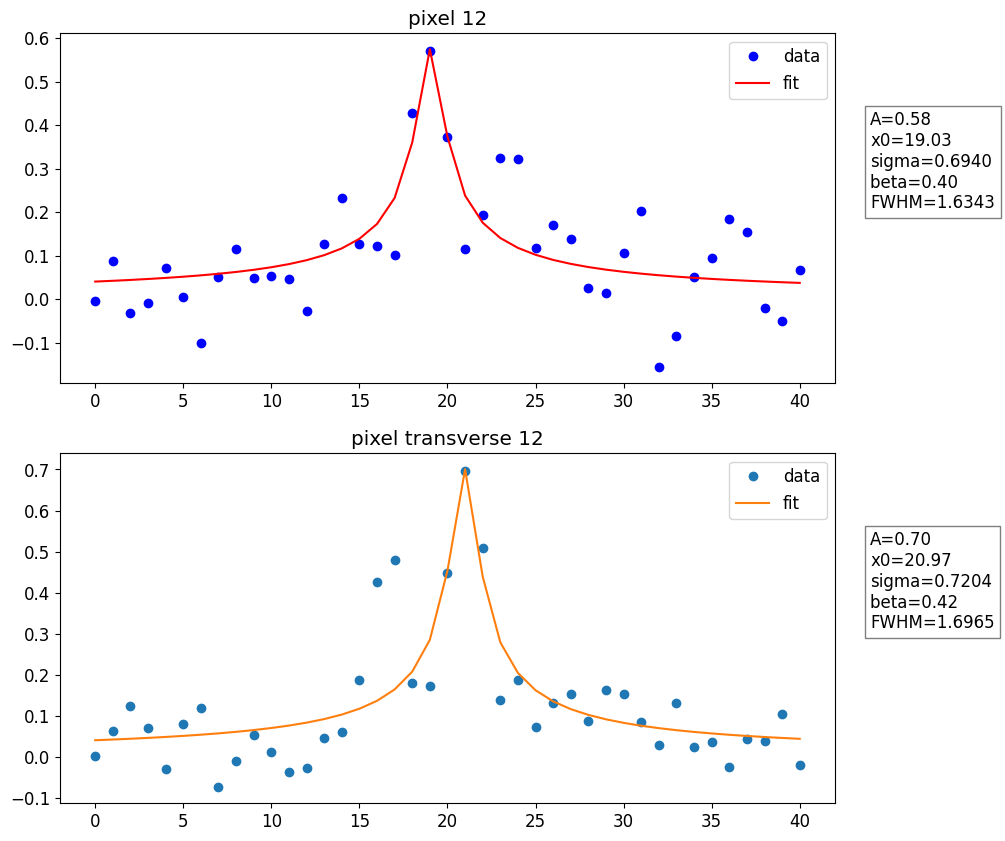

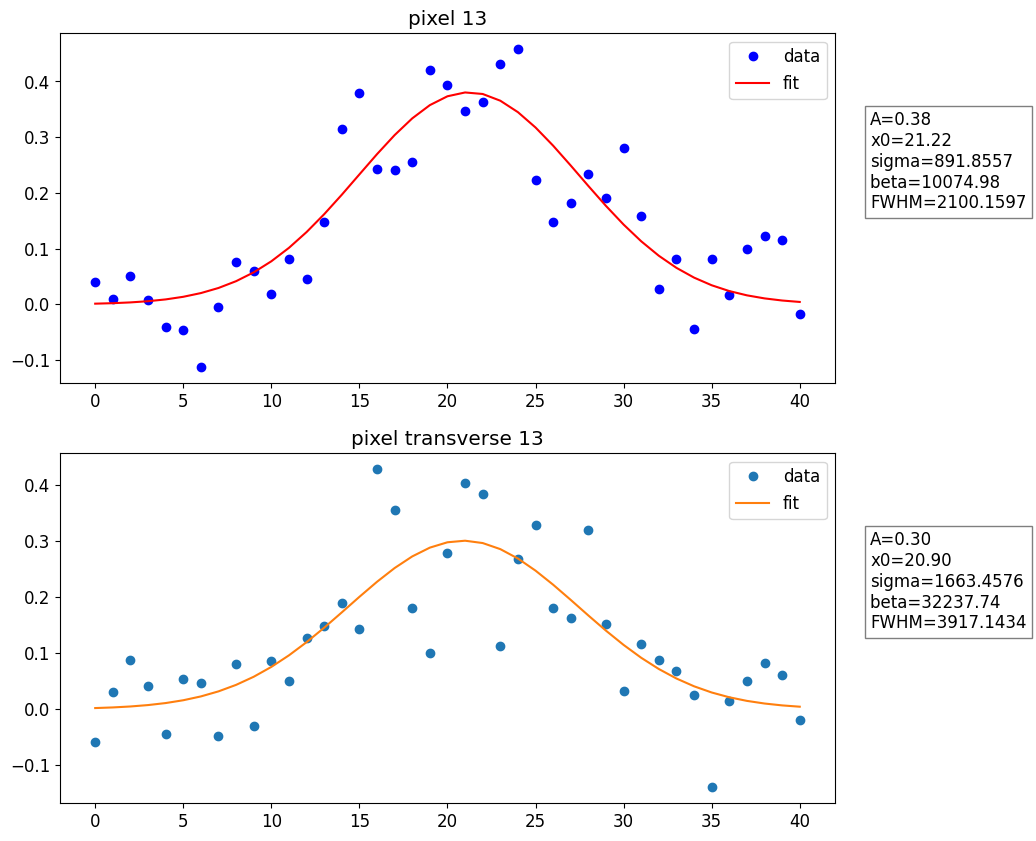

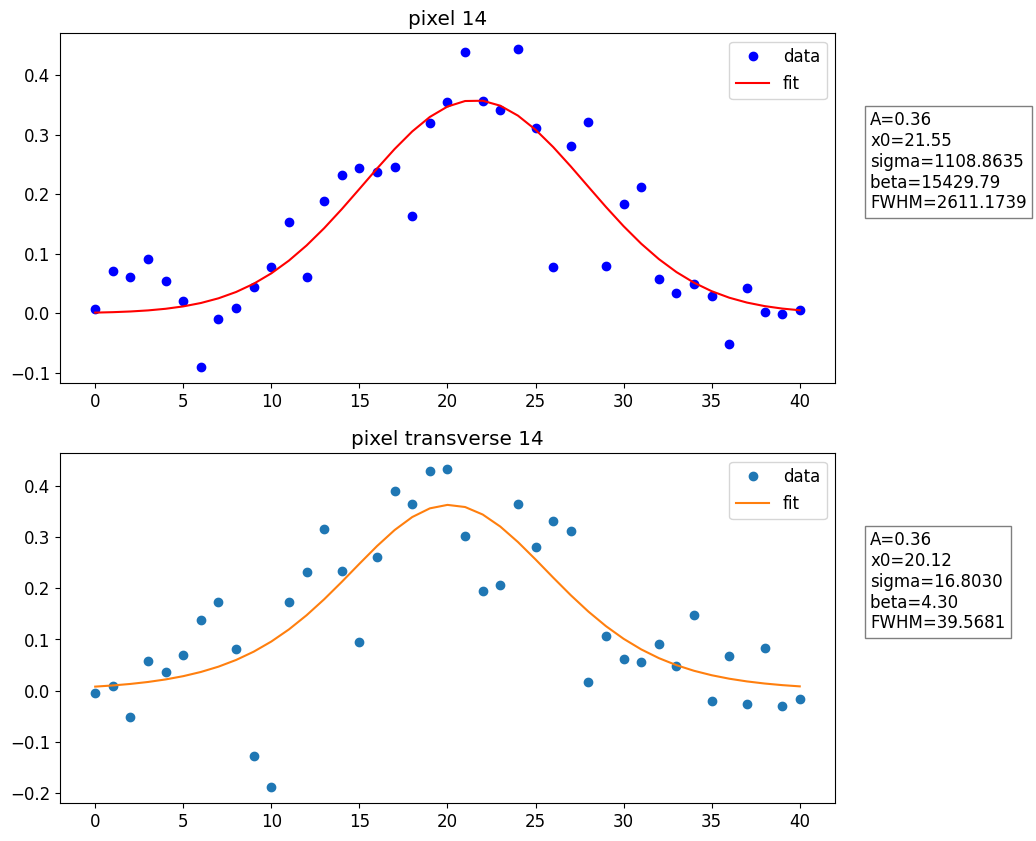

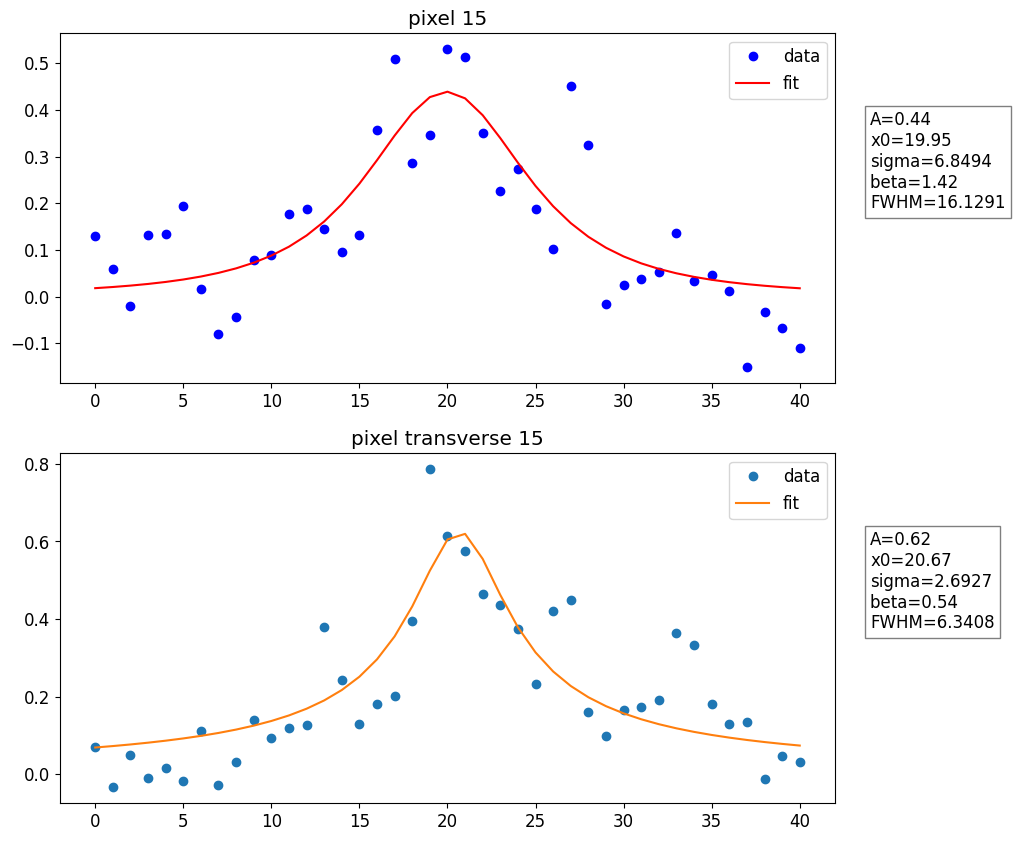

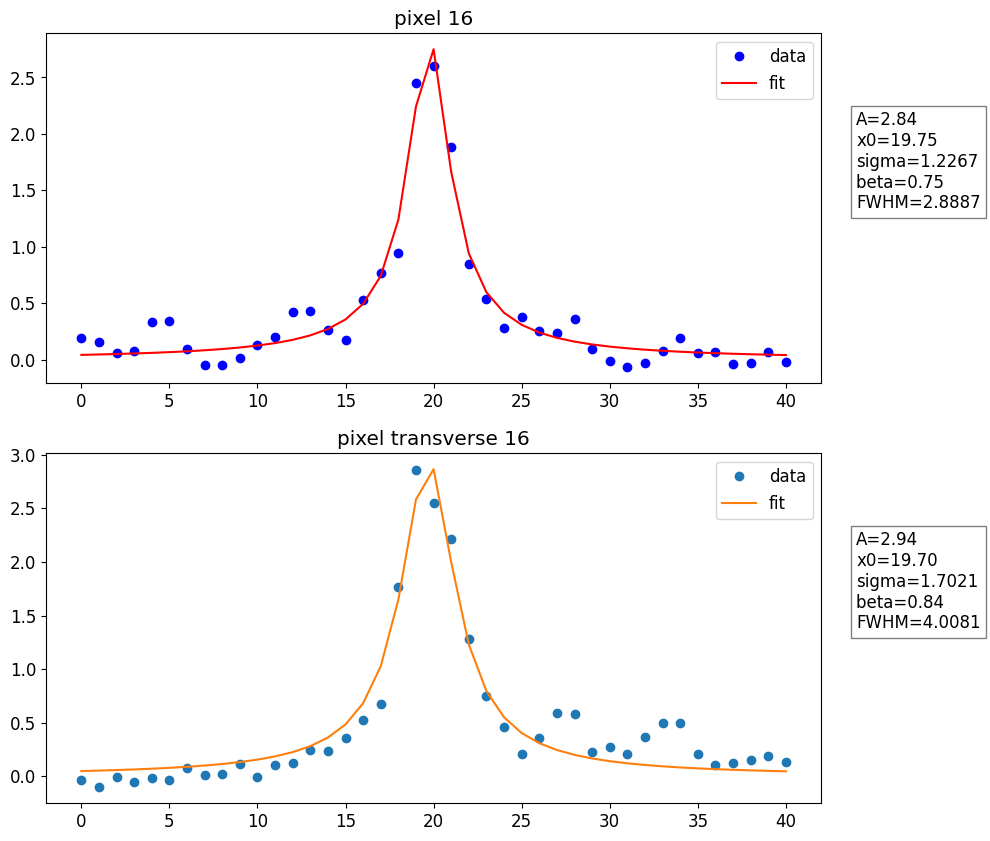

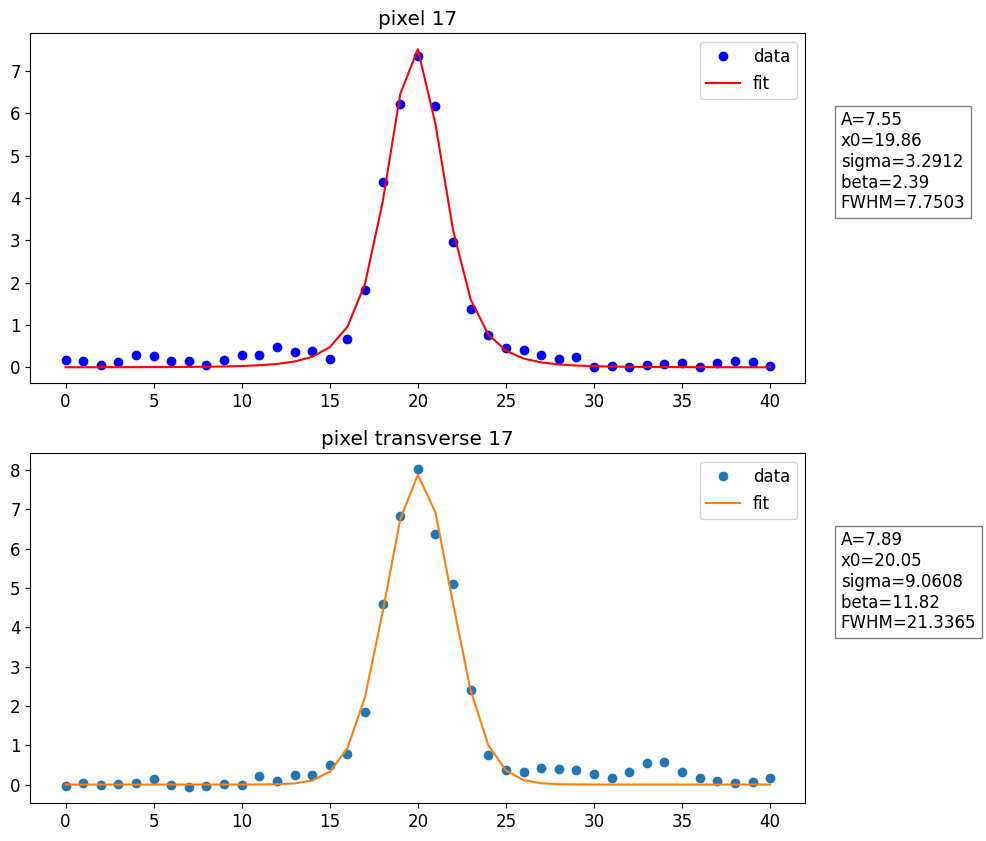

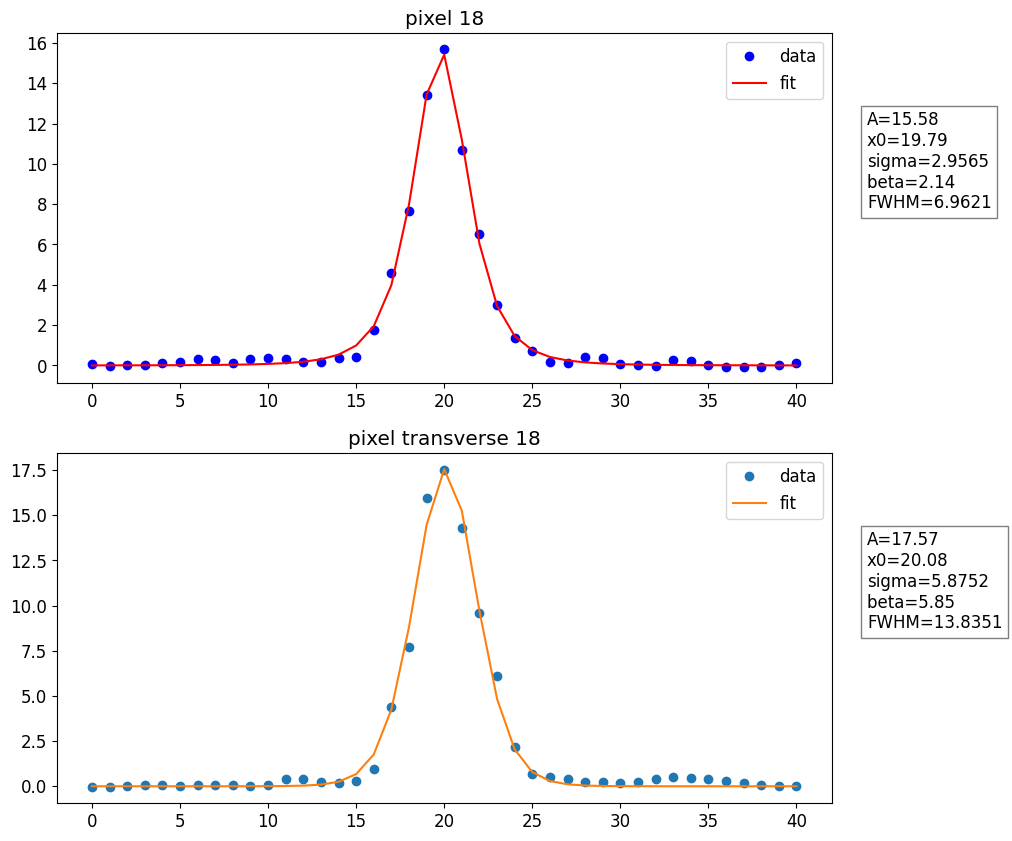

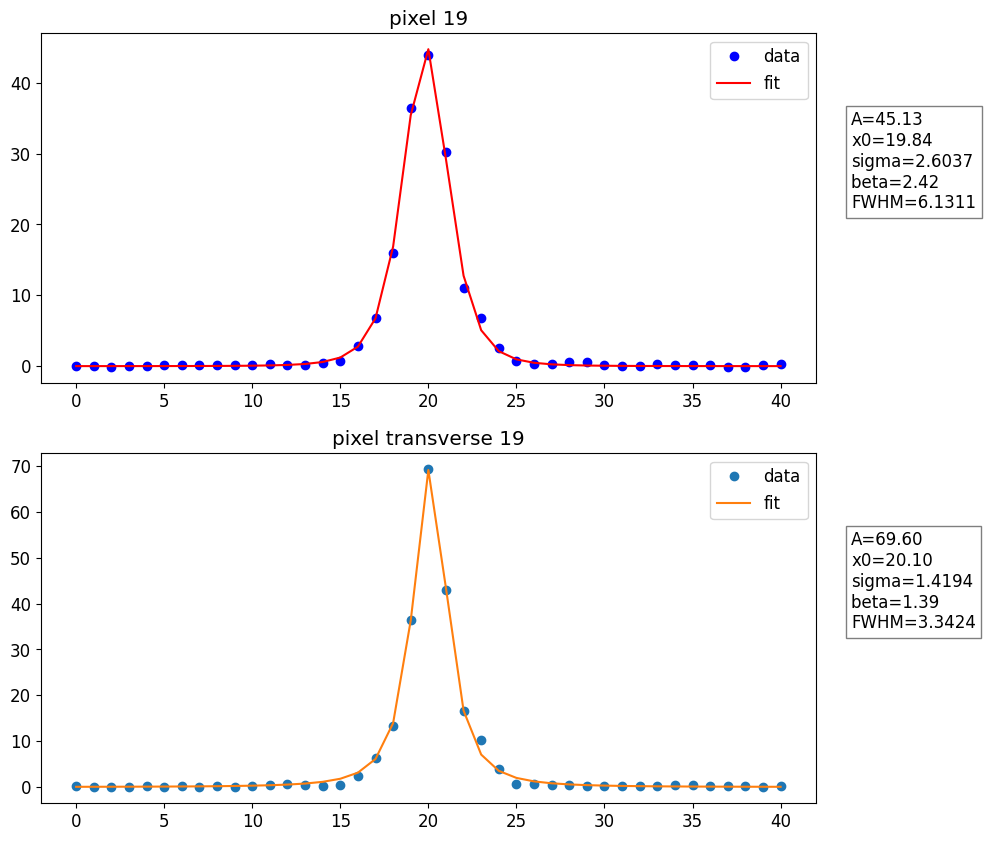

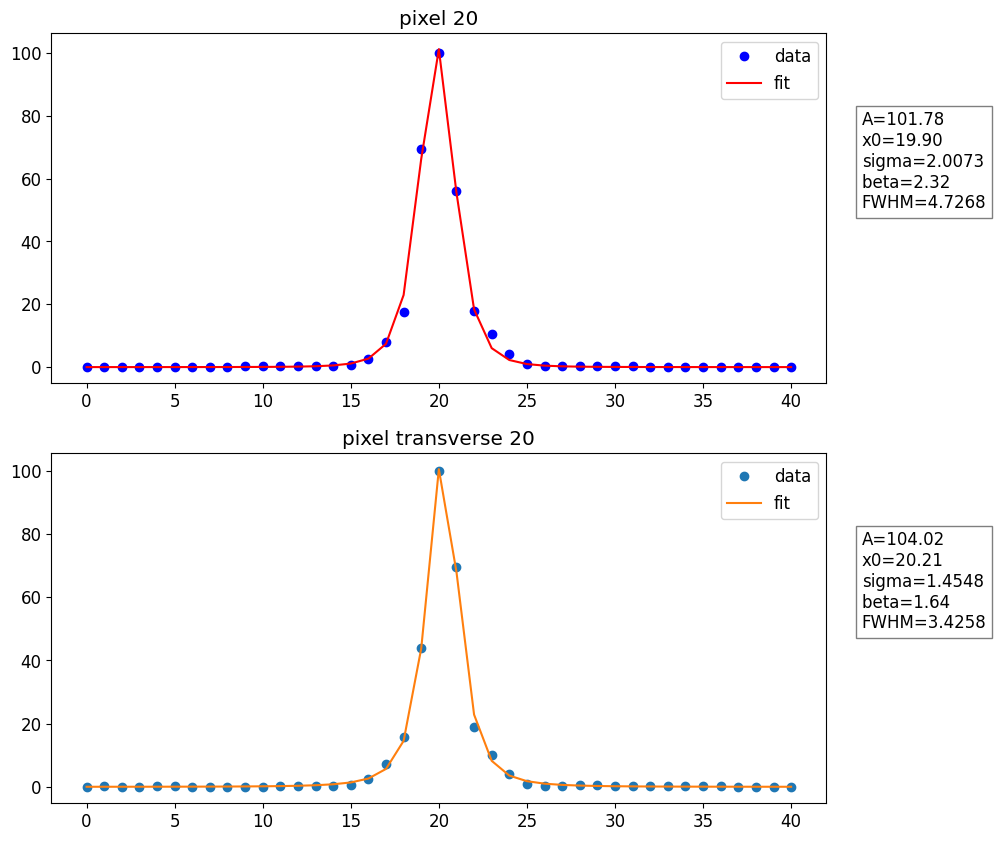

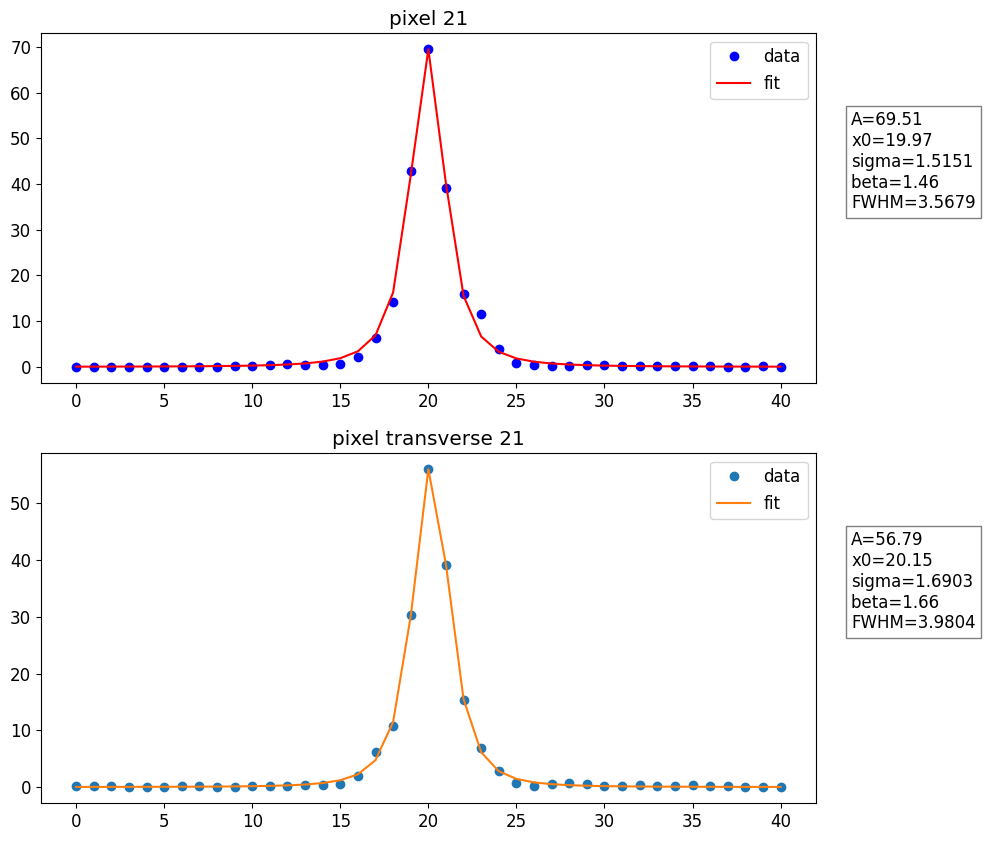

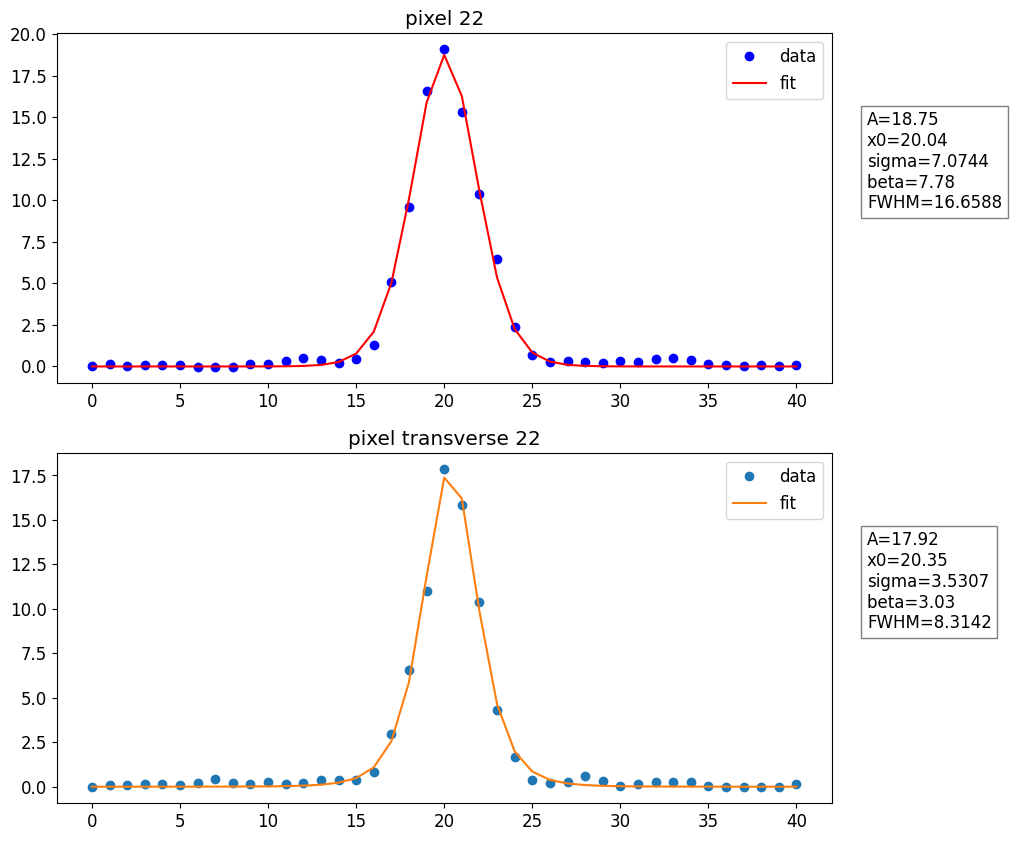

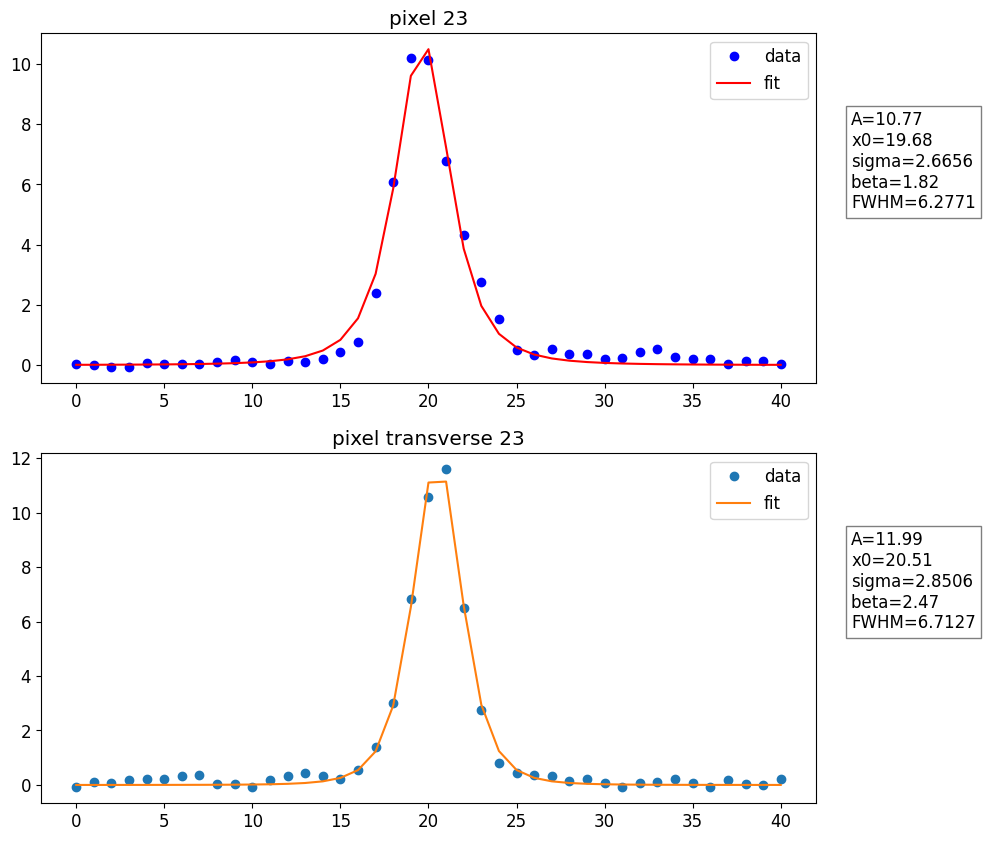

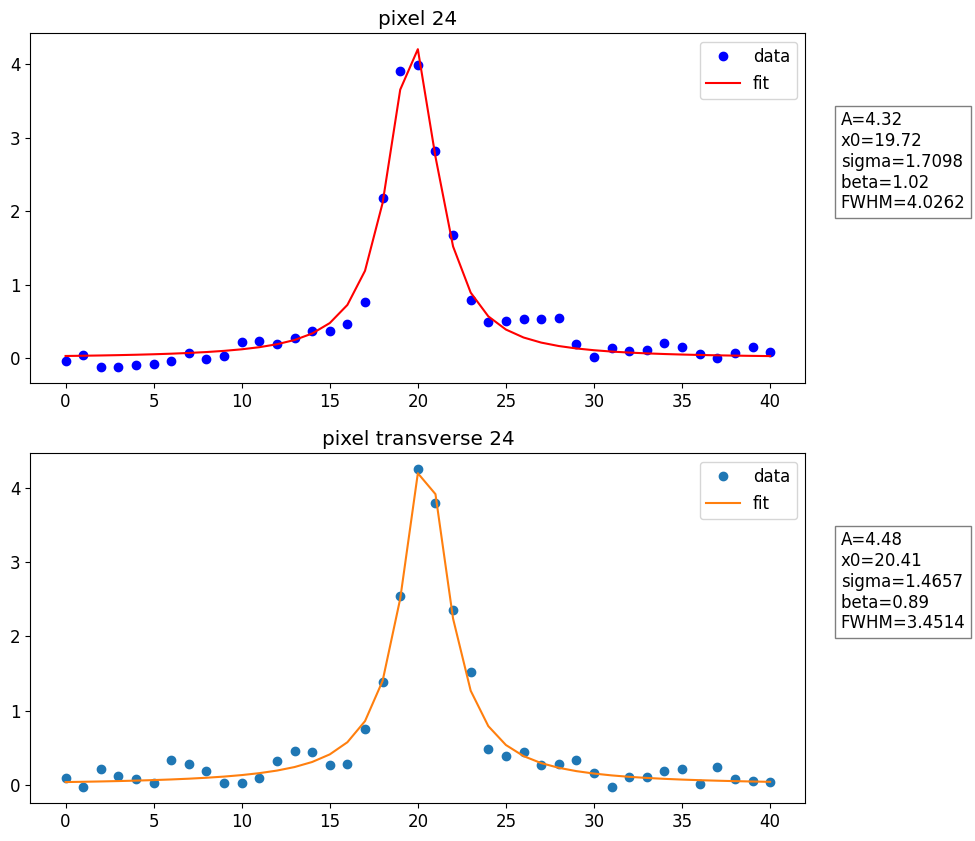

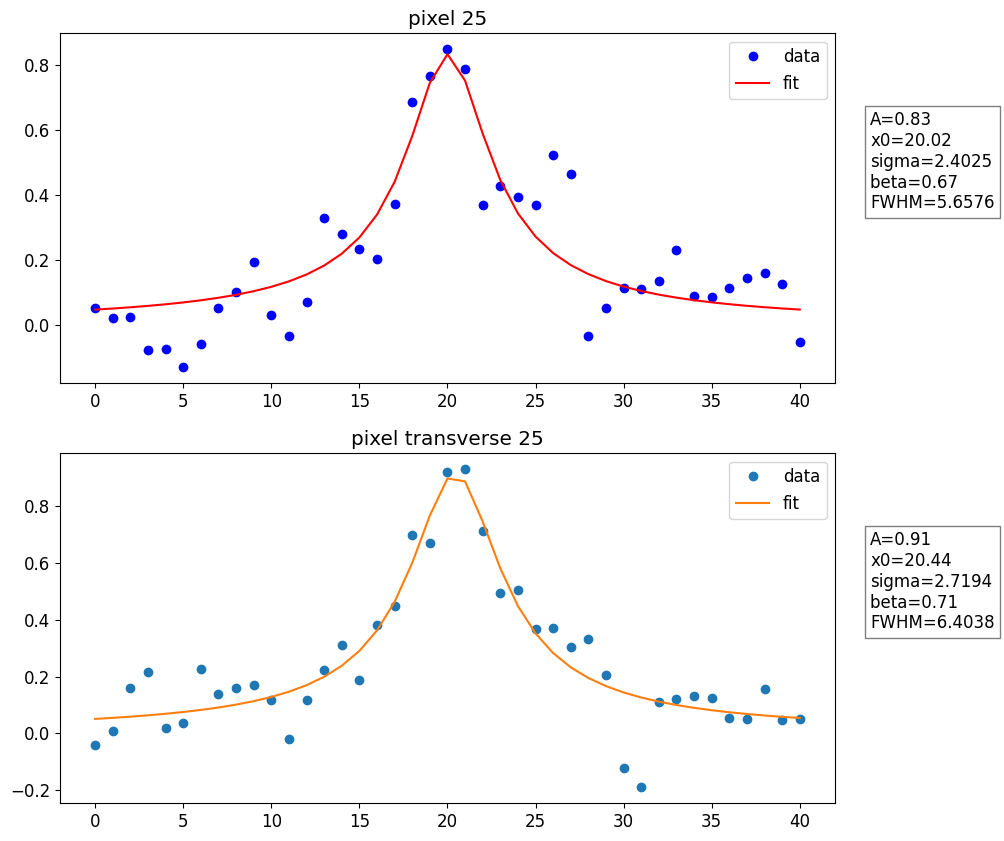

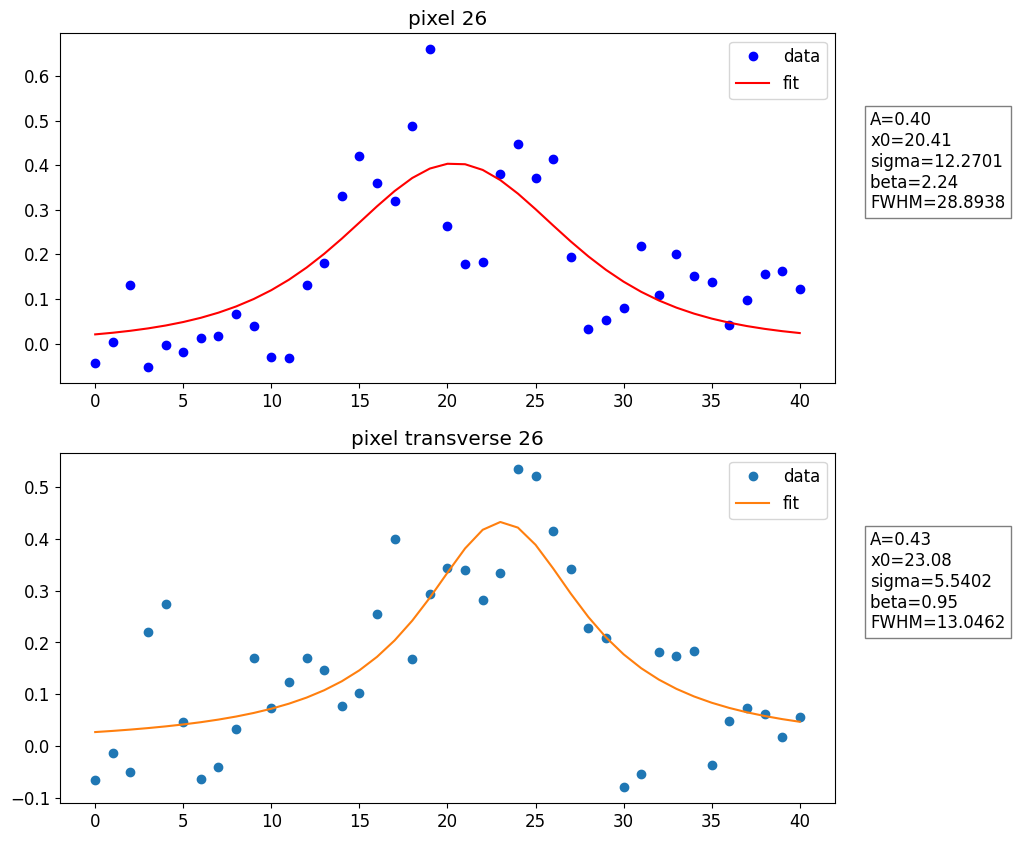

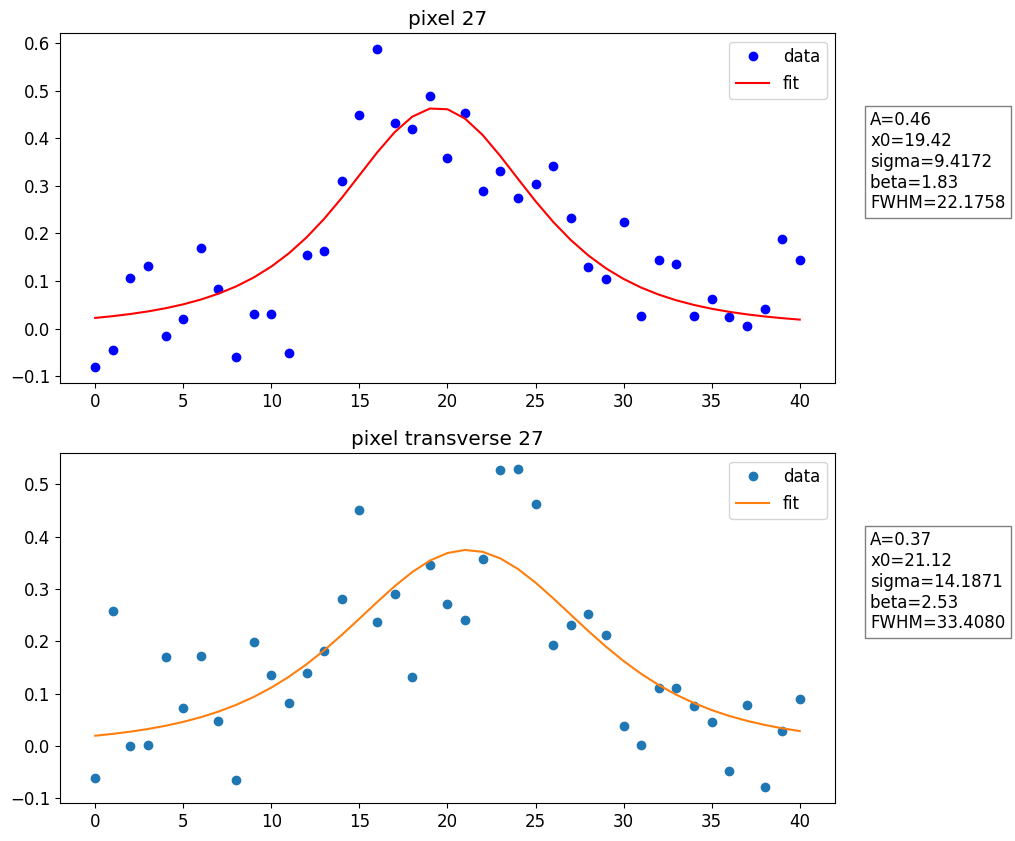

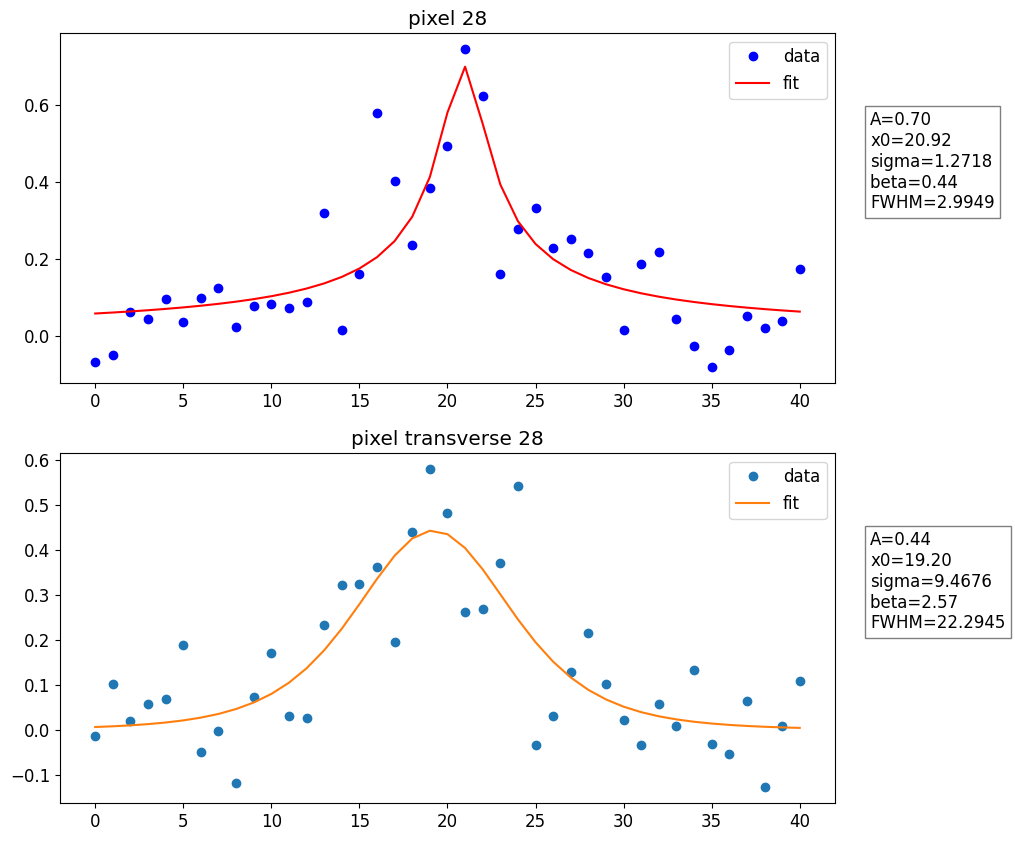

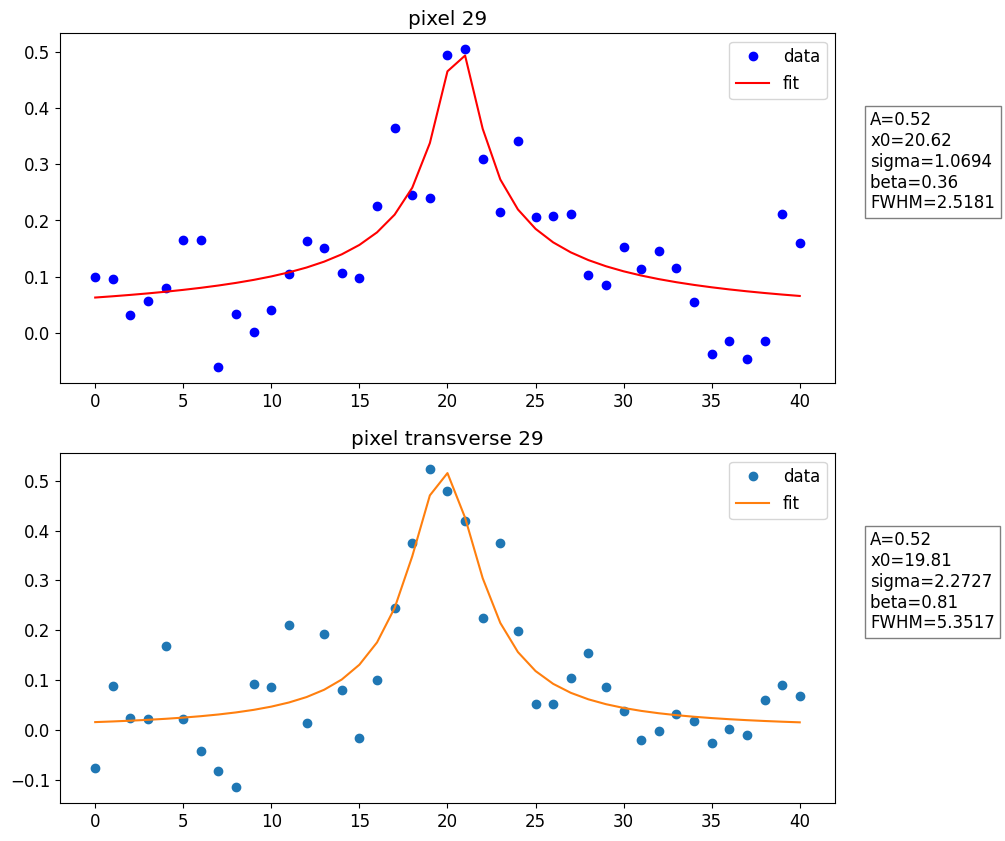

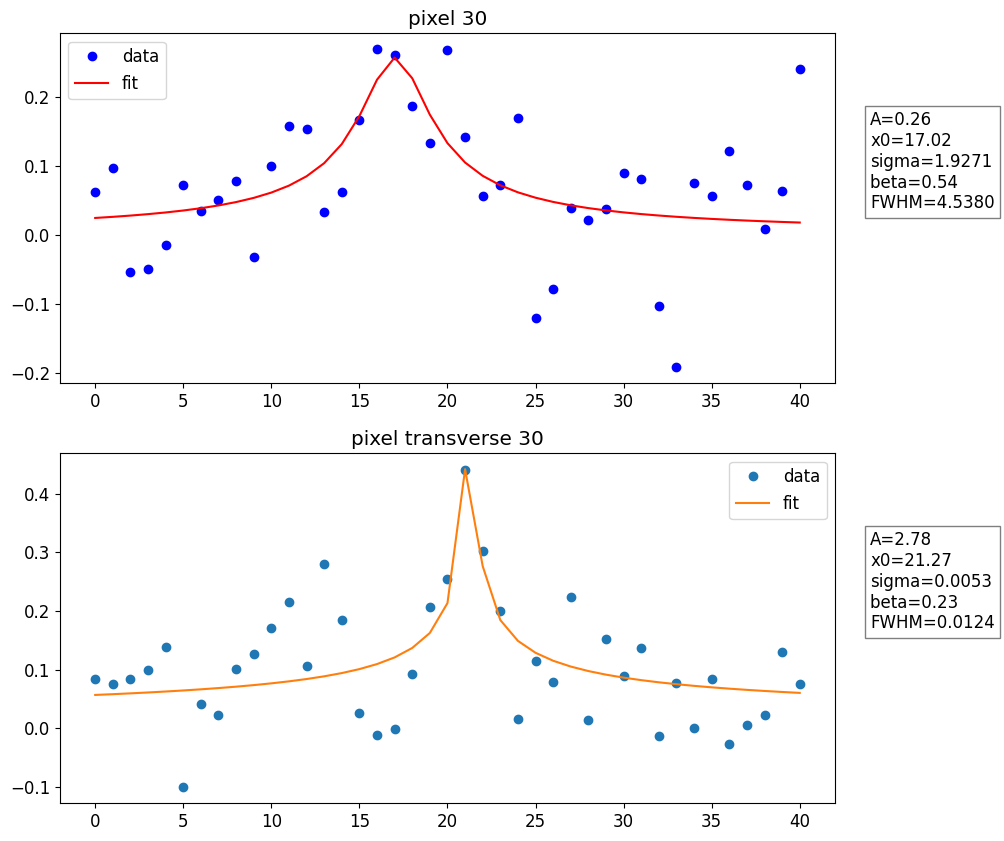

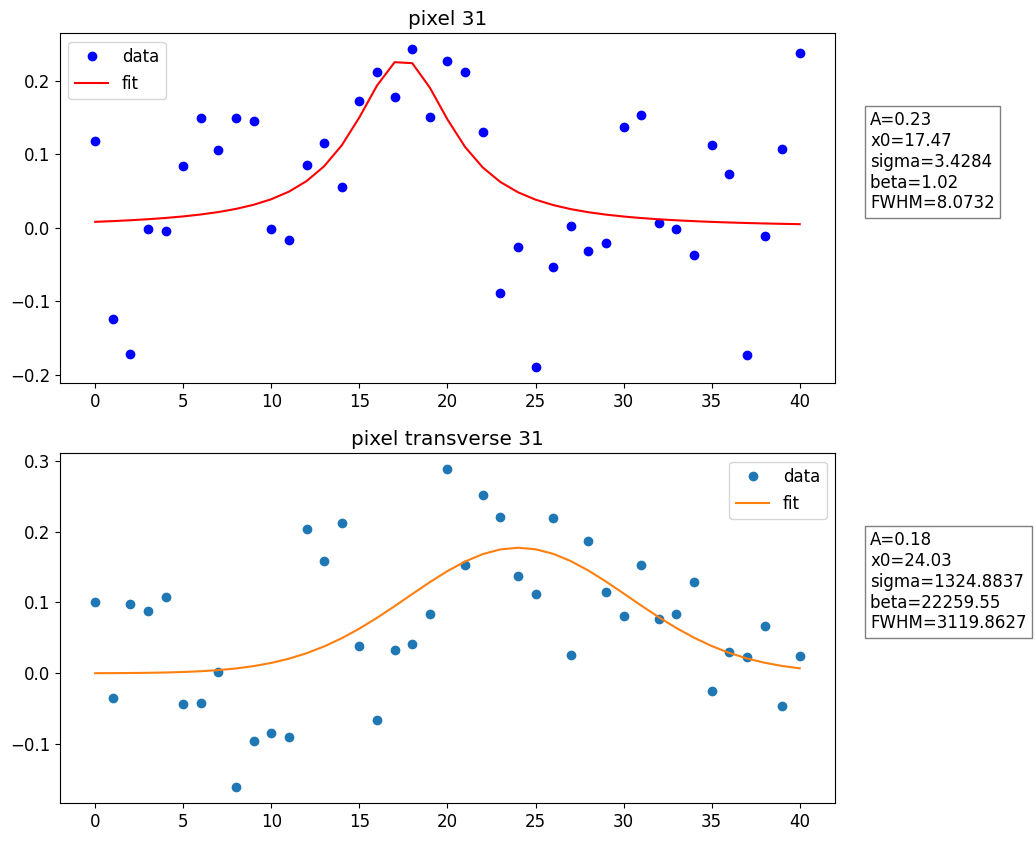

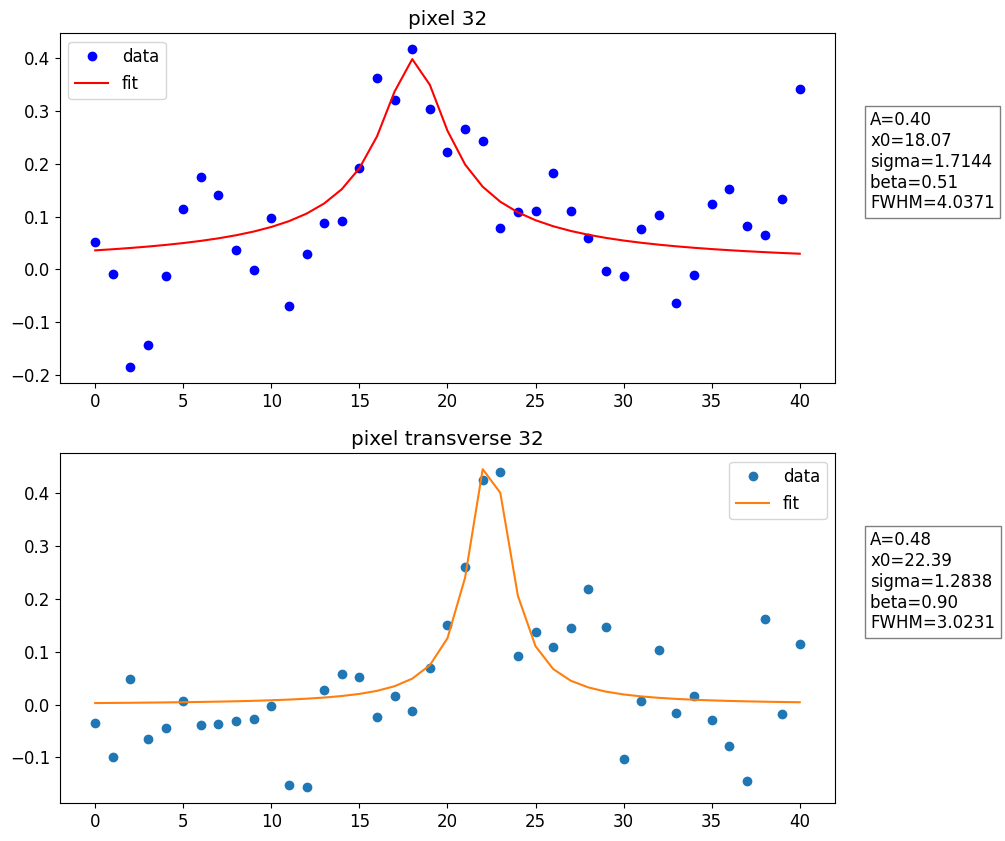

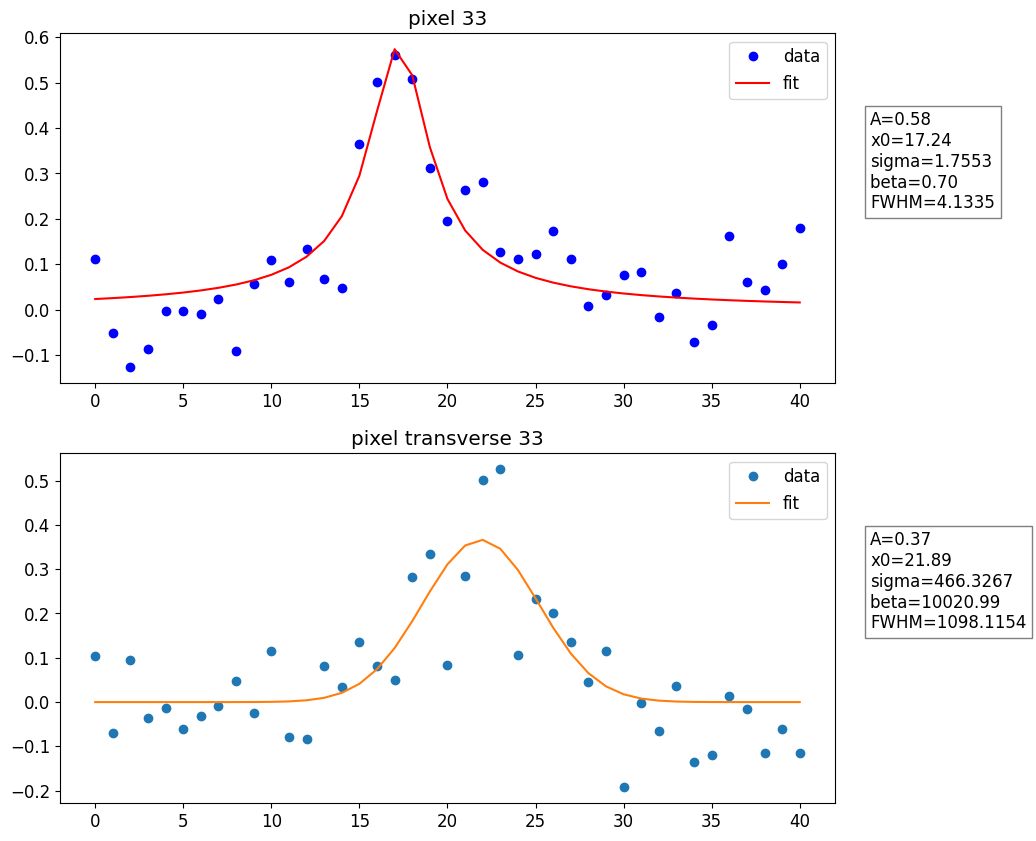

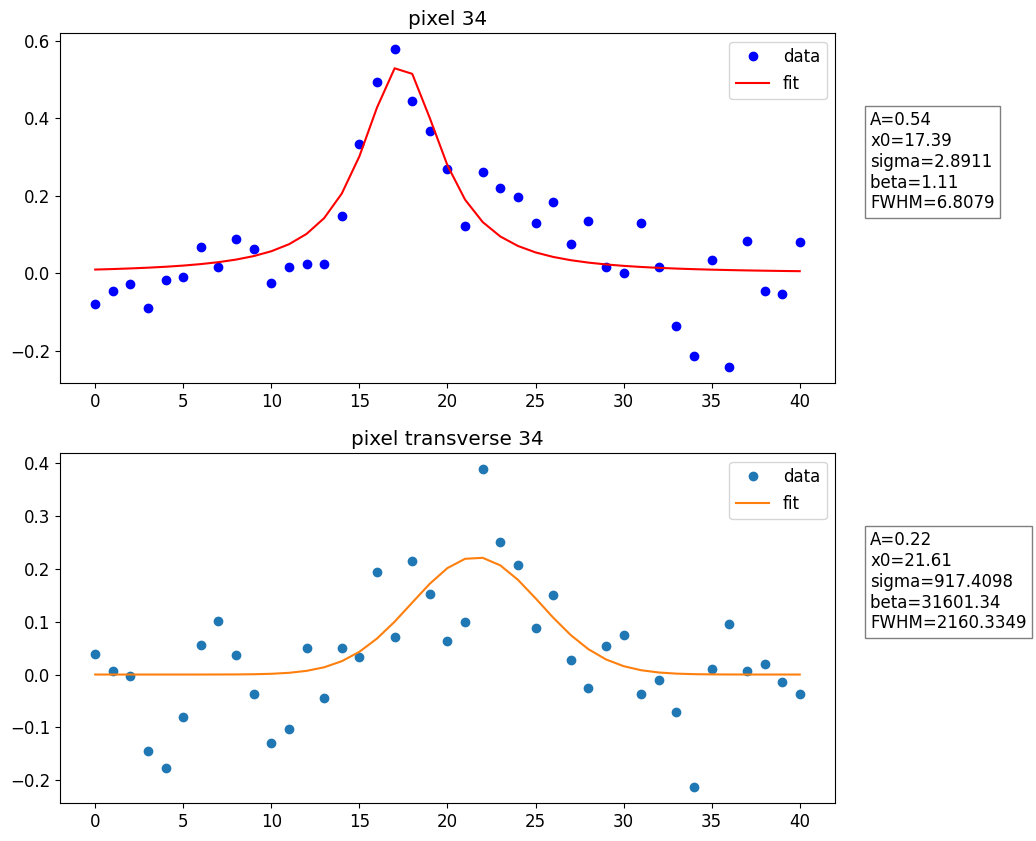

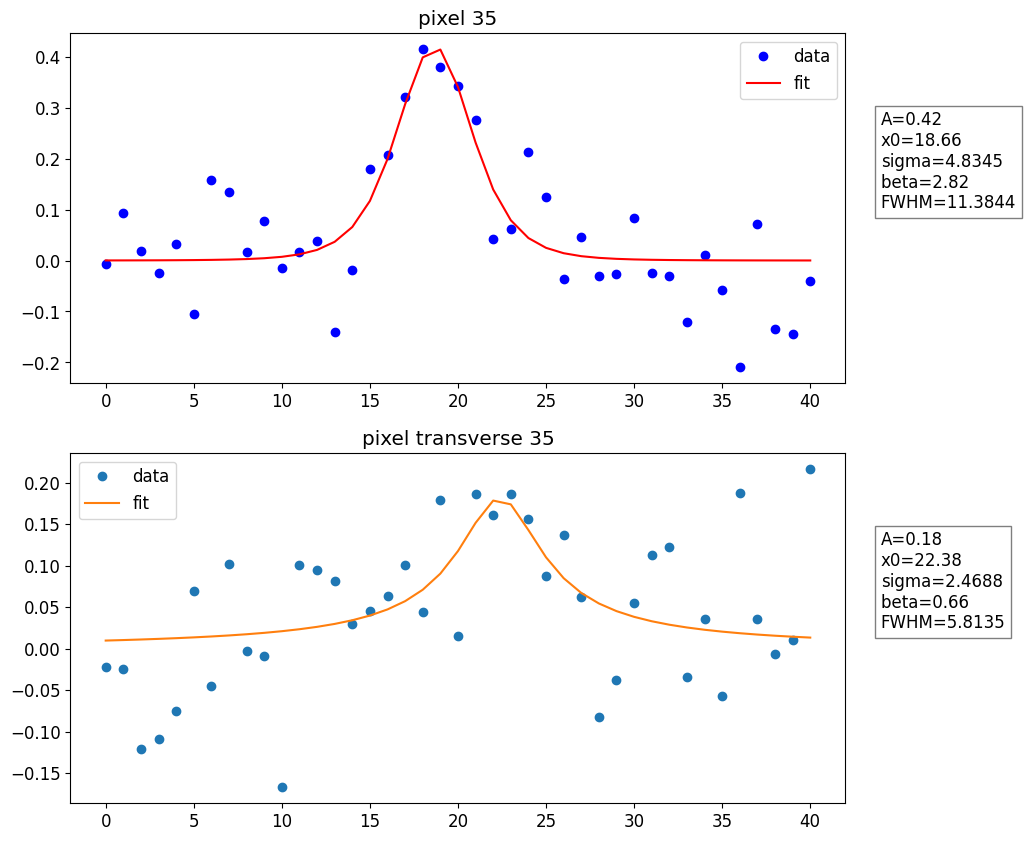

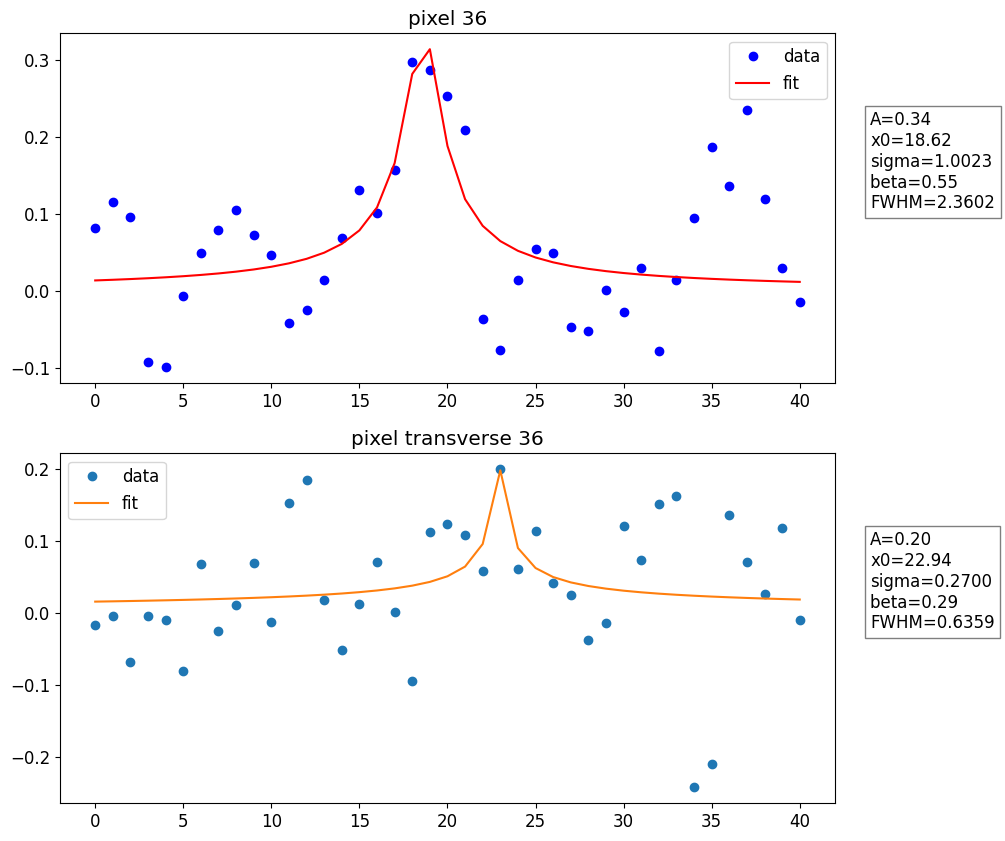

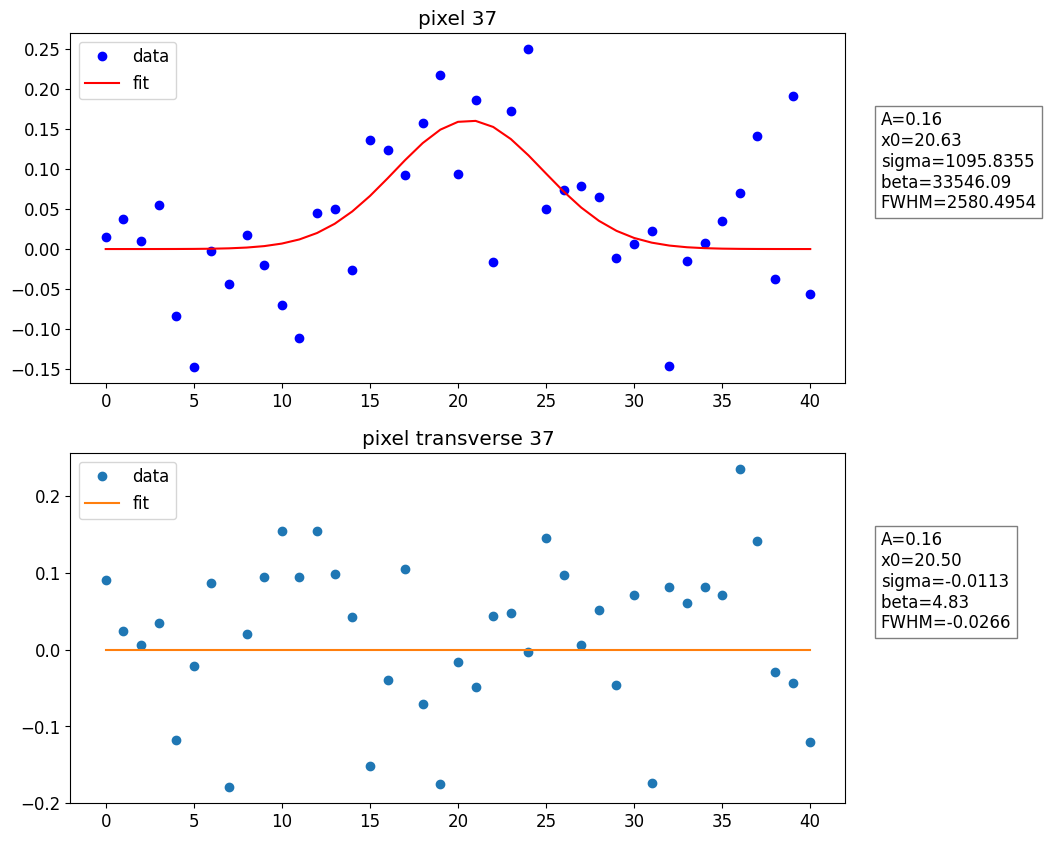

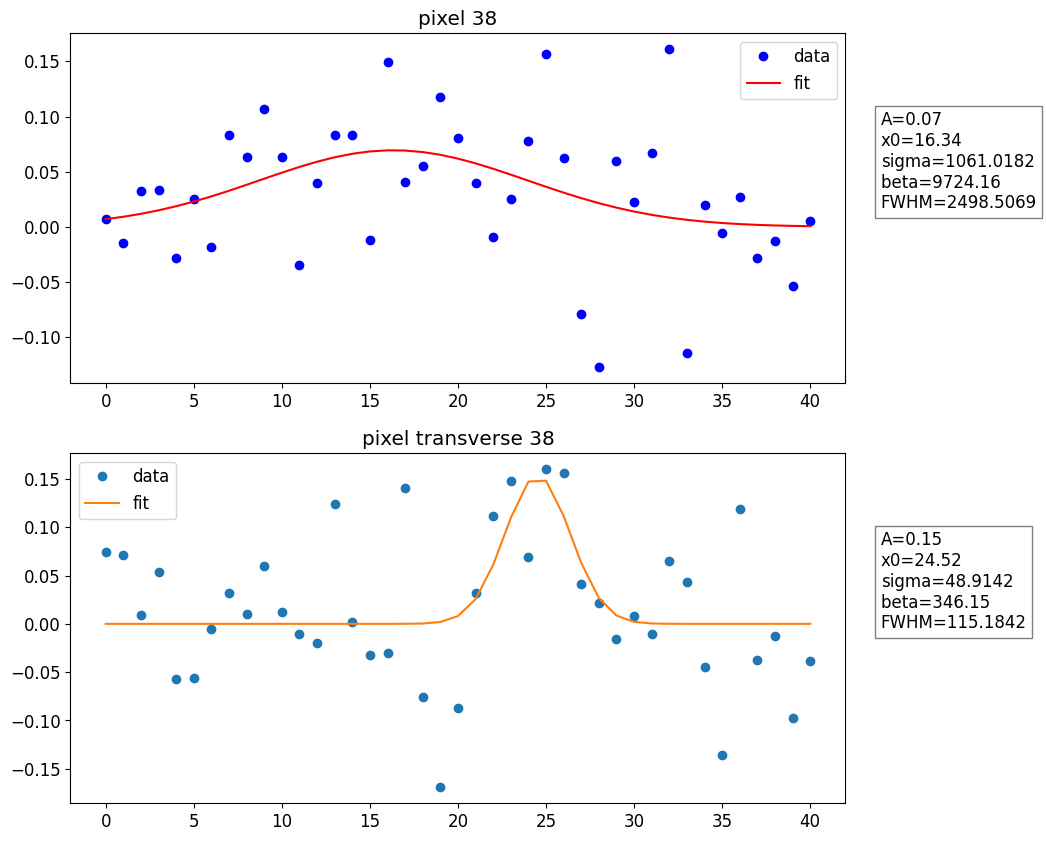

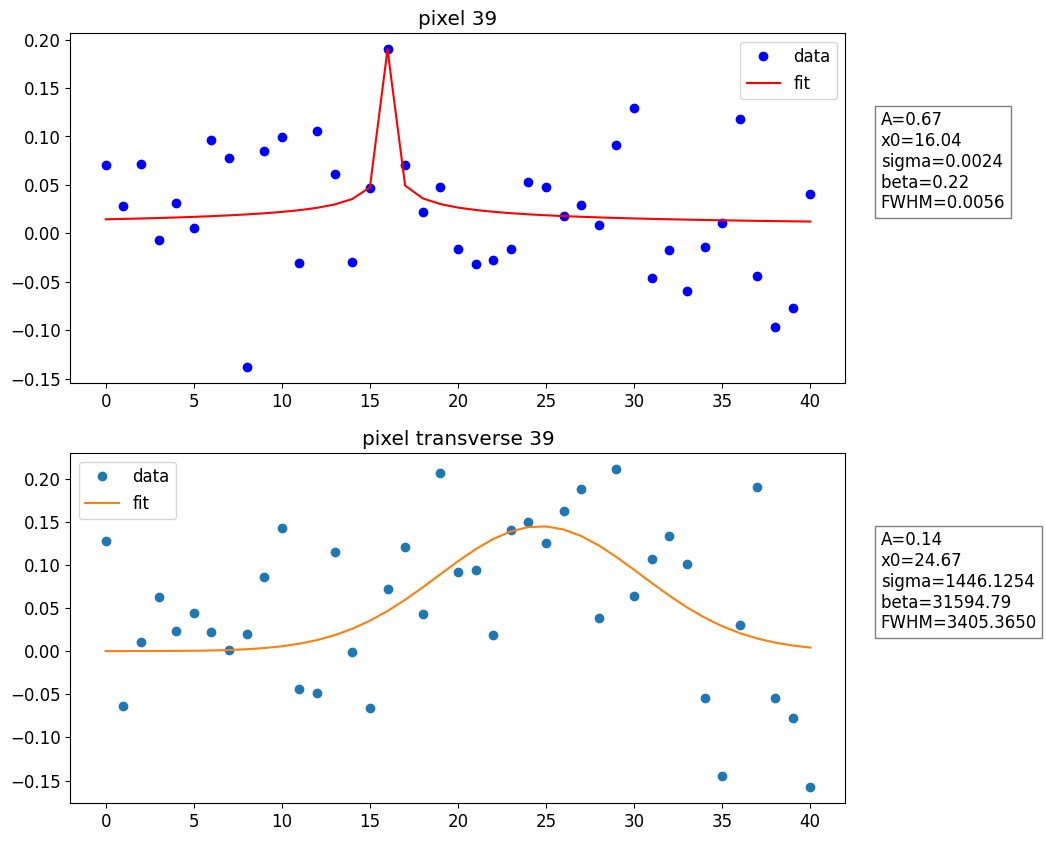

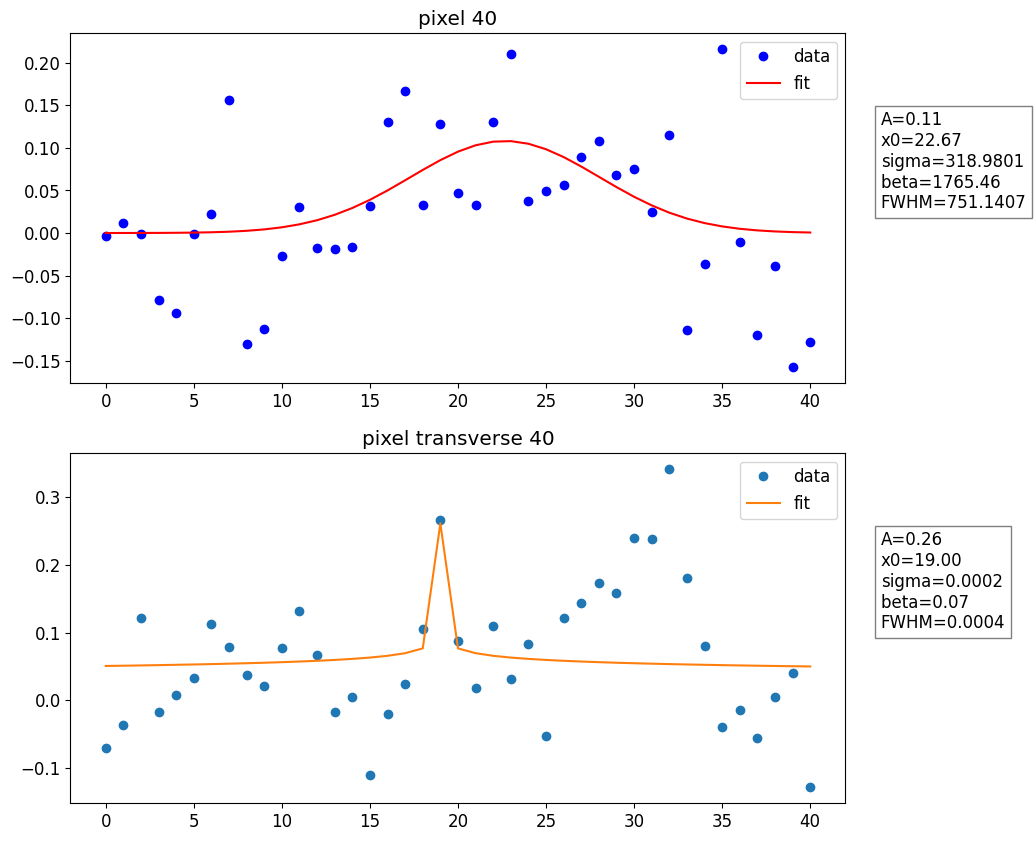

In [126]:
import numpy as np
from lmfit import Model
import matplotlib.pyplot as plt
from lmfit import Model, Parameters
# Define the Moffat function
def moffat(x, A, x0, sigma, beta):
    return A * (1 + ((x - x0) / sigma) ** 2) ** (-beta)
image = data_norm_F160[0]
for n,i in enumerate(image):
    x_data = np.arange(len(i))
    y_data = i #- 2 #/ np.max(i) 
    # Create a model
    model = Model(moffat)

    # Set initial parameter values
    params = model.make_params(A=np.max(y_data), x0=np.median(x_data), sigma=1, beta=2)

    # Fit the model to the data
    result = model.fit(y_data, params, x=x_data)

    # Print fitting results
    #print(result.fit_report())

    # Plot the data and the fit
    best_values = result.best_values
    fig, ax = plt.subplots(2,1,figsize=(10,10))
    ax[0].plot(x_data, y_data, 'bo', label='data')
    ax[0].plot(x_data, result.best_fit, 'r-', label='fit')
    #2*np.sqrt(2*np.log(2)*)
    text = f"A={best_values['A']:.2f}\nx0={best_values['x0']:.2f}\nsigma={best_values['sigma']:.4f}\nbeta={best_values['beta']:.2f}\
    \nFWHM={2*np.sqrt(2*np.log(2))*best_values['sigma']:.4f}"
    ax[0].text(x_data[-1]+4,np.mean(ax[0].get_ylim()), text, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    ax[0].legend()
    ax[0].set_title(f"pixel {n}")
    ####################
    x_data = np.arange(len(i))
    y_data = image.T[n]# / np.max(image.T[n])
    # Create a model
    #model = Model(moffat)

    # Set initial parameter values
    params = model.make_params(A=np.max(y_data), x0=np.median(x_data), sigma=1, beta=2)

    # Fit the model to the data
    result = model.fit(y_data, params, x=x_data)

    # Print fitting results
    #print(result.fit_report())

    # Plot the data and the fit
    best_values = result.best_values
    ax[1].plot(x_data, y_data, 'o', label='data')
    ax[1].plot(x_data, result.best_fit, '-', label='fit')
    #2*np.sqrt(2*np.log(2)*)
    text = f"A={best_values['A']:.2f}\nx0={best_values['x0']:.2f}\nsigma={best_values['sigma']:.4f}\nbeta={best_values['beta']:.2f}\
    \nFWHM={2*np.sqrt(2*np.log(2))*best_values['sigma']:.4f}"
    ax[1].text(x_data[-1]+4,np.mean(ax[1].get_ylim()), text, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    ax[1].legend()
    ax[1].set_title(f"pixel transverse {n}")
    plt.show()

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

import lmfit
from lmfit.lineshapes import gaussian2d, lorentzian

In [17]:
def moffat_2d(x, y, A, x0, y0, sigma_x, sigma_y, beta):
    return A * (1 + ((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2) ** (-beta)

In [95]:
npoints = 10000
np.random.seed(2021)
x = np.arange(data_norm_F160[0].shape[0])
y = np.arange(data_norm_F160[0].shape[0])
z =  data_norm_F160[0]-2

In [19]:
def moffat_function(x, y, amp, fwhm, beta, center_x, center_y):
    """
    :param x: 1D array of x positions
    :param y: 1D array of y positions
    :param amp: the amplitude coefficient
    :type amp: float
    :param fwhm: the full width at half maximum value
    :type fwhm: float
    :param beta: the Moffat beta parameter
    :type beta: float
    :param center_x: x position of the center
    :type center_x: float
    :param center_y: y position of the center
    :type center_y: float

    :return: 2D Moffat
    
    """
    r0 = fwhm / (2. * np.sqrt(2. ** (1. / beta) - 1.))
    #print(r0)
    delta_x = np.subtract(x, center_x)
    #print(delta_x)
    delta_y = np.subtract(y, center_y)
    #print(delta_y)
    rr_gg = (delta_x / r0) ** 2 + (delta_y / r0) ** 2
    return amp * (1 + rr_gg) ** (-beta)

In [ ]:
#0.20541502, 0.39580863, 0.09654924, 0.12623017, 0.44868466],      dtype=float64), 'y0': Array([-0.07597347

In [32]:
#{'fwhm': Array([4.03336561], dtype=float64), 'beta': Array([50.], dtype=float64)

19.92402653

In [114]:
# Set initial parameter values individually
params = Parameters()
params.add('amp', value=100 )
params.add('center_x', value=20.20541502,vary=False)
params.add('center_y', value=19.92402653,vary=False)
params.add('fwhm', value=6)
params.add('beta', value=2)
#1.73, 6
model = Model(moffat_function,independent_vars=["x","y"])
result = model.fit(z, x=x, y=y, params=params)#, weights=1/np.sqrt(sigma_2_norm_F160[0]))
lmfit.report_fit(result)
X, Y = np.meshgrid(np.linspace(x.min(), x.max(), 41),
                   np.linspace(y.min(), y.max(), 41))
fig, axs = plt.subplots(2, 2, figsize=(20, 20))

vmax = np.nanpercentile(z, 99.9)

ax = axs[0, 0]
im = ax.imshow(z,)
ax.scatter(20.20541502,19.92402653)
#art = ax.pcolor(X, Y, z, vmin=0, vmax=vmax, shading='auto')
#ax.contourf(x, y,z)
plt.colorbar(im, ax=ax)
#plt.colorbar
ax.set_title('Data')

ax = axs[0, 1]
fit = model.func(X, Y,**result.best_values)#)
#art = ax.pcolor(X, Y, fit, vmin=0, vmax=vmax, shading='auto')
#ax.contourf(X, Y, fit)
im = ax.imshow(fit)
ax.scatter(20.20541502,19.92402653)
plt.colorbar(im, ax=ax)
#plt.colorbar(art, ax=ax, label='z')
ax.set_title('Fit')

ax = axs[1, 0]
#fit = model.func(X, Y, **result.best_values)
#art = ax.pcolor(X, Y, z-fit, vmin=0, vmax=vmax, shading='auto')

im = ax.imshow(z-fit)
plt.colorbar(im, ax=ax)
ax.scatter(20.20541502,19.92402653)
#plt.colorbar(art, ax=ax, label='z')
ax.set_title('Data - Fit')

for ax in axs.ravel():
    ax.set_xlabel('x')
    ax.set_ylabel('y')
axs[1, 1].remove()
plt.show()

ValueError: Assign each parameter an initial value by passing Parameters or keyword arguments to fit.
Missing parameters: ['amp', 'fwhm', 'center_x', 'center_y']
Non initialized parameters: []

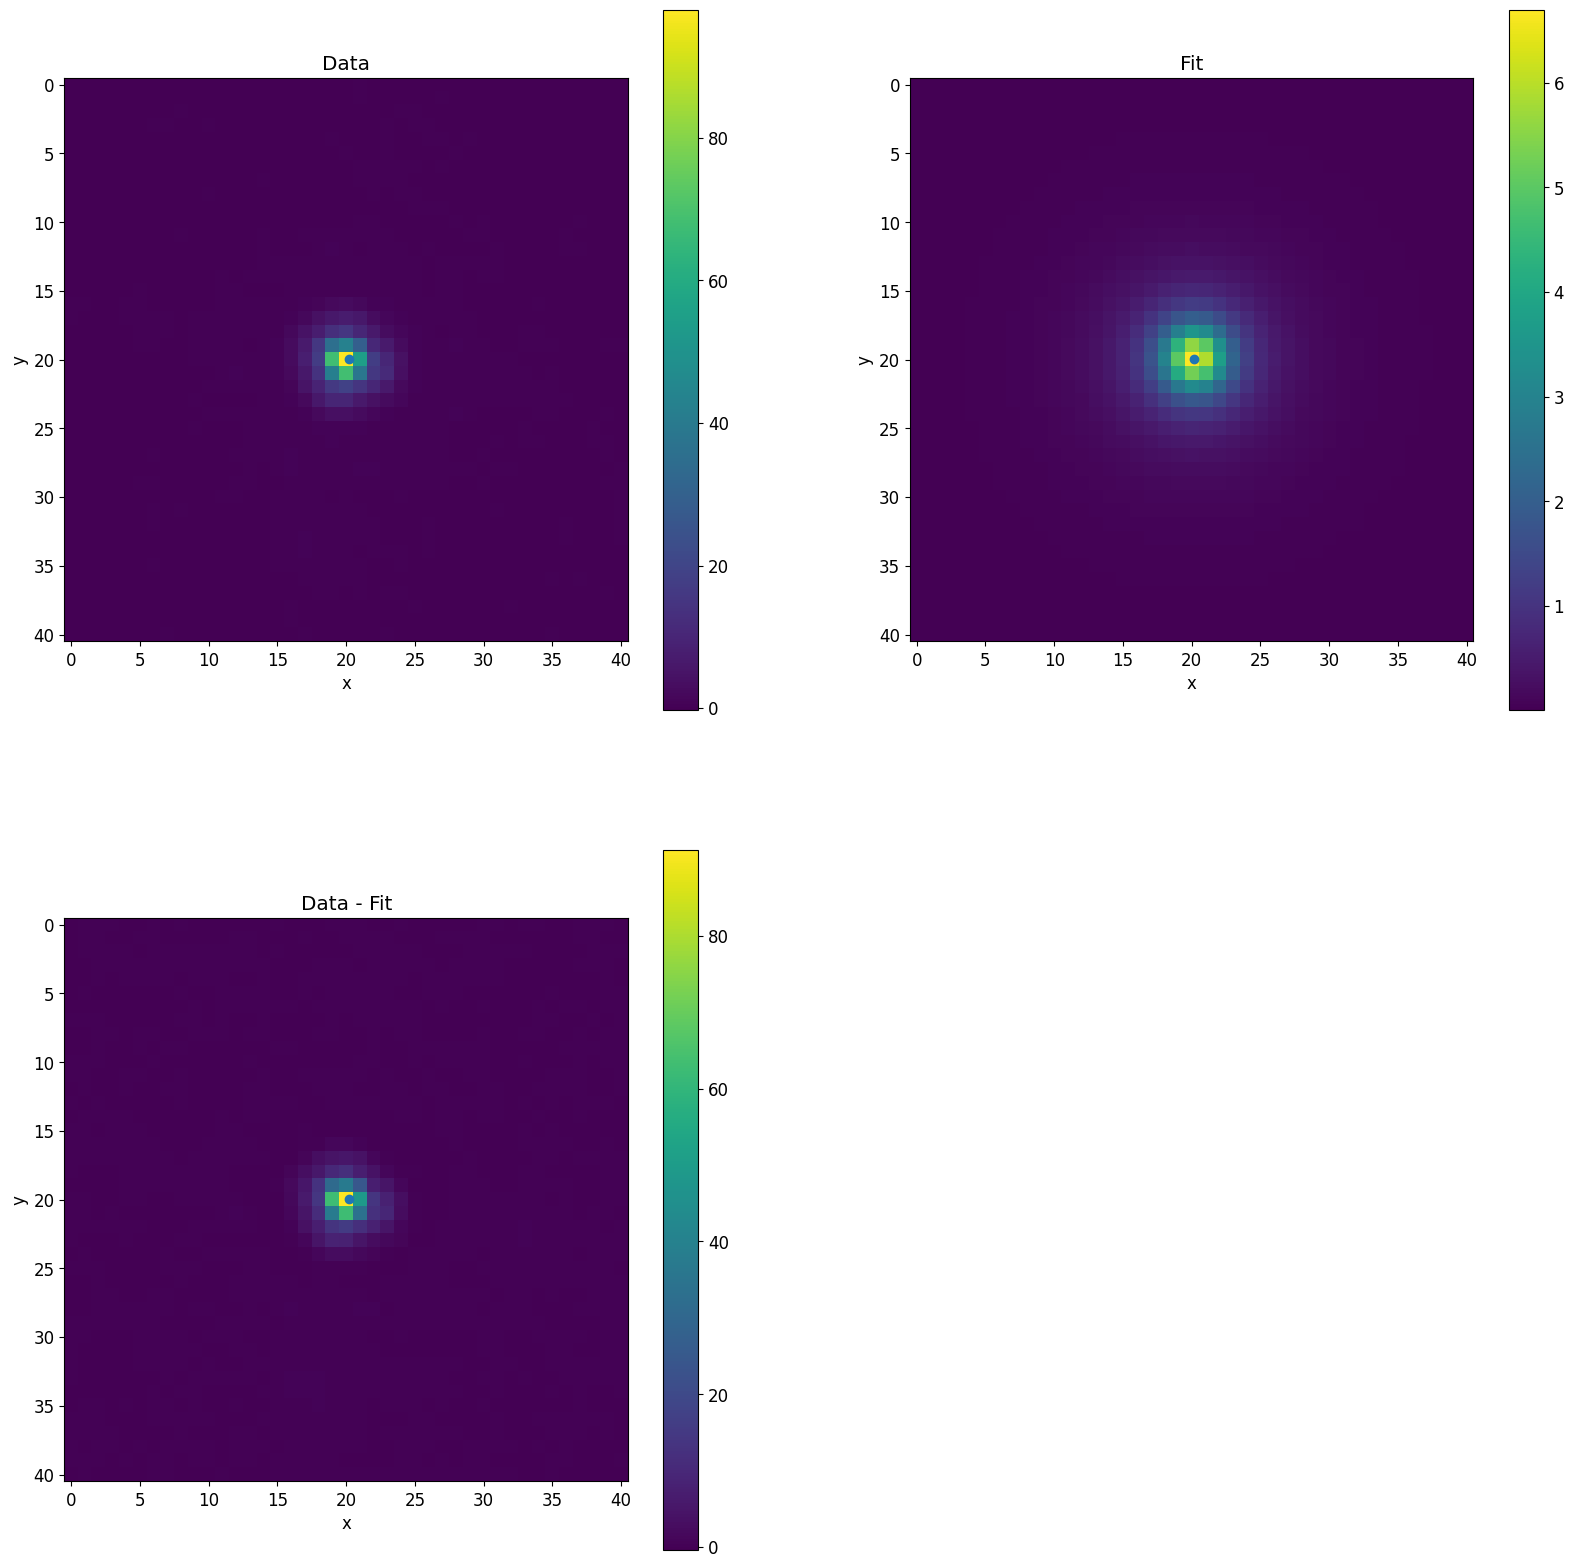

# F475X

In [19]:
Data_F475X,path_file_F475X=data_for_starred('WG0214-2105_F475X_drc_sci.fits',remove_star=[],shift=[0,0],star_num_pix=41,make_plots=False,save=False)

Statistical properties data raw 
 mean=0.0006480228747251283
 median=0.00045212425175122917
 std=0.01056914055411225
Using reference exposure time of 792.0 s
Stats wht (mean, std, max): 766.6969181510958 102.24270412457324 866.2867431640625
Re-normalized the WHT map.
Median afterwards: 729.1165623752487


02h14m16.67s -21d04m59.00s
02h14m14.57s -21d04m37.87s
02h14m13.47s -21d05m19.64s
02h14m15.87s -21d04m55.02s
02h14m16.51s -21d04m23.72s
Mean sigma2_sky = 6.609421013541481e-05
Mean sigma2_target = 1.32350063366658e-05
Mean sigma2_sky = 4.55503067560961e-05
Mean sigma2_target = 1.5967246887698766e-05
Mean sigma2_sky = 0.00014063558300005512
Mean sigma2_target = 6.625302731292607e-05
Mean sigma2_sky = 8.361574152142704e-05
Mean sigma2_target = 2.8269095060626e-05
Mean sigma2_sky = 3.910938656575689e-05
Mean sigma2_target = 1.0382609610591903e-05


F475X
(5, 41, 41)


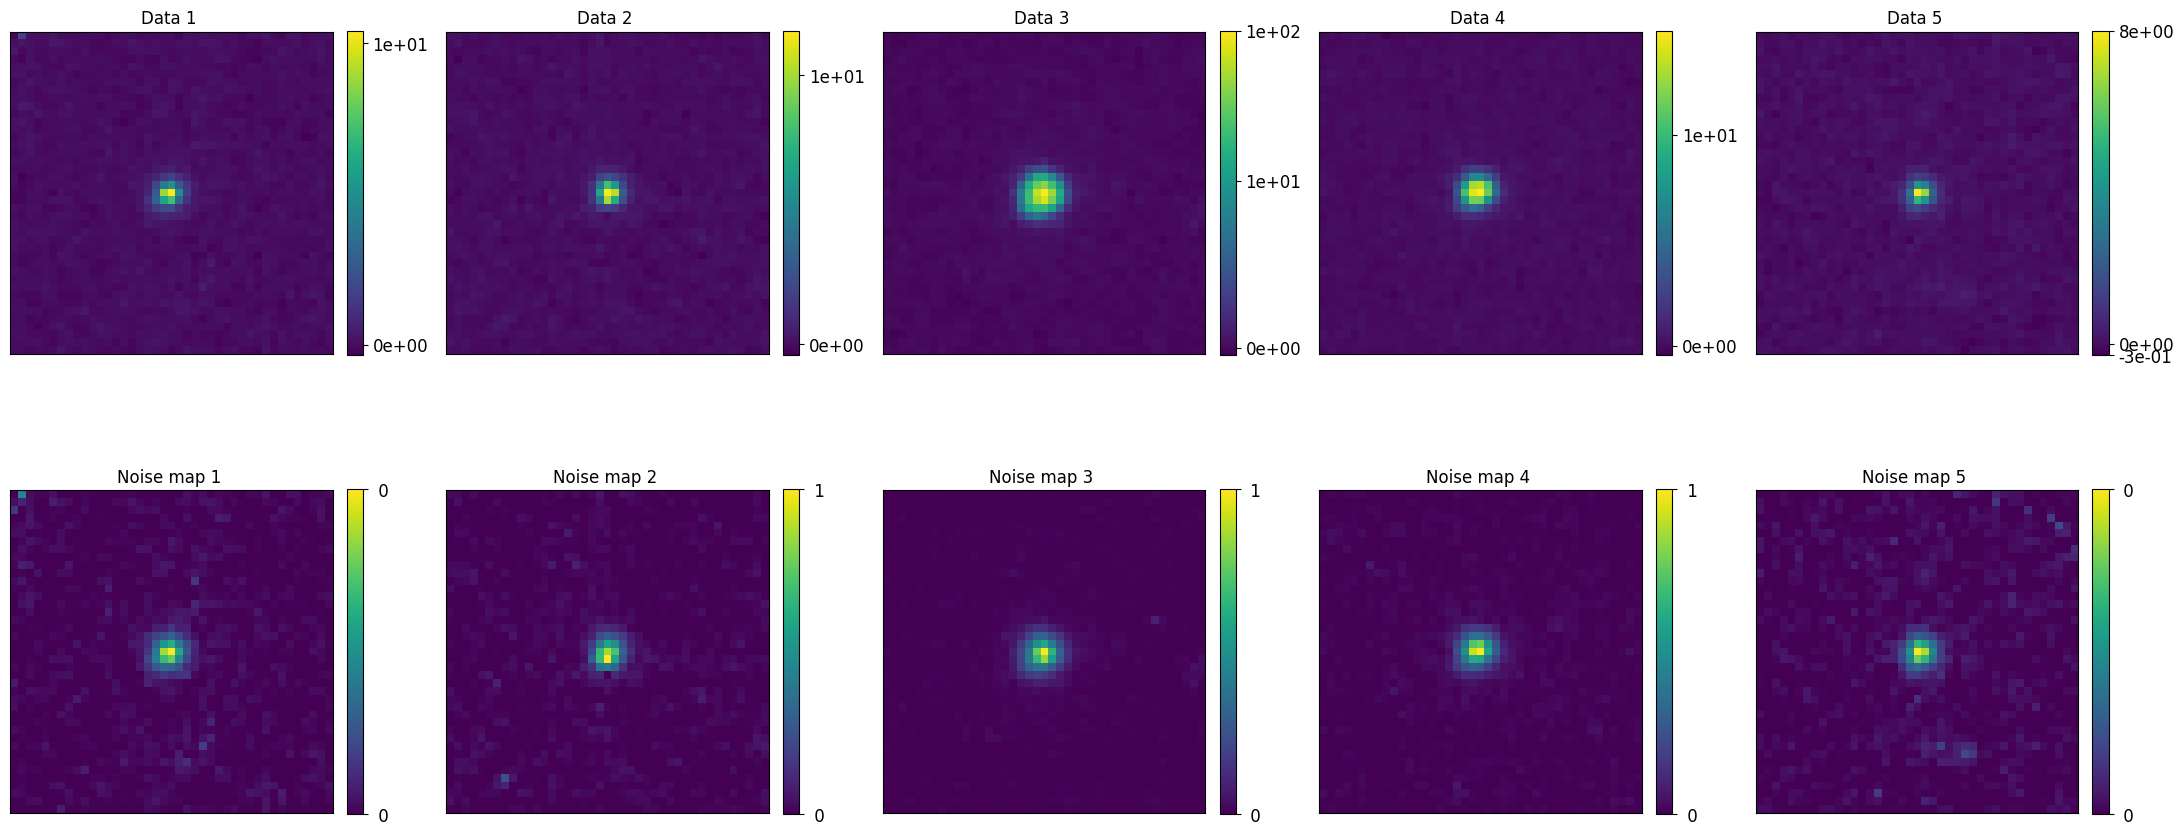

In [20]:
# Parameters
subsampling_factor = 3 #this can be increased for a better resolution, try 3 or 4 ! 
n_iter_initial = 100
n_iter = 4000 

lambda_scales = 3.0
lambda_hf = 3.0
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
include_moffat = True

method1 = 'l-bfgs-b'
method2 = 'adabelief'

convolution_method = 'fft'
# Data 
print("F475X")
# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F475X = Data_F475X["data_cutout_norm"]
norm_F475X=Data_F475X["norm"]
sigma_2_norm_F475X = Data_F475X['sigma2_norm']
# number of stars
N = len(data_norm_F475X)
# data dimensions
image_size = np.shape(data_norm_F475X)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F475X))
fig = pltf.display_data(data_norm_F475X, sigma_2 = sigma_2_norm_F475X)

#### Method 1.

Initial Guess : {'kwargs_moffat': {'fwhm': 3, 'beta': 2.0, 'C': 18.04400118965094}, 'kwargs_gaussian': {'a': Array([ 6.86098965,  6.88802976, 51.34262615, 20.21405233,  4.91430806],      dtype=float64), 'x0': array([0., 0., 0., 0., 0.]), 'y0': array([0., 0., 0., 0., 0.])}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
Moffat fit : {'kwargs_moffat': {'fwhm': Array([2.85166633], dtype=float64), 'beta': Array([8.15331406], dtype=float64), 'C': Array([18.04400119], dtype=float64)}, 'kwargs_gaussian': {'a': Array([10.27883452,  9.22829948, 76.7643895 , 26.07576695,  7.82827838],      dtype=float64), 'x0': Array([-0.3047429 ,  0.21789   , -0.25996908, -0.42129124,  0.31387585],      dtype=float64), 'y0': Array([-0.17854843,  0.11402064, -0.24152578,  0.17538421, -0.0757693 ],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}


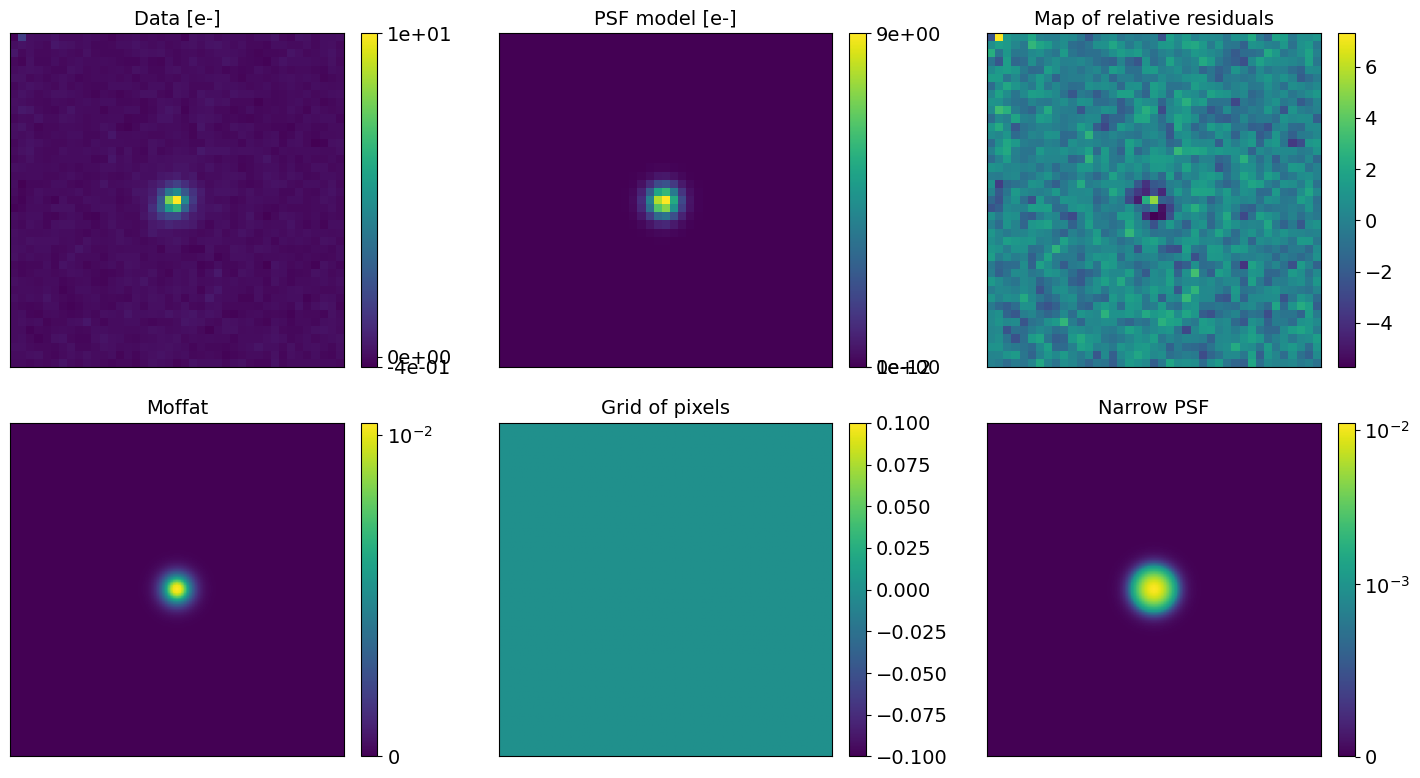

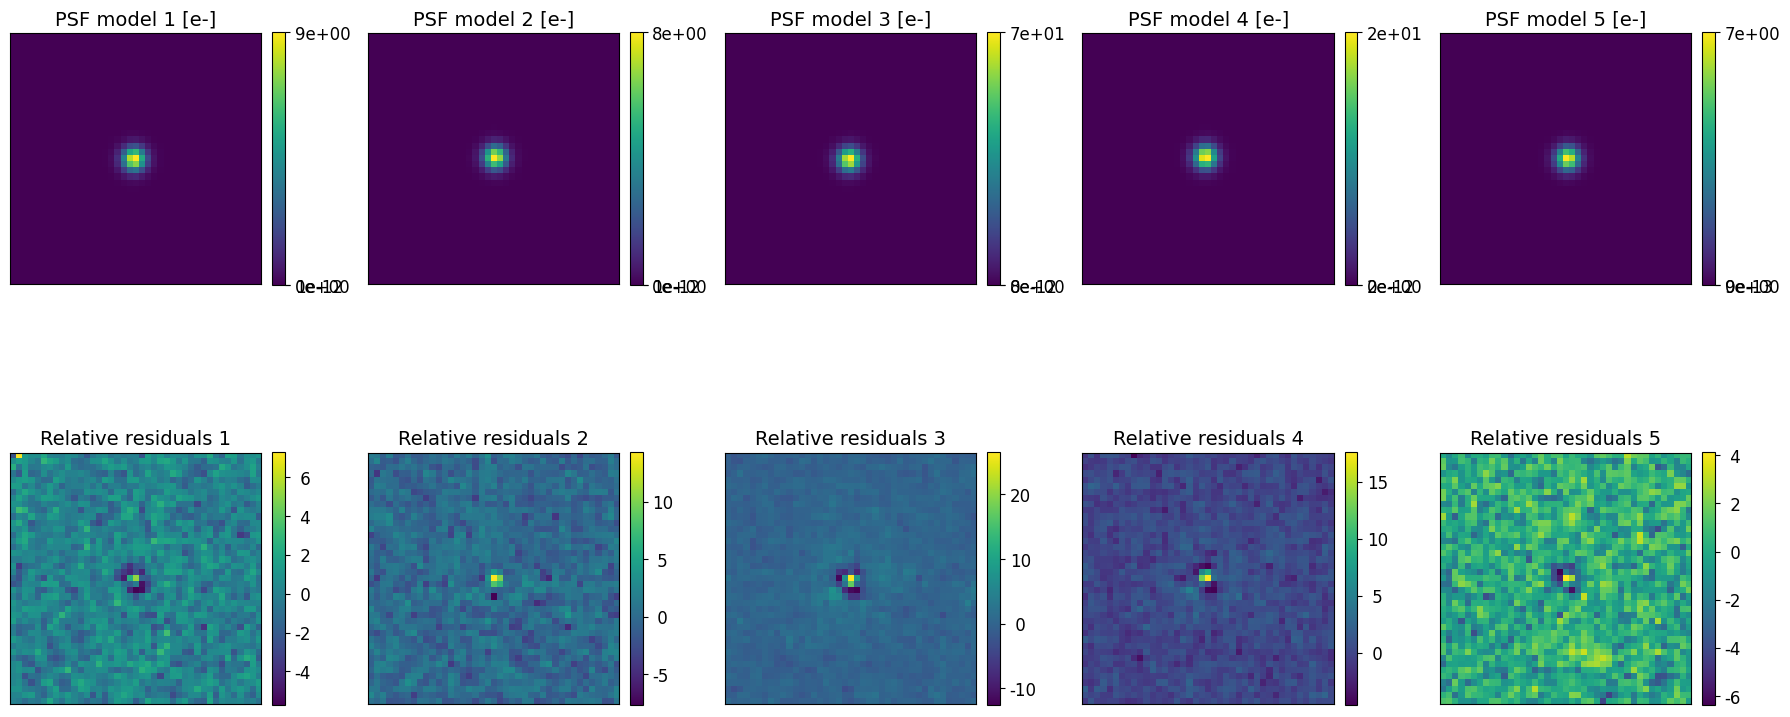

In [21]:
# Build the PSF model class
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F475X, fixed_background=True,guess_fwhm_pixels=3)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F475X, model, parameters, sigma_2_norm_F475X, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':1000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial,masks=None, units='e-')

Mean noise level in each starlet scale: 
Scale 0 : 3.6855951639653424
Scale 1 : 2.8786233645121677
Scale 2 : 1.6542074576173946
Scale 3 : 0.847129679603964
Scale 4 : 0.4138733001101399
Scale 5 : 0.19416847787222052
Scale 6 : 0.11663267499935341


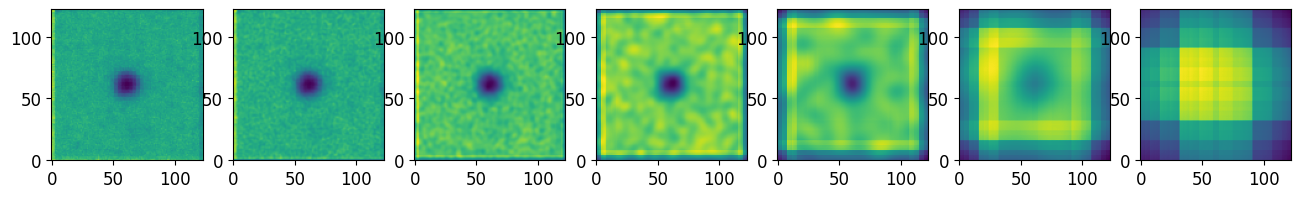

In [22]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F475X), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [23]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F475X, model, parameters, sigma_2_norm_F475X, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 3000, 'min_iterations': None,
                'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

optax.adabelief: 100%|██████████| 3000/3000 [00:22<00:00, 136.07it/s]


{'kwargs_moffat': {'fwhm': Array([1.57311671], dtype=float64), 'beta': Array([4.3135502], dtype=float64), 'C': Array([18.04400119], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 30.69678213,  37.8101155 , 262.69398745,  97.9563535 ,
        22.73775551], dtype=float64), 'x0': Array([-0.26450578,  0.30541169, -0.1555951 , -0.34210241,  0.4499831 ],      dtype=float64), 'y0': Array([-0.14430823,  0.03390357, -0.23262783,  0.18772806, -0.09840539],      dtype=float64)}, 'kwargs_background': {'background': Array([ 0.0004817 ,  0.0013591 , -0.00053538, ..., -0.00697965,
       -0.00351724, -0.00596965], dtype=float64)}}


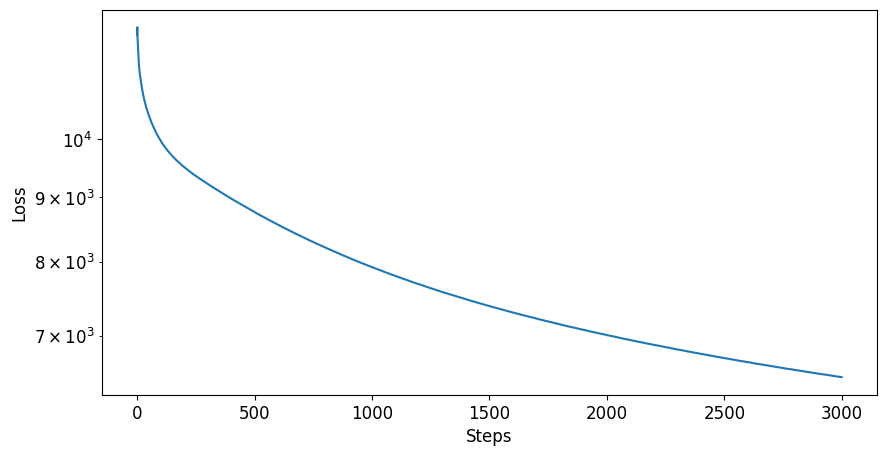

In [24]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

Overall Reduced Chi2 : 1.13074584335157


/tmp/ipykernel_21647/2190673543.py:6: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


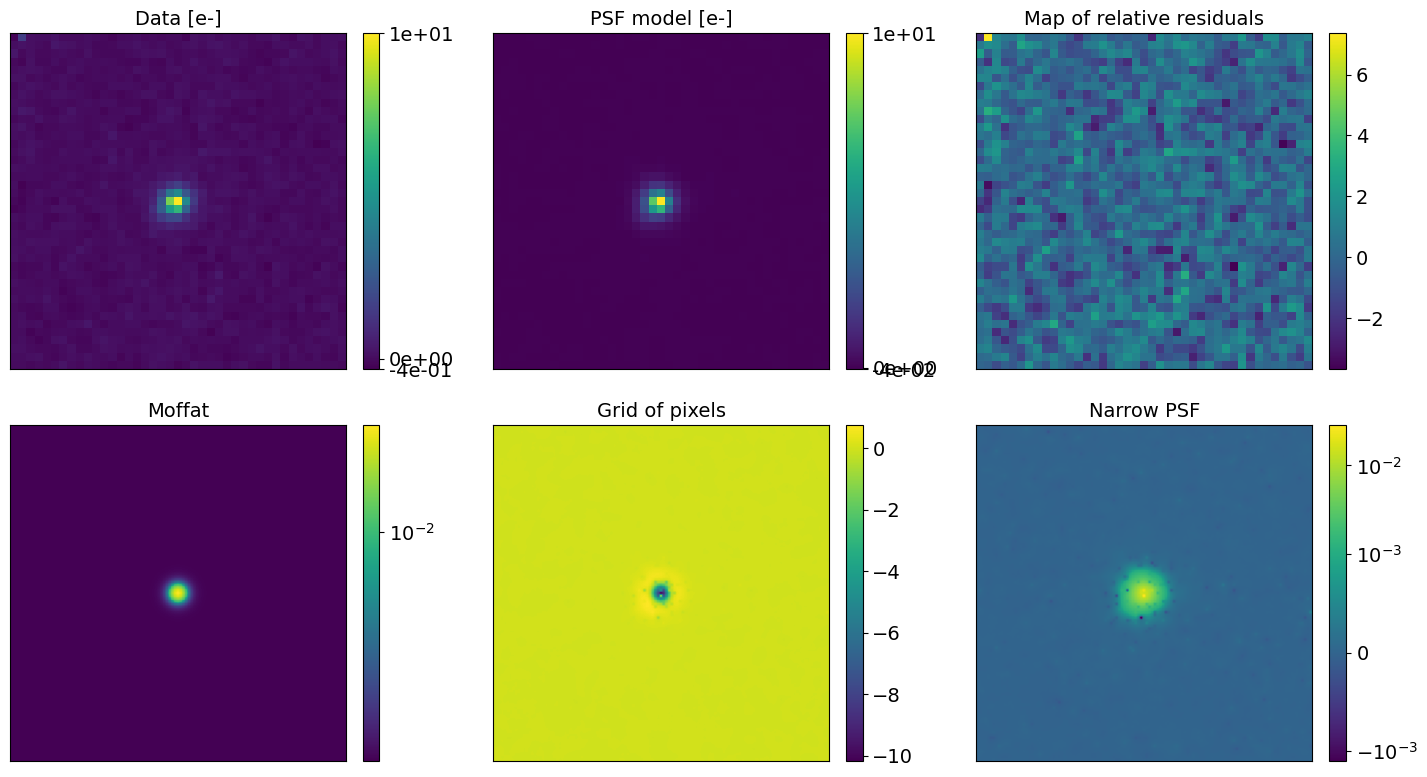

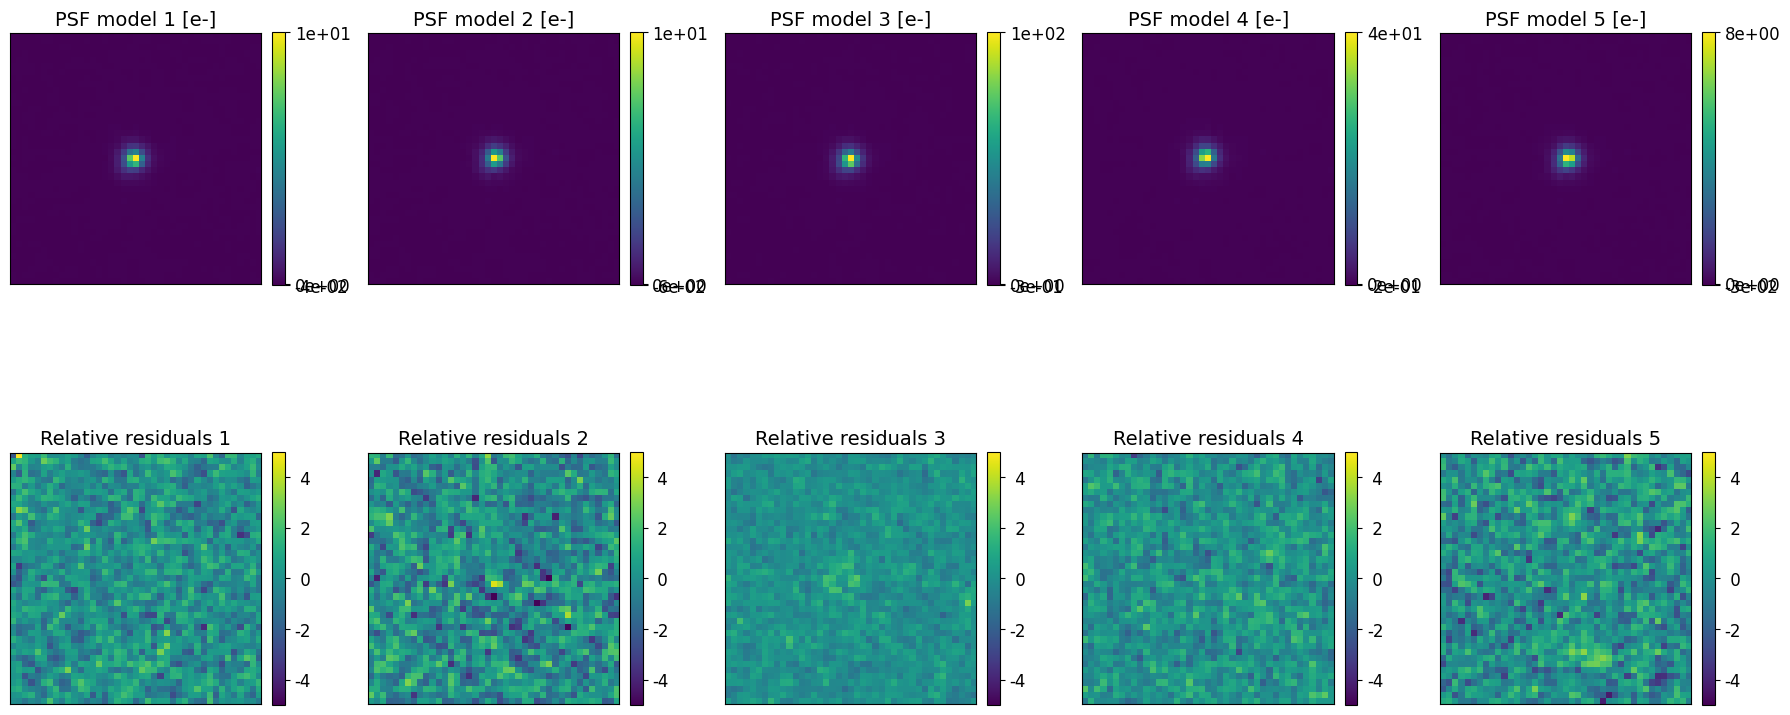

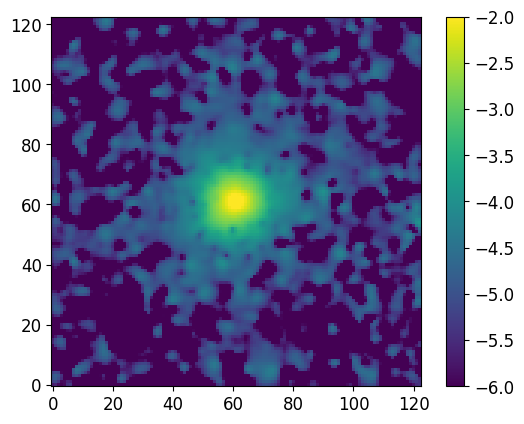

In [25]:
fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
full_psf = model.get_full_psf(**kwargs_final)
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

/tmp/ipykernel_21647/3997423734.py:5: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)


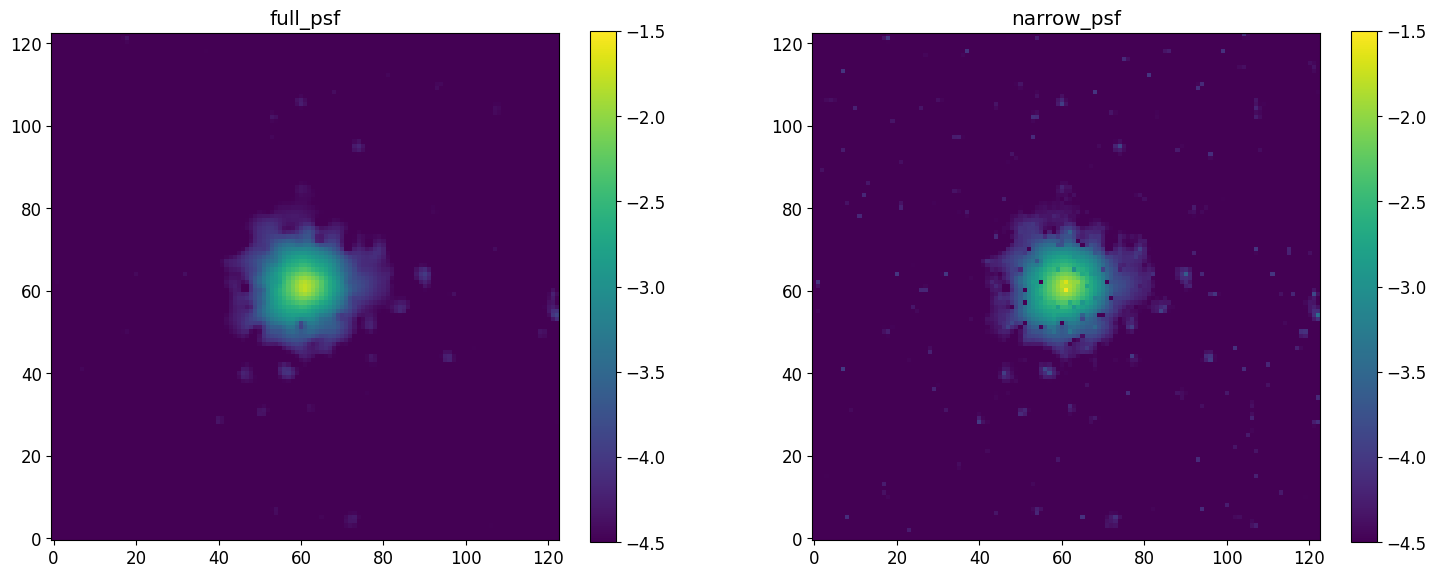

In [26]:
PSF_F475X = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F475X.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Method 2.

### Step 1, fixing : ['background'] ###


/home/f_avila/miniconda3/envs/starred-env/lib/python3.12/site-packages/starred/optim/optimization.py:78: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


Success of the step 1 fit in 30 iterations (4.054110288619995 s)
Step 1/2 took  4 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([1.96139779], dtype=float64), 'beta': Array([2.24085722], dtype=float64), 'C': Array([18.04400114], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 14.42637329,  17.64116073, 125.0883518 ,  46.41072442,
        10.71771221], dtype=float64), 'x0': Array([-0.31739283,  0.23877382, -0.21650644, -0.40477943,  0.38097882],      dtype=float64), 'y0': Array([-0.16333273,  0.02798169, -0.24355642,  0.16997266, -0.11239609],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
LogL :  5975.618517728347
Overall Reduced Chi2 :  1.4219199328324443
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 1000/1000 [00:07<00:00, 128.41it/s]


Step 2/2 took  8 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([1.96139779], dtype=float64), 'beta': Array([2.24085722], dtype=float64), 'C': Array([18.04400114], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 14.58018424,  17.89258554, 127.59237907,  47.12380932,
        10.80089105], dtype=float64), 'x0': Array([-0.31335826,  0.24132337, -0.20719429, -0.39424784,  0.3921676 ],      dtype=float64), 'y0': Array([-0.16918456,  0.01097955, -0.25545649,  0.16428624, -0.12217016],      dtype=float64)}, 'kwargs_background': {'background': Array([-4.82197631e-04, -4.34303196e-05,  2.66783869e-03, ...,
       -4.47134694e-03, -1.31625895e-02, -1.38189302e-03], dtype=float64)}}
LogL :  5664.0996805980785
Overall Reduced Chi2 :  1.2155219583493235
Moffat fit :


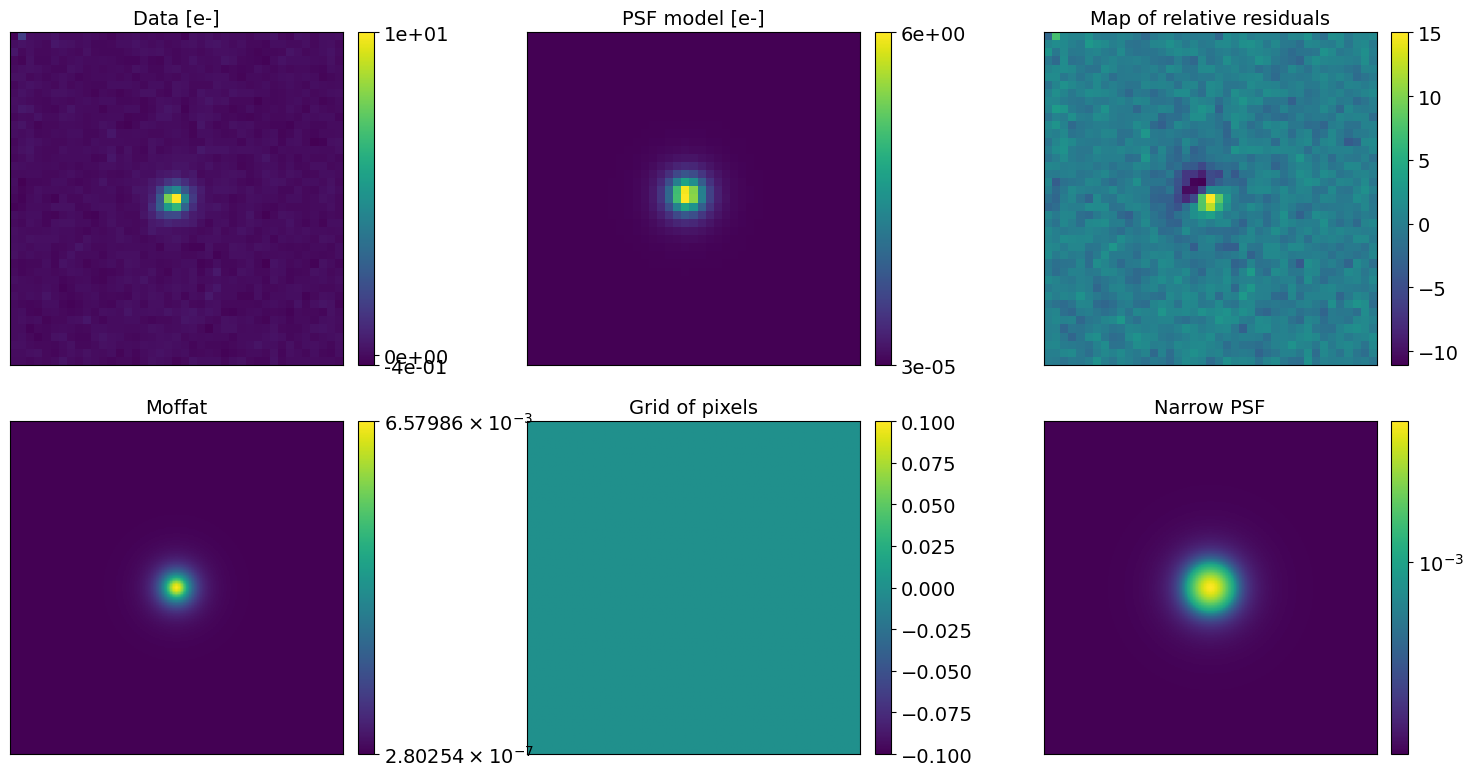

Moffat+ Background fit :


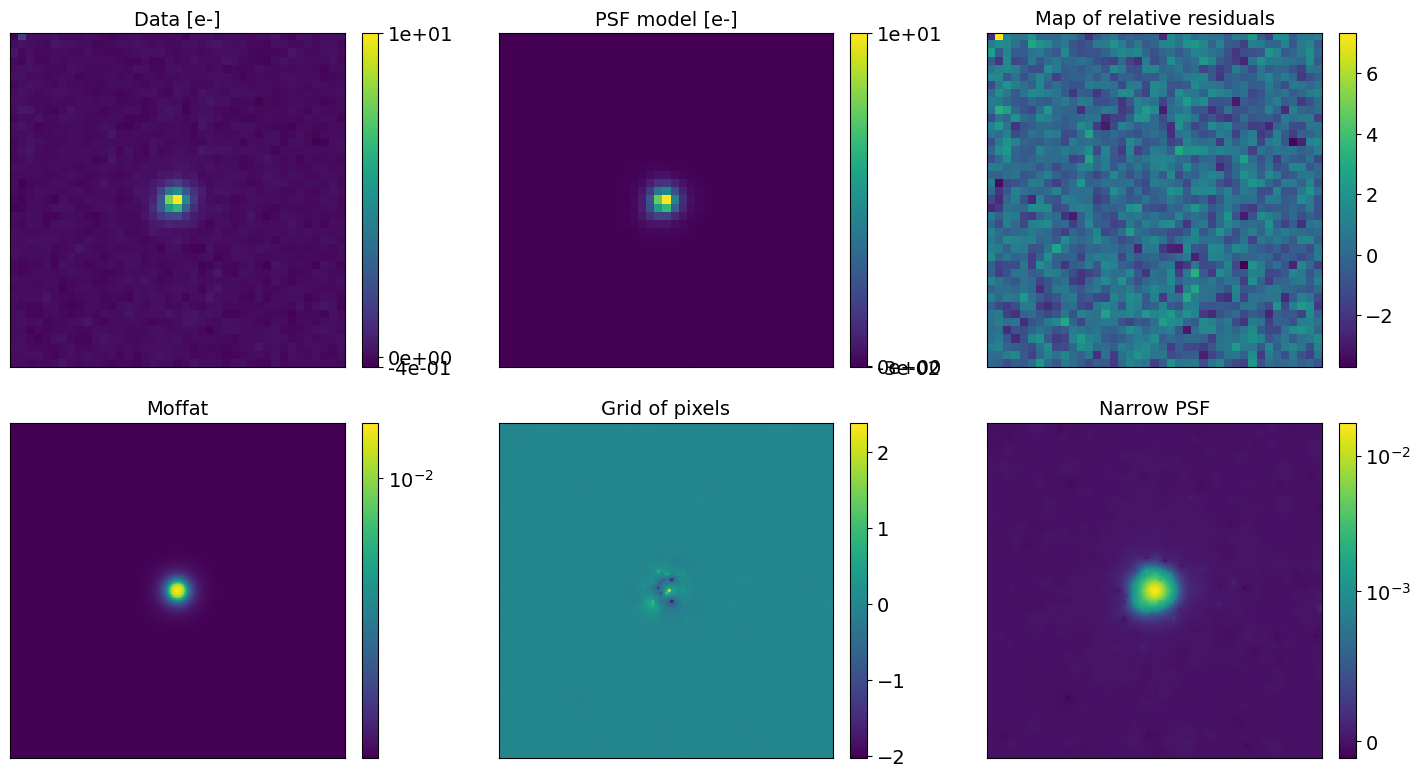

Multiple stars PSF model :


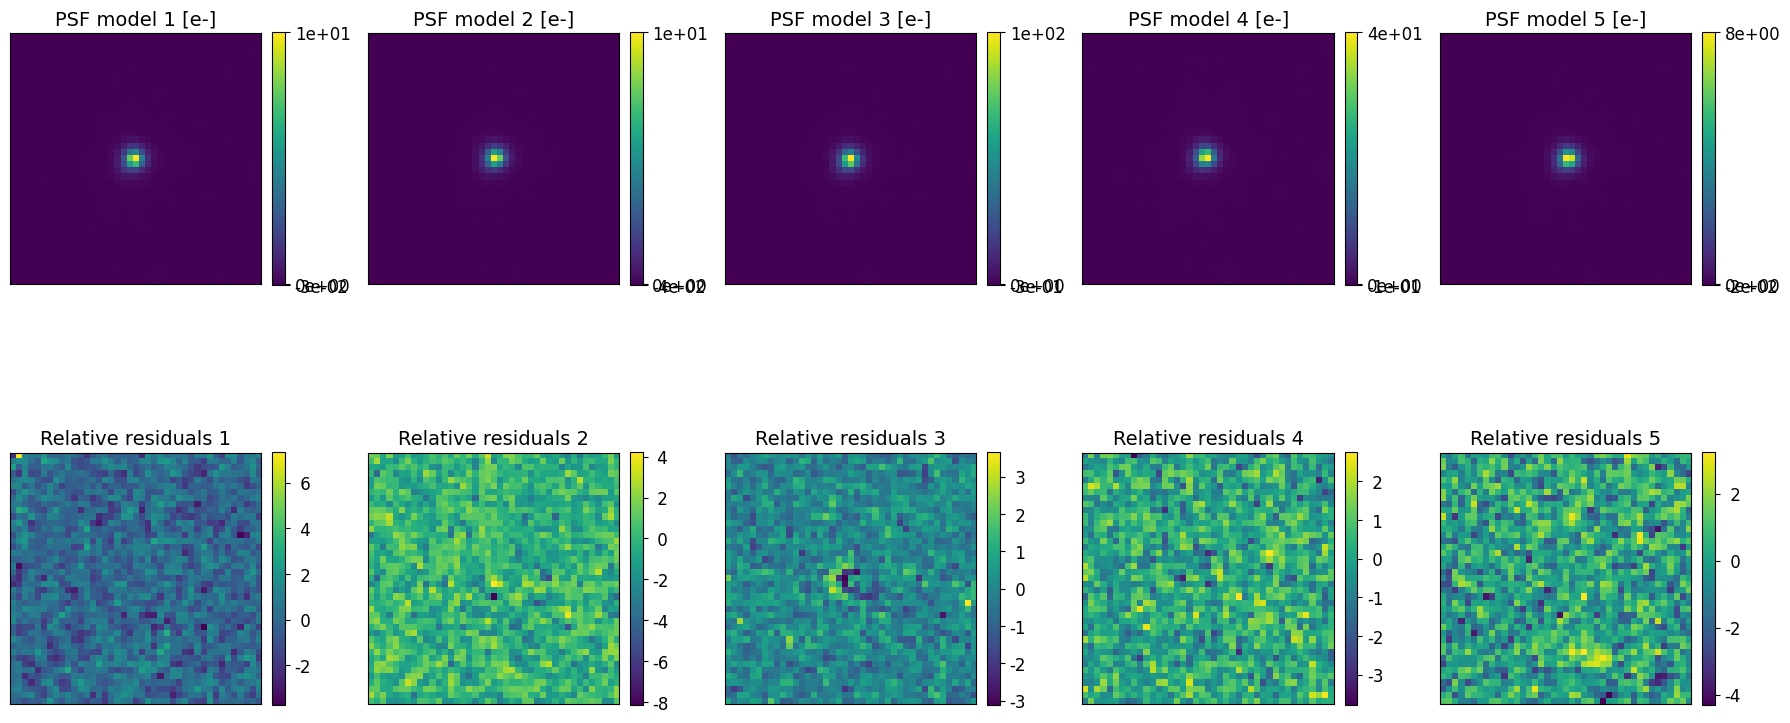

Loss history :


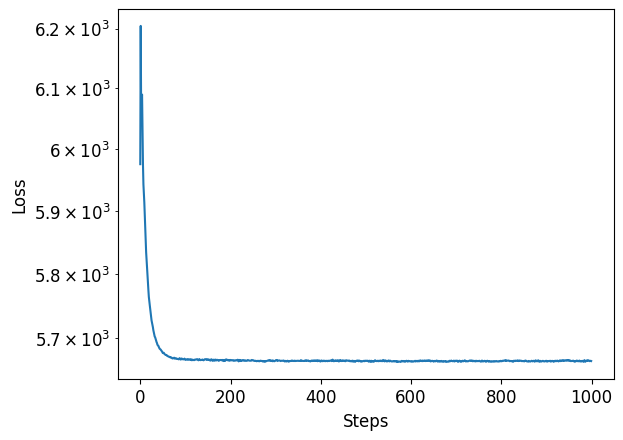

/tmp/ipykernel_21647/700717137.py:56: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


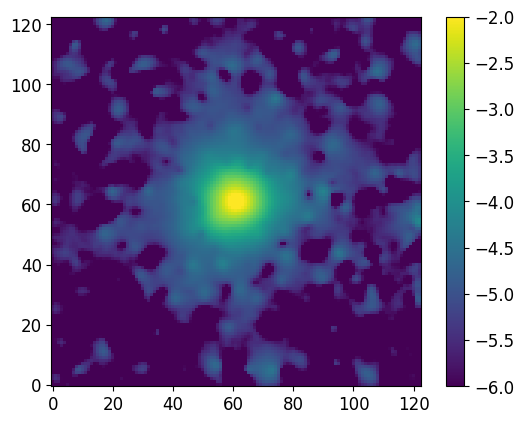

In [27]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F475X, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 1000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F475X, model,
        parameters, sigma_2_norm_F475X, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F475X, sigma_2_norm_F475X, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

/tmp/ipykernel_21647/3997423734.py:5: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)


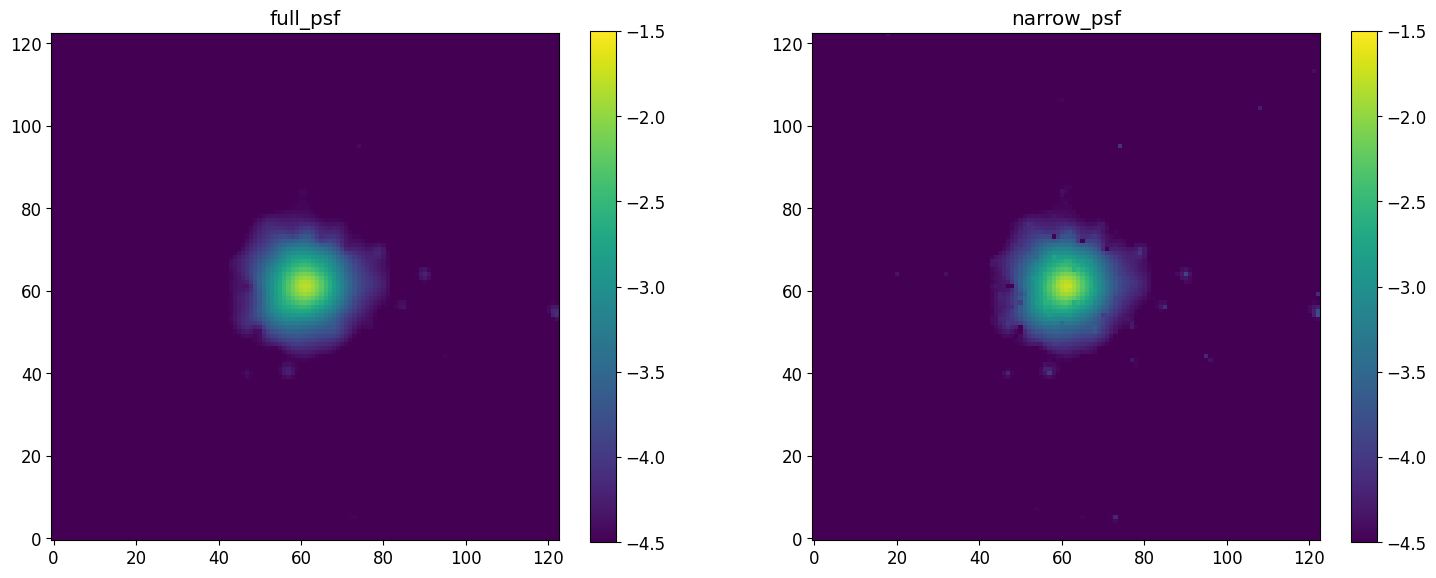

In [32]:
PSF_F475X = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F475X.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different componenet of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [33]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F475W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
#save_dict_as_h5py(result_psf_F475W,os.path.join(os.path.dirname(path_file_F475X),"result_psf_F475X"))

Overall Reduced Chi2 :  1.2155219583493235


In [34]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F475X
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F475X / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F475X"].values())[:3]) for i in np.asarray(photometry)]

Astrometry : [[-0.31335826 -0.16918456]
 [ 0.24132337  0.01097955]
 [-0.20719429 -0.25545649]
 [-0.39424784  0.16428624]
 [ 0.3921676  -0.12217016]]
Photometry : [ 8.49399348 10.41954604 74.33195607 27.45433401  6.28864874]
Photometry high resolution : [ 8.49399348 10.41954604 74.33195607 27.45433401  6.28864874]


[23.81656933434607,
 23.594727147737075,
 21.461410238702015,
 22.542821859955197,
 24.14295579959986]

In [31]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_file_F475X), 'model_starred_save_F475X.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F475X, data=data_norm_F475X, sigma_2=sigma_2_norm_F475X, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [ ]:

# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()

# F814W

In [35]:
Data_F814W,path_file_F814W=data_for_starred('WG0214-2105_F814W_drc_sci.fits',remove_star=[],shift=[0,0],star_num_pix=41,make_plots=False,save=False) 
#The chi2 in this case is under 1, the reason why is not clear for me I.

Statistical properties data raw 
 mean=0.0004984634870339746
 median=0.0003327425802126527
 std=0.006196925322449398
Using reference exposure time of 1428.0 s
Stats wht (mean, std, max): 1377.0957430405656 187.5217614223777 1551.047119140625
Re-normalized the WHT map.
Median afterwards: 1327.3480894097343


02h14m16.67s -21d04m59.01s
02h14m14.57s -21d04m37.88s
02h14m13.47s -21d05m19.65s
02h14m15.87s -21d04m55.03s
02h14m16.51s -21d04m23.73s
Mean sigma2_sky = 3.2095875569656366e-05
Mean sigma2_target = 1.3374431778446618e-05
Mean sigma2_sky = 3.663088823109713e-05
Mean sigma2_target = 1.064489332839553e-05
Mean sigma2_sky = 7.31627915964393e-05
Mean sigma2_target = 0.00015993773554634784
Mean sigma2_sky = 3.404503232978149e-05
Mean sigma2_target = 1.367167323986132e-05
Mean sigma2_sky = 2.3418388567420866e-05
Mean sigma2_target = 6.937990851961283e-06


(5, 41, 41)


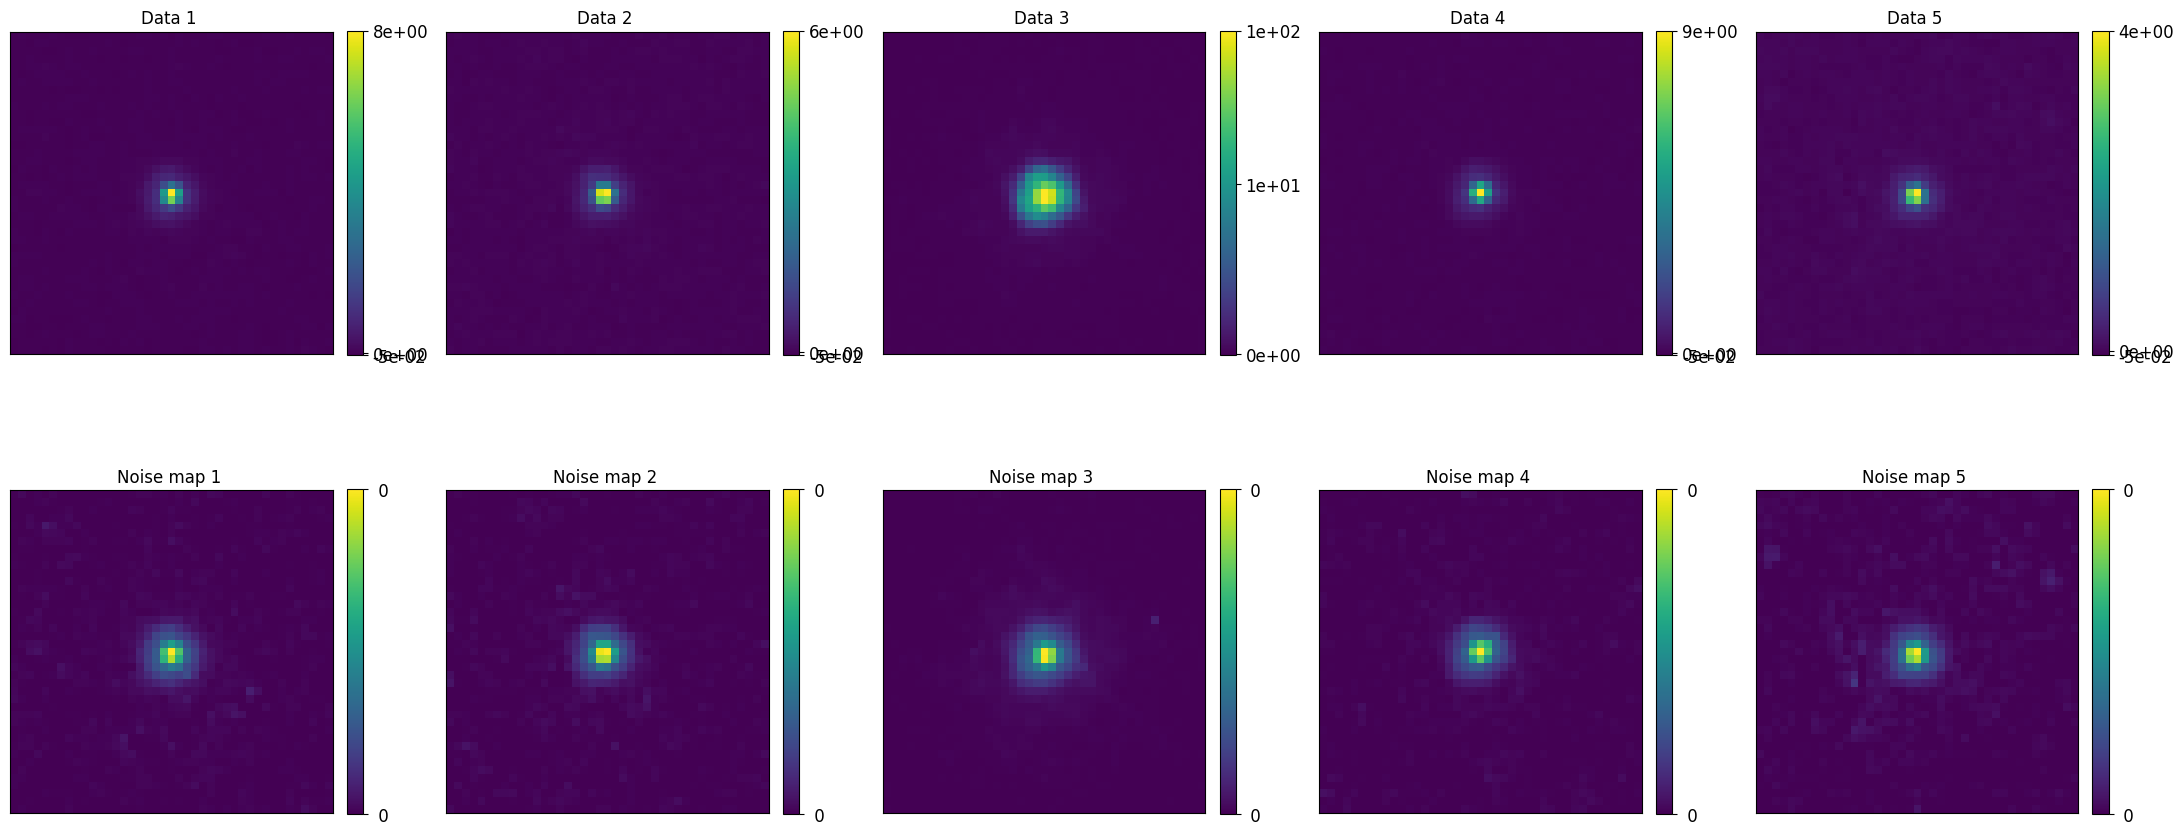

In [36]:
#remove_star 3 (gives chi2~70 otherwise)
# Parameters
subsampling_factor = 3 #this can be increased fo a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 100
n_iter = 1500 
#TENGO QUE INCREMENTAR EL NUMERO DE ITERACIONES
#TENGO QUE MODIFICAR LOS LAMBDA EN CASO DE NECESIDAD 
lambda_scales = 3.0
lambda_hf = 3.0 #increse this 
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F814W = Data_F814W["data_cutout_norm"]
norm_F814W=Data_F814W["norm"]
sigma_2_norm_F814W = Data_F814W['sigma2_norm']
# number of stars
N = len(data_norm_F814W)
# data dimensions
image_size = np.shape(data_norm_F814W)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F814W))
fig = pltf.display_data(data_norm_F814W, sigma_2 = sigma_2_norm_F814W)

### Method 1.

Initial Guess : {'kwargs_moffat': {'fwhm': 3, 'beta': 2.0, 'C': 15.408775965474833}, 'kwargs_gaussian': {'a': Array([ 4.61973666,  3.63047099, 61.88101434,  4.73078734,  2.18187048],      dtype=float64), 'x0': array([0., 0., 0., 0., 0.]), 'y0': array([0., 0., 0., 0., 0.])}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
Moffat fit : {'kwargs_moffat': {'fwhm': Array([2.], dtype=float64), 'beta': Array([1.90847126], dtype=float64), 'C': Array([15.40877597], dtype=float64)}, 'kwargs_gaussian': {'a': Array([  9.20074325,   7.52816594, 125.62115296,   9.63974163,
         4.25347845], dtype=float64), 'x0': Array([-0.00168997, -0.46311609,  0.1339379 , -0.05300485, -0.30291092],      dtype=float64), 'y0': Array([-0.33206737, -0.25308276, -0.44715046,  0.00625817, -0.36078616],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}


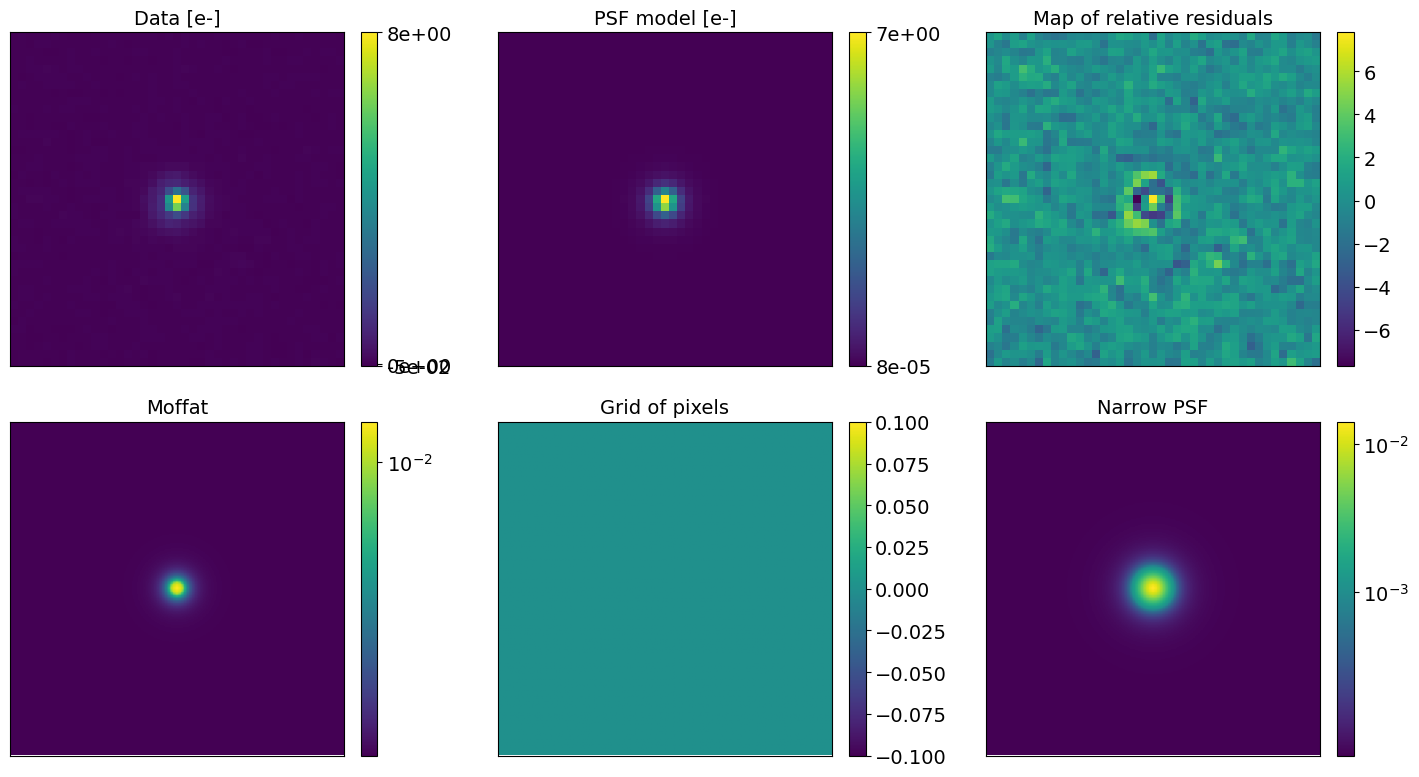

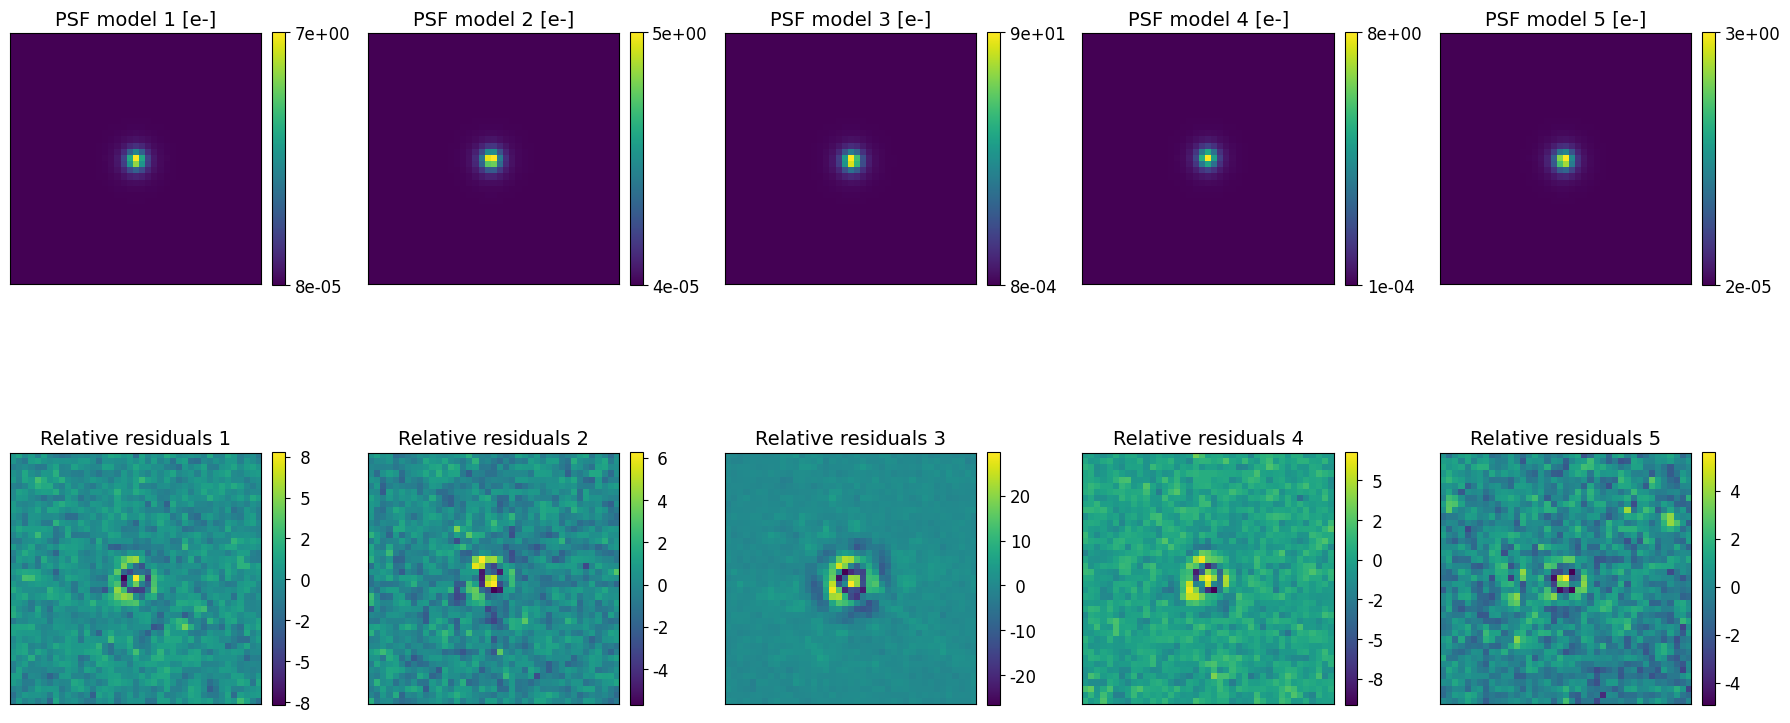

In [37]:
# Build the PSF model class
convolution_method = 'fft'
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F814W, fixed_background=True,guess_fwhm_pixels=3)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F814W, model, parameters, sigma_2_norm_F814W, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':1000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial,masks=None, units='e-')

/home/f_avila/miniconda3/envs/starred-env/lib/python3.12/site-packages/starred/utils/noise_utils.py:52: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)


Mean noise level in each starlet scale: 
Scale 0 : 19.030099217779014
Scale 1 : 14.86896340221834
Scale 2 : 8.54854295670648
Scale 3 : 4.384808781962799
Scale 4 : 2.146283642209433
Scale 5 : 1.0079717317210957
Scale 6 : 0.6004542031567013


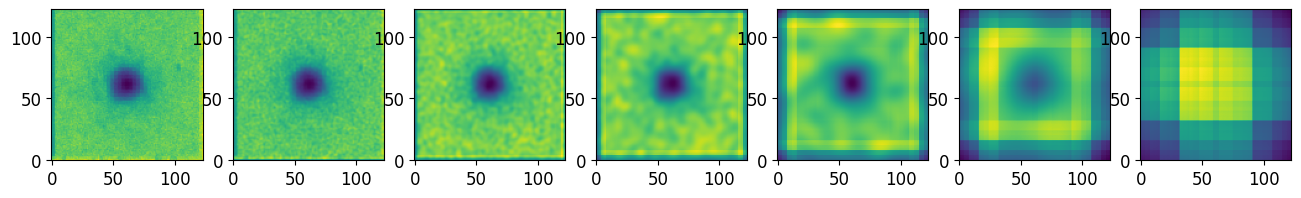

In [38]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F814W), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [39]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F814W, model, parameters, sigma_2_norm_F814W, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 3000, 'min_iterations': None,
                'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

optax.adabelief: 100%|██████████| 3000/3000 [00:22<00:00, 135.33it/s]


{'kwargs_moffat': {'fwhm': Array([1.22190375], dtype=float64), 'beta': Array([1.61939279], dtype=float64), 'C': Array([15.40877597], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 21.92308334,  18.00858505, 302.06209177,  23.18599409,
        10.14768268], dtype=float64), 'x0': Array([ 0.08856289, -0.36285159,  0.23517129,  0.04176101, -0.2103933 ],      dtype=float64), 'y0': Array([-0.32642834, -0.25885332, -0.45466369, -0.00313243, -0.3578315 ],      dtype=float64)}, 'kwargs_background': {'background': Array([-0.00032641,  0.00182217,  0.00122371, ...,  0.00048659,
        0.00240216,  0.00058451], dtype=float64)}}


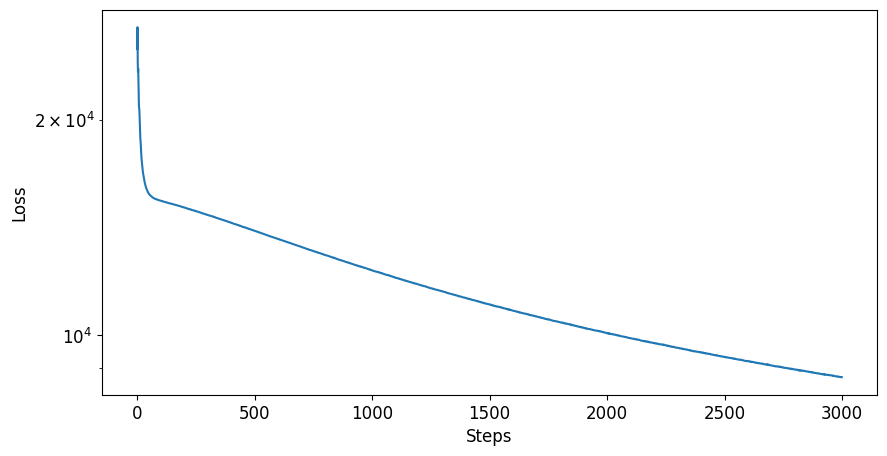

In [40]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

Overall Reduced Chi2 : 0.7791715673774317


/tmp/ipykernel_21647/437323962.py:6: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


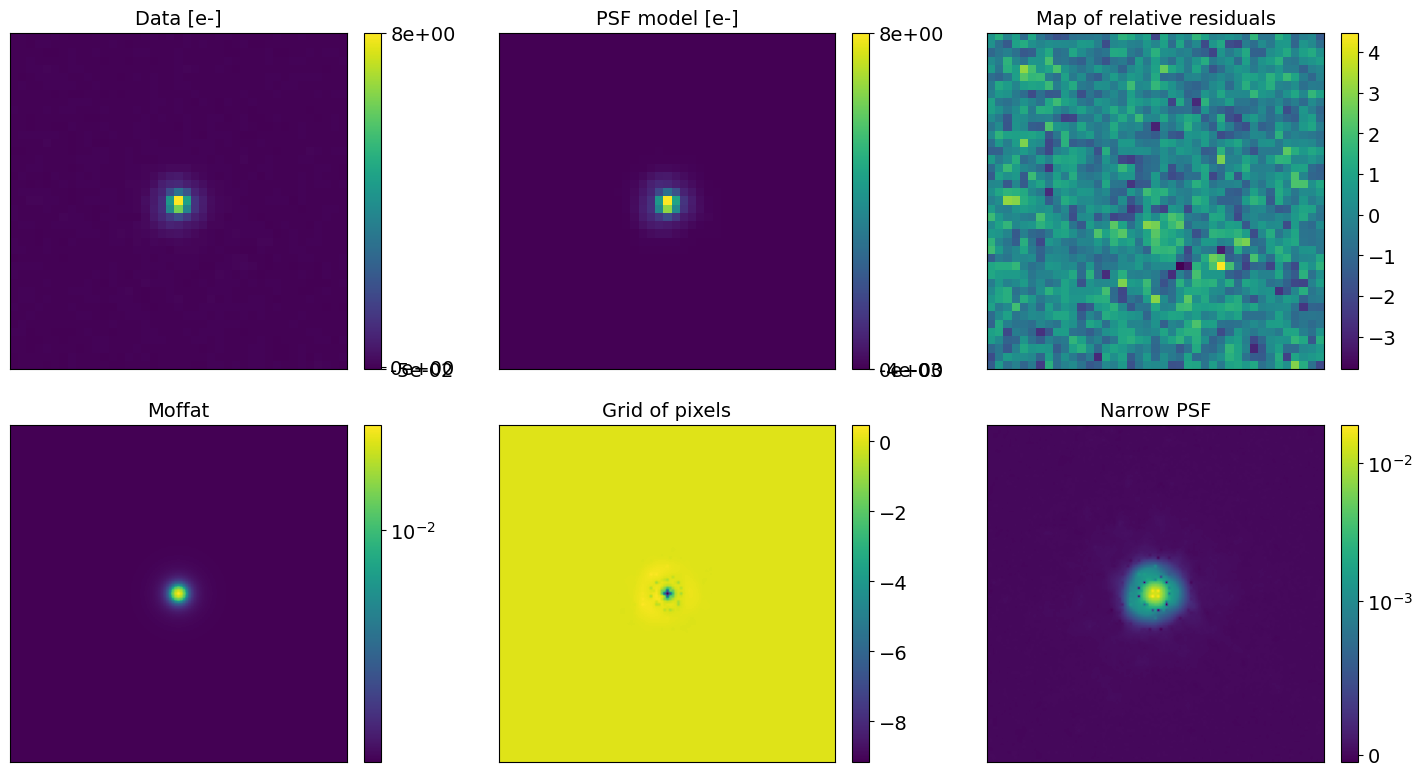

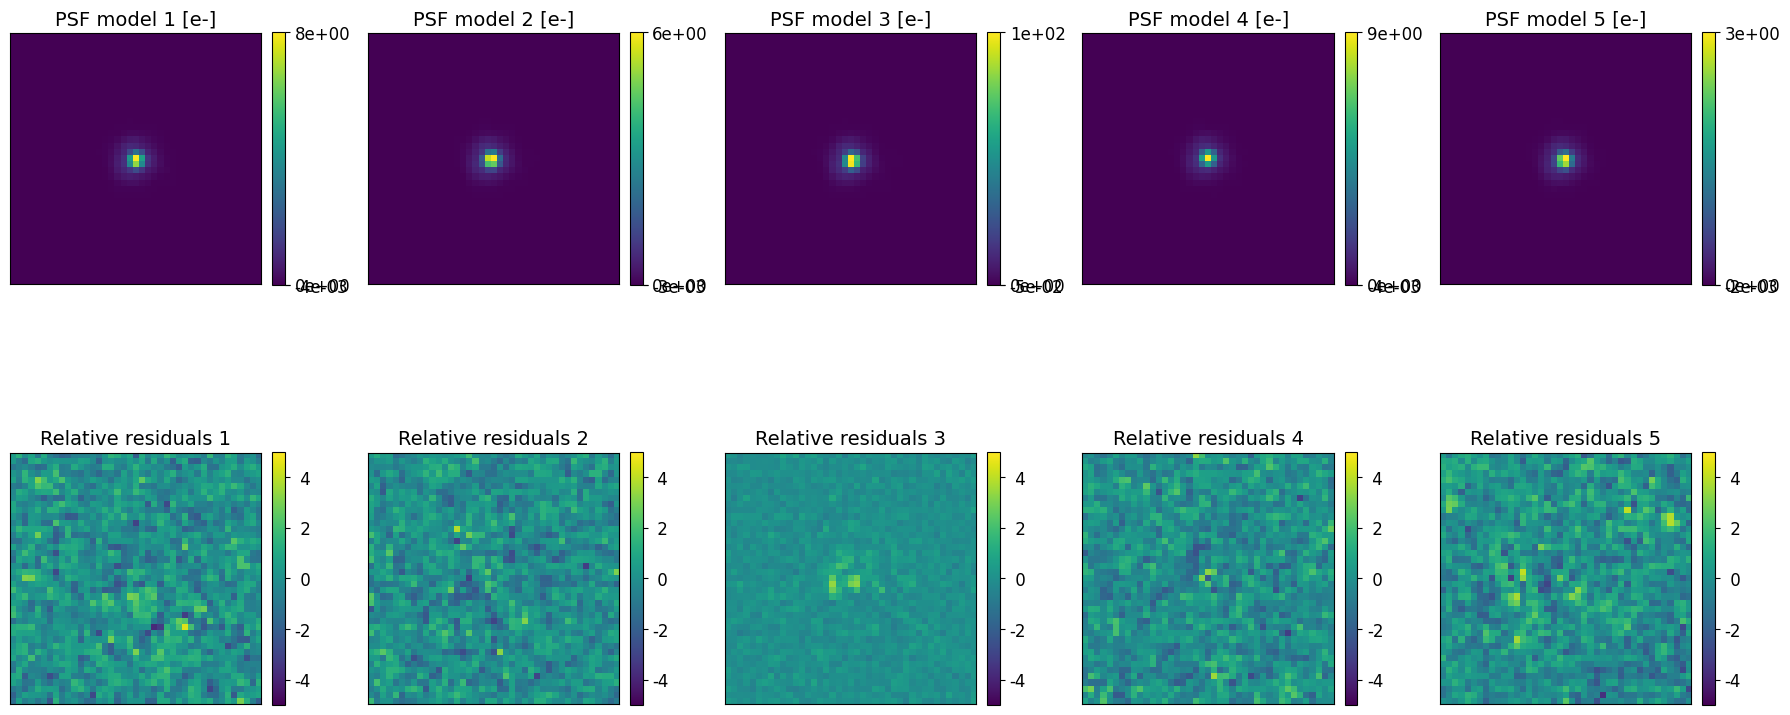

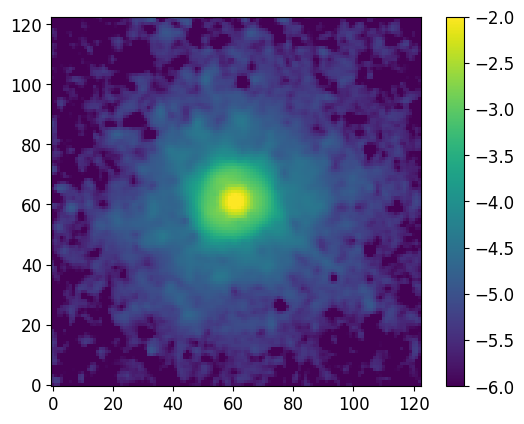

In [41]:
fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
full_psf = model.get_full_psf(**kwargs_final)
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

Overall Reduced Chi2 : 0.7791715673774317


/tmp/ipykernel_21647/3077523009.py:6: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)


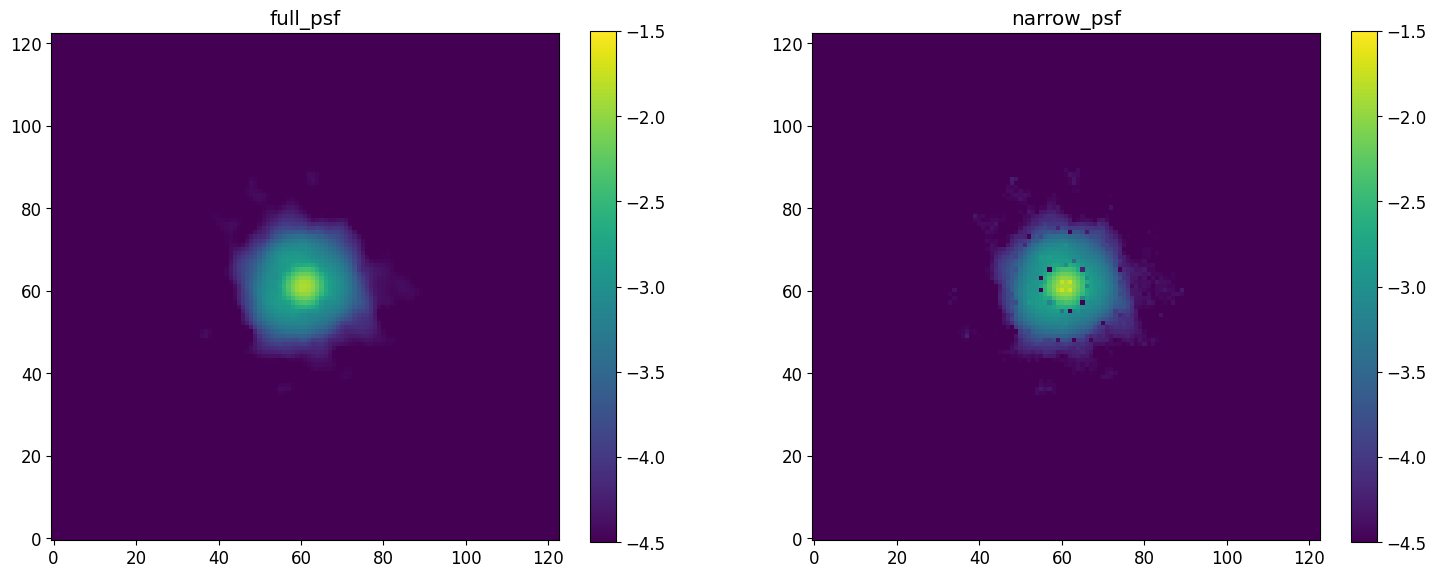

In [42]:
PSF_F814W = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
for ax, (key, psf) in zip(axes, PSF_F814W .items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Method 2.

### Step 1, fixing : ['background'] ###


/home/f_avila/miniconda3/envs/starred-env/lib/python3.12/site-packages/starred/optim/optimization.py:78: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


Success of the step 1 fit in 38 iterations (7.072632789611816 s)
Step 1/2 took  7 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([1.74057765], dtype=float64), 'beta': Array([1.71807286], dtype=float64), 'C': Array([15.40877597], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 11.16515108,   9.14240424, 152.46056419,  11.71122637,
         5.17421812], dtype=float64), 'x0': Array([ 5.98463268e-05, -4.60656070e-01,  1.42289490e-01, -5.13843725e-02,
       -3.06055011e-01], dtype=float64), 'y0': Array([-0.33034624, -0.26137734, -0.4527879 ,  0.00313858, -0.36006114],      dtype=float64)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)}}
LogL :  12933.30609909513
Overall Reduced Chi2 :  3.077526733871536
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 1000/1000 [00:07<00:00, 136.84it/s]


Step 2/2 took  7 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([1.74057765], dtype=float64), 'beta': Array([1.71807286], dtype=float64), 'C': Array([15.40877597], dtype=float64)}, 'kwargs_gaussian': {'a': Array([ 11.33637979,   9.30299394, 157.9717755 ,  11.97213265,
         5.24439447], dtype=float64), 'x0': Array([-0.01612424, -0.47222169,  0.13021281, -0.06553278, -0.32048538],      dtype=float64), 'y0': Array([-3.28532151e-01, -2.60848508e-01, -4.55343462e-01, -3.29865908e-04,
       -3.58816984e-01], dtype=float64)}, 'kwargs_background': {'background': Array([-0.00080068, -0.00124353, -0.00109198, ..., -0.00244153,
        0.0017512 , -0.00160527], dtype=float64)}}
LogL :  5546.0848606605505
Overall Reduced Chi2 :  0.8235243959751749
Moffat fit :


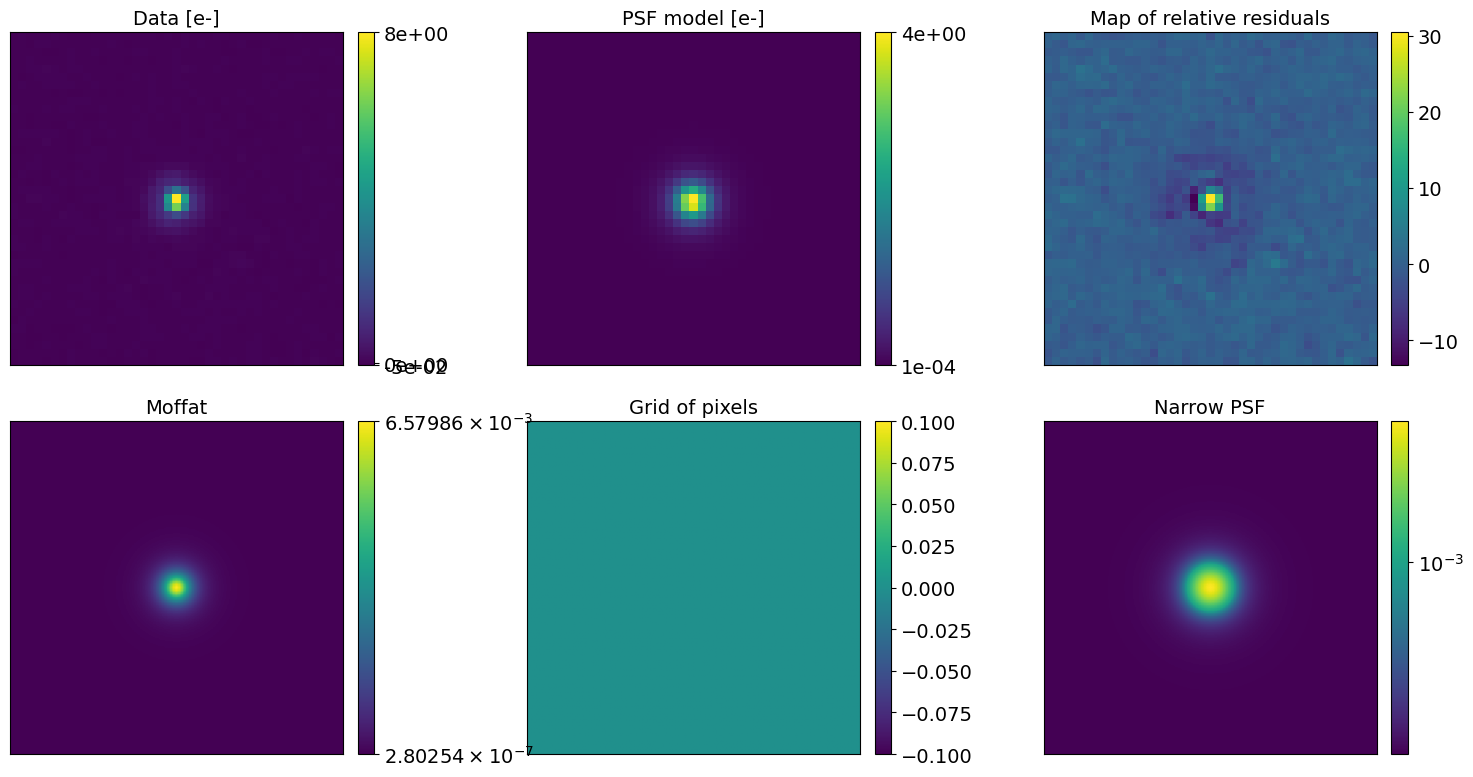

Moffat+ Background fit :


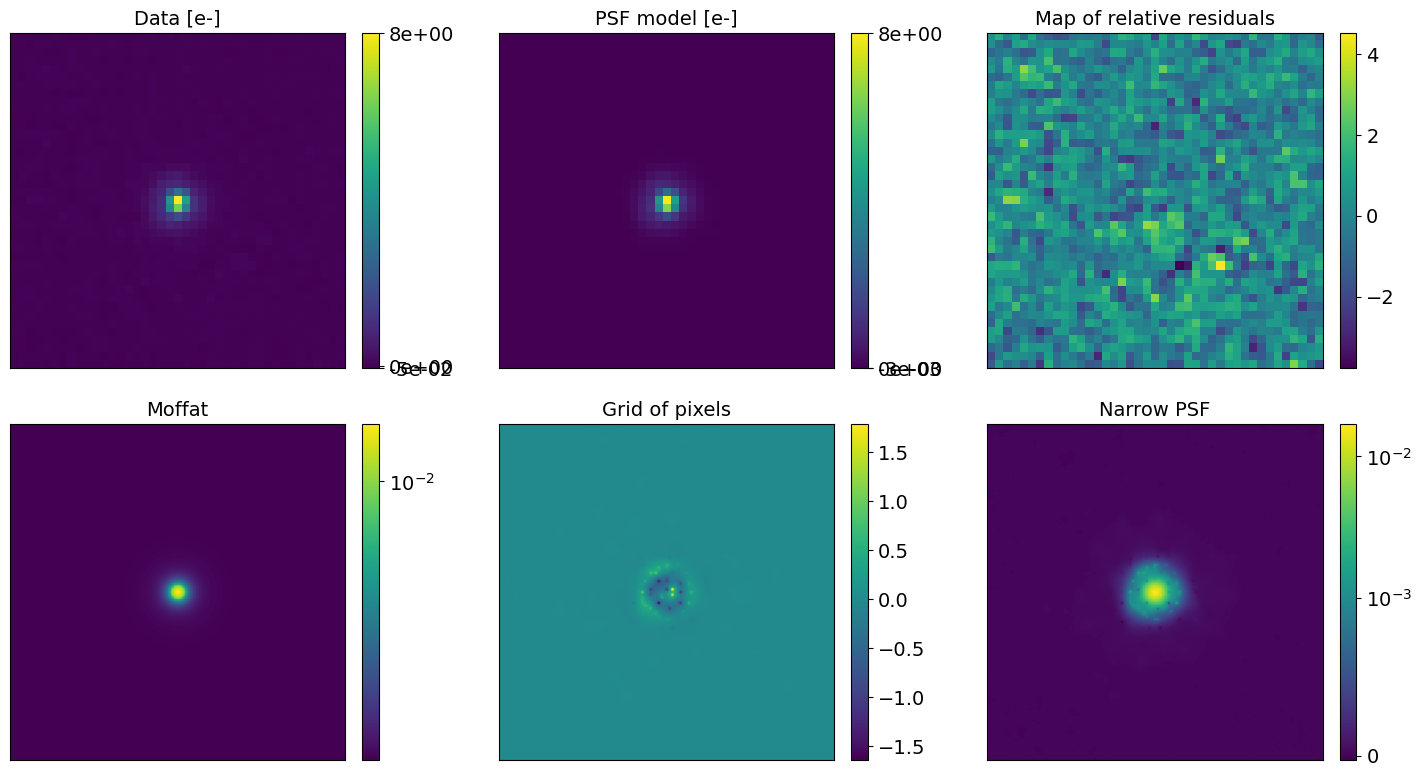

Multiple stars PSF model :


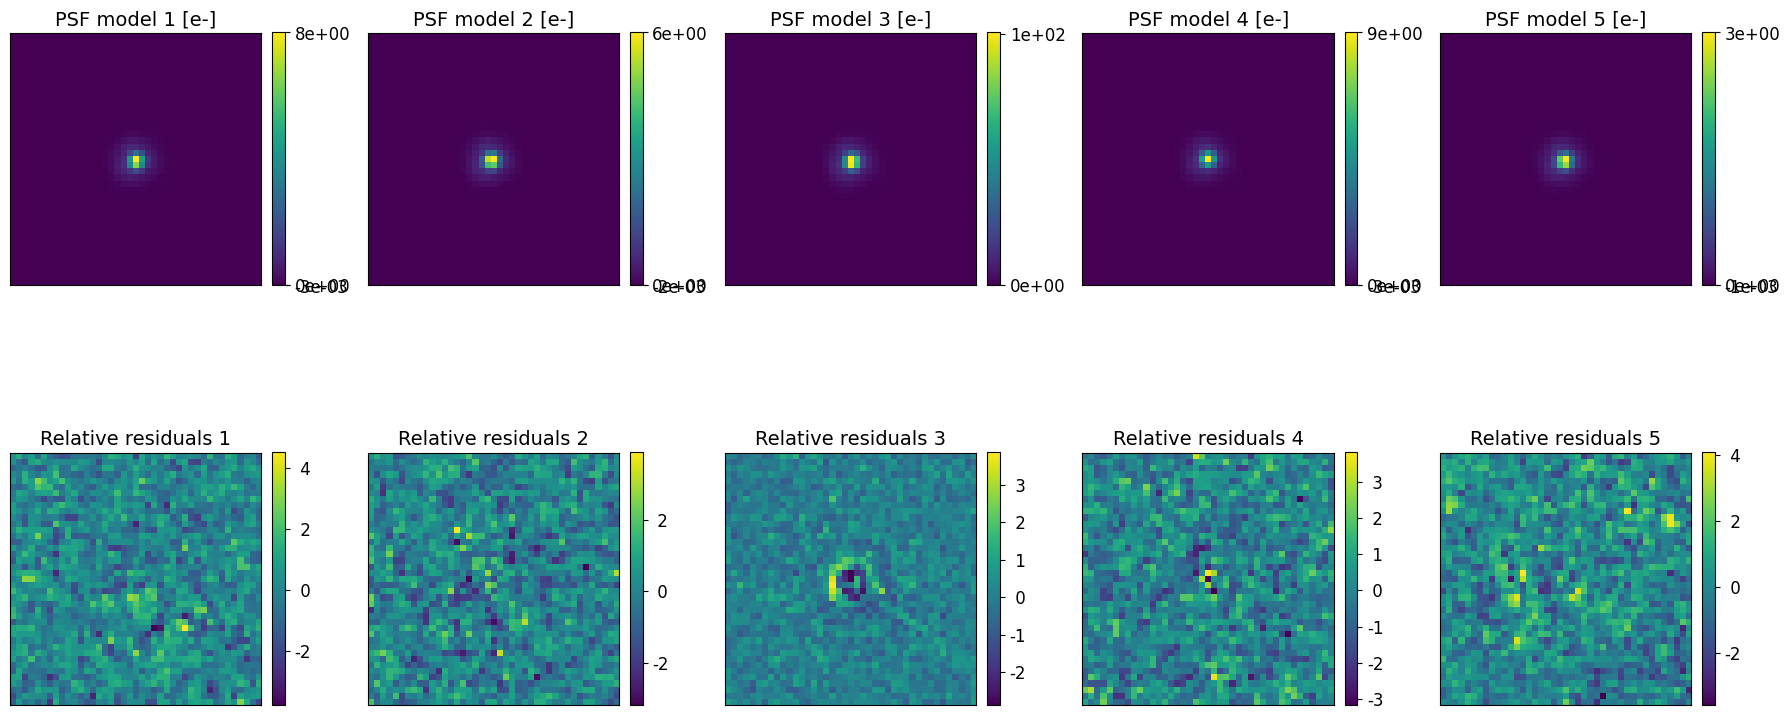

Loss history :


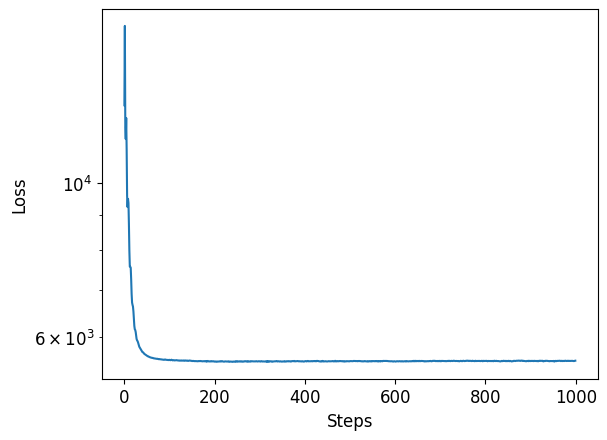

/tmp/ipykernel_21647/2732304249.py:56: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


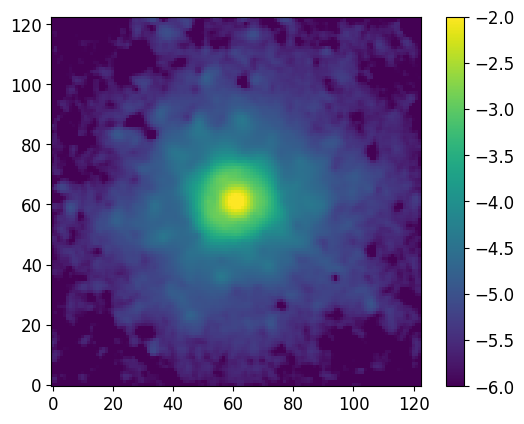

In [43]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F814W, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 1000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F814W, model,
        parameters, sigma_2_norm_F814W, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F814W, sigma_2_norm_F814W, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

Overall Reduced Chi2 : 0.8235243959751749


/tmp/ipykernel_21647/3077523009.py:6: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)


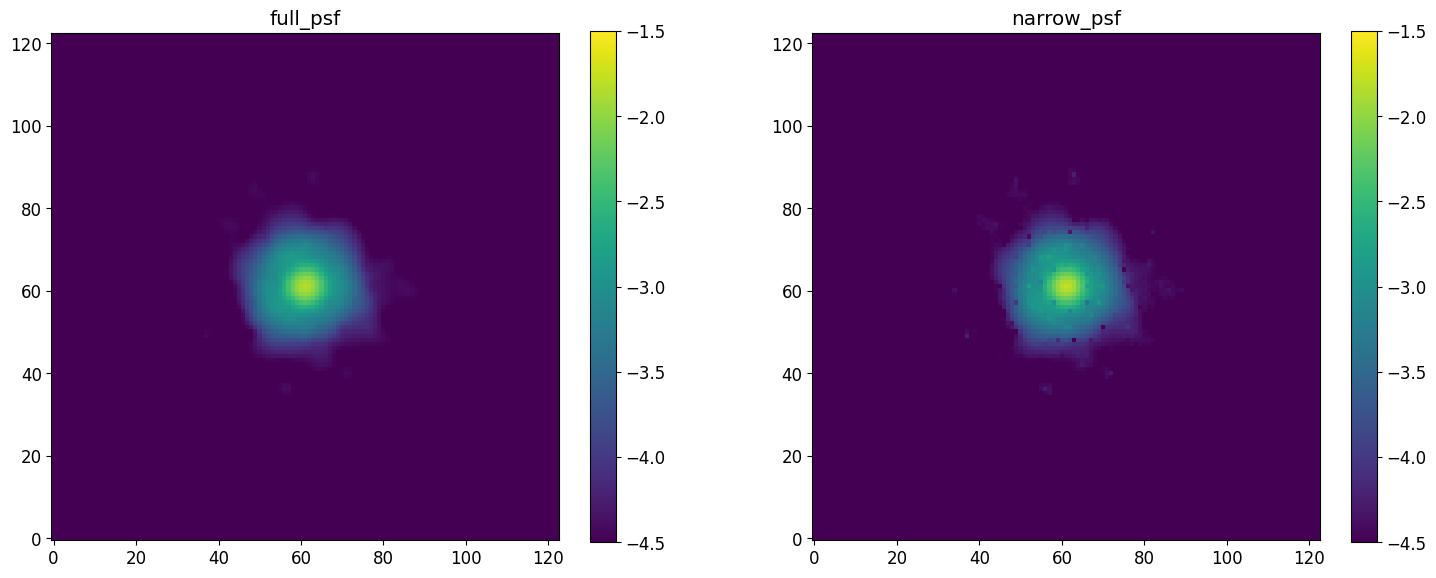

In [44]:
PSF_F814W = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
for ax, (key, psf) in zip(axes, PSF_F814W .items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different componenet of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [45]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F814W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
#save_dict_as_h5py(result_psf_F814W,os.path.join(os.path.dirname(path_file_F814W),"result_psf_F814W"))

Overall Reduced Chi2 :  0.8235243959751749


In [47]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F814W
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F814W / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F814W"].values())[:3]) for i in np.asarray(photometry)]

Astrometry : [[-1.61242385e-02 -3.28532151e-01]
 [-4.72221695e-01 -2.60848508e-01]
 [ 1.30212813e-01 -4.55343462e-01]
 [-6.55327760e-02 -3.29865908e-04]
 [-3.20485378e-01 -3.58816984e-01]]
Photometry : [ 25.50671537  20.92998366 355.41244591  26.9379935   11.79921653]
Photometry high resolution : [ 25.50671537  20.92998366 355.41244591  26.9379935   11.79921653]


[21.59860738531043,
 21.8133215020016,
 18.738412145362375,
 21.539330615852947,
 22.435610797637466]

In [294]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_filter_F814W), 'model_starred_save_F814W.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F814W, data=data_norm_F814W, sigma_2=sigma_2_norm_F814W, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [ ]:
# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()